This notebook holds the code to reproduce all figures of the paper after running the experiments from the experiments folder. In the section Init the data and the results are loaded and in Analyze the results are being analyzed and transformed for further use.

# Init

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from functions.embedding_quality import embedding_quality
from functions.plot_embedding import plot_embed, get_scale, add_scale, plot_embed_score
from functions.analyze_rs import analyze_rs, analyze_rs_om

import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.decomposition import PCA
import torchvision
import pandas as pd


## Load data and results

In [3]:
# Tasic
tasic_colors = np.load('../data/tasic/tasic-colors.npy')
tasic_pca50 = np.load('../data/tasic/tasic-pca50.npy')
tasic_ttypes = np.load('../data/tasic/tasic-ttypes.npy')

tasic_pca2 = tasic_pca50[:, :2]
tasic_pca2_scaled = tasic_pca2 / tasic_pca2[:,0].std() * 0.0001
tasic_pca2_scaled_eval = embedding_quality(tasic_pca2_scaled, tasic_pca50, tasic_ttypes)

In [4]:
# kanton
# data
data_file = "../data/Kanton/human-409b2.data.npy"
labels_file = "../data/Kanton/human-409b2.labels.npy"
pkl_file = "../data/Kanton/human-409b2.pkl"

kanton_pca50 = np.load(data_file)
kanton_labels = np.load(labels_file)

with open(pkl_file, "rb") as f:
    pkl_data = pickle.load(f)

kanton_colors = np.array([pkl_data["label_colors"][i] for i in kanton_labels])

# Print shapes and types
print("Data shape:", kanton_pca50.shape)
print("Labels shape:", kanton_labels.shape)
print("Colors shape:", kanton_colors.shape)
print("Pickle data type:", type(pkl_data))

kanton_pca2 = kanton_pca50[:, :2]
kanton_pca2_scaled = kanton_pca2 / kanton_pca2[:,0].std() * 0.0001
kanton_eval_pca2_scaled = embedding_quality(kanton_pca50, kanton_pca2_scaled, kanton_labels)

Data shape: (20272, 50)
Labels shape: (20272,)
Colors shape: (20272,)
Pickle data type: <class 'dict'>


In [5]:
# genome
# data
genome_data = np.loadtxt('../data/Genomes/gt_sum_thinned.npy')
genome_pca50 = PCA(n_components=50).fit_transform(genome_data)

population_labels = np.loadtxt('../data/Genomes/population_labels.txt', dtype=str)
population_names = pd.read_csv('../data/Genomes/1kgp_population_names.tsv', sep='\t', dtype=str)

# colors
genome_colors = np.load('../data/Genomes/genome_colors.npy')

genome_pca2 = genome_pca50[:, :2]
genome_pca2_scaled = genome_pca2 / genome_pca2[:,0].std() * 0.0001
genome_eval_pca2_scaled = embedding_quality(genome_pca50, genome_pca2_scaled, population_labels)


In [6]:
# mnist
# load MNIST
mnist_train = torchvision.datasets.MNIST(root='../data',
                                         train=True,
                                         download=False, 
                                         transform=None)
x_train, y_train = mnist_train.data.float().numpy(), mnist_train.targets

mnist_test = torchvision.datasets.MNIST(root='../data',
                                        train=False,
                                        download=False, 
                                        transform=None)
x_test, y_test = mnist_test.data.float().numpy(), mnist_test.targets

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x = np.concatenate([x_train, x_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

pca = PCA(n_components=50)
mnist_pca50 = pca.fit_transform(x_train)
mnist_labels = y_train

mnist_pca2 = mnist_pca50[:, :2]
mnist_pca2_scaled = mnist_pca2 / mnist_pca2[:,0].std() * 0.0001
mnist_eval_pca2_scaled = embedding_quality(mnist_pca50, mnist_pca2_scaled, mnist_labels)

In [7]:
# retina
retina_pca50 = np.load('../data/retina/3000_no_std_pca50.npy')
retina_colors_list = np.load('../data/retina/clusterColors.npy')
retina_labels = np.load('../data/retina/labels 1.npy')
retina_colors = retina_colors_list[retina_labels]

retina_pca2 = retina_pca50[:, :2]
retina_pca2_scaled = retina_pca2 / retina_pca2[:,0].std() * 0.0001
retina_eval_pca2_scaled = embedding_quality(retina_pca50, retina_pca2_scaled, retina_labels)

In [8]:
# zebrafish
zfish_pca50 = np.load('../data/zfish/zfish.data.npy')
zfish_colors = np.load('../data/zfish/zfish.labels.npy')
zfish_alt_colors = np.load('../data/zfish/zfish.altlabels.npy')

zfish_pca2 = zfish_pca50[:, :2]
zfish_pca2_scaled = zfish_pca2 / zfish_pca2[:,0].std() * 0.0001
zfish_eval_pca2_scaled = embedding_quality(zfish_pca50, zfish_pca2_scaled, zfish_colors)
zfish_eval_pca2_scaled_alt = embedding_quality(zfish_pca50, zfish_pca2_scaled, zfish_alt_colors)

In [9]:
# c-elegans
c_el_pca50 = np.load('../data/c_elegans/c_elegans_50pc.npy')
c_el_labels = np.load('../data/c_elegans/c_el_cell_types.npy', allow_pickle=True).astype(str)
c_el_colors = np.load('../data/c_elegans/c_el_colors.npy')

c_el_pca2 = c_el_pca50[:, :2]
c_el_pca2_scaled = c_el_pca2 / c_el_pca2[:,0].std() * 0.0001
c_el_pca2_scaled_eval = embedding_quality(c_el_pca50, c_el_pca2_scaled, c_el_labels)

In [10]:
# mammoth
mammoth_pca50 = np.load('../data/mammoth/mammoth_pca.npy')
mammoth_labels = np.load('../data/mammoth/mammoth_label.npy')
mammoth_pca2 = mammoth_pca50[:, :2]
mammoth_pca2_scaled = mammoth_pca2 / mammoth_pca2[:,0].std() * 0.0001
mammoth_pca2_scaled_eval = embedding_quality(mammoth_pca50, mammoth_pca2_scaled, mammoth_labels)


In [11]:
# satellite
satellite_pca50 = np.load('../data/satellite/satellite_pca.npy')
satellite_labels = np.load('../data/satellite/satellite_label.npy').ravel()
satellite_pca2 = satellite_pca50[:, :2]
satellite_pca2_scaled = satellite_pca2 / satellite_pca2[:,0].std() * 0.0001
satellite_eval_pca2_scaled = embedding_quality(satellite_pca50, satellite_pca2_scaled, satellite_labels, knn_classes=4)

In [12]:
# fashion mnist
f_mnist_pca50 = np.load('../data/fashion_MNIST/fashion_mnist_pca50.npy')
f_mnist_labels = np.load('../data/fashion_MNIST/fashion_mnist_label.npy')
f_mnist_pca2 = f_mnist_pca50[:, :2]
f_mnist_pca2_scaled = f_mnist_pca2 / f_mnist_pca2[:,0].std() * 0.0001
f_mnist_eval_pca2_scaled = embedding_quality(f_mnist_pca50, f_mnist_pca2_scaled, f_mnist_labels)

In [13]:
# cifar10
cifar10_pca50 = np.load('../data/CIFAR10/cifar10_50pc.npy')
cifar10_labels = np.load('../data/CIFAR10/cifar10_labels.npy')
cifar10_pca2 = cifar10_pca50[:, :2]
cifar10_pca2_scaled = cifar10_pca2 / cifar10_pca2[:,0].std() * 0.0001
cifar10_pca2_scaled_eval = embedding_quality(cifar10_pca50, cifar10_pca2_scaled, cifar10_labels)

In [ ]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()
cifar_trainset = datasets.CIFAR10(root='data/test', train=True, download=False, transform=transform)

In [ ]:
# PCA-reg results
with open('../results/dreams/dreams_pca/tasic_results_dreams_pca.pkl', 'rb') as f:
    tasic_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/kanton_results_dreams_pca.pkl', 'rb') as f:
    kanton_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/genome_results_dreams_pca.pkl', 'rb') as f:
    genome_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/MNIST_results_dreams_pca_sc_init.pkl', 'rb') as f:
    mnist_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/retina_results_dreams_pca.pkl', 'rb') as f:
    retina_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/zfish_results_dreams_pca.pkl', 'rb') as f:
    zfish_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/c_elegans_results_dreams_pca.pkl', 'rb') as f:
    c_el_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/Mammoth_results_dreams_pca.pkl', 'rb') as f:
    mammoth_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/Satellite_results_dreams_pca.pkl', 'rb') as f:
    satellite_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/CIFAR10_results_dreams_pca.pkl', 'rb') as f:  
    cifar10_reg_results = pickle.load(f)

with open('../results/dreams/dreams_pca/Fashion_MNIST_results_dreams_pca.pkl', 'rb') as f:  
    f_mnist_reg_results = pickle.load(f)

In [ ]:
# MDS reg results
with open('../results/dreams/dreams_mds/tasic_results_dreams_mds.pkl', 'rb') as f:
    tasic_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/kanton_results_dreams_mds.pkl', 'rb') as f:
    kanton_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/genome_results_dreams_mds.pkl', 'rb') as f:
    genome_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/MNIST_results_dreams_mds.pkl', 'rb') as f:
    mnist_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/retina_results_dreams_mds.pkl', 'rb') as f:
    retina_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/zfish_results_dreams_mds.pkl', 'rb') as f:
    zfish_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/c_elegans_results_dreams_mds.pkl', 'rb') as f:
    c_el_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/Mammoth_results_dreams_mds.pkl', 'rb') as f:
    mammoth_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/Satellite_results_dreams_mds.pkl', 'rb') as f:
    satellite_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/CIFAR10_results_dreams_mds.pkl', 'rb') as f:  
    cifar10_mds_reg_results = pickle.load(f)

with open('../results/dreams/dreams_mds/Fashion_MNIST_results_dreams_mds.pkl', 'rb') as f:  
    f_mnist_mds_reg_results = pickle.load(f)

In [ ]:
# Other methods results
with open('../results/other_methods/tasic_results_om.pkl', 'rb') as f:
    tasic_om_results = pickle.load(f)

with open('../results/other_methods/kanton_results_om.pkl', 'rb') as f:
    kanton_om_results = pickle.load(f)

with open('../results/other_methods/genome_results_om.pkl', 'rb') as f:
    genome_om_results = pickle.load(f)

with open('../results/other_methods/MNIST_results_om.pkl', 'rb') as f:
    mnist_om_results = pickle.load(f)

with open('../results/other_methods/retina_results_om.pkl', 'rb') as f:
    retina_om_results = pickle.load(f)

with open('../results/other_methods/zfish_results_om.pkl', 'rb') as f:
    zfish_om_results = pickle.load(f)

with open('../results/other_methods/c_elegans_results_om.pkl', 'rb') as f:
    c_el_om_results = pickle.load(f)

with open('../results/mammoth/mammoth_results_om.pkl', 'rb') as f:
    mammoth_om_results = pickle.load(f)

with open('../results/satellite/satellite_results_om.pkl', 'rb') as f:
    satellite_om_results = pickle.load(f)

with open('../results/cifar10/cifar10_results_om.pkl', 'rb') as f:  
    cifar10_om_results = pickle.load(f)

with open('../results/fashion_mnist/fashion_mnist_results_om.pkl', 'rb') as f:  
    f_mnist_om_results = pickle.load(f)

In [19]:
# curves
with open('../results/other_methods/tasic_starmap_curve.pkl', 'rb') as f:
    tasic_starmap_curve_results = pickle.load(f)

with open('../results/other_methods/tasic_mds_hybrid_curve.pkl', 'rb') as f:
    tasic_mds_hybrid_curve_results = pickle.load(f)

with open('../results/other_methods/c_elegans_mds_hybrid_curve.pkl', 'rb') as f:
    c_elegans_mds_hybrid_curve_results = pickle.load(f)

with open('../results/other_methods/tasic_results_opentsne_exaggeration.pkl', 'rb') as f:
    tasic_openTSNE_exag_results = pickle.load(f)


In [ ]:
# CNE results
with open('../results/dreams/dreams_cne/tasic_results_dreams_cne.pkl', 'rb') as f:
    tasic_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/tasic_results_dreams_cne_dec.pkl', 'rb') as f:
    tasic_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/kanton_results_dreams_cne.pkl', 'rb') as f:
     kanton_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/kanton_results_dreams_cne_dec.pkl', 'rb') as f:
     kanton_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/genome_results_dreams_cne.pkl', 'rb') as f:
     genome_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/genome_results_dreams_cne_dec.pkl', 'rb') as f:
     genome_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/MNIST_results_dreams_cne.pkl', 'rb') as f:
     mnist_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/MNIST_results_dreams_cne_dec.pkl', 'rb') as f:
     mnist_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/retina_results_dreams_cne.pkl', 'rb') as f:
     retina_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/retina_results_dreams_cne_dec.pkl', 'rb') as f:
     retina_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/c_elegans_results_dreams_cne.pkl', 'rb') as f:
     c_el_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/c_elegans_results_dreams_cne_dec.pkl', 'rb') as f:
     c_el_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/zfish_results_dreams_cne.pkl', 'rb') as f:
     zfish_cne_reg_results = pickle.load(f)

with open('../results/dreams/dreams_cne/zfish_results_dreams_cne_dec.pkl', 'rb') as f:
     zfish_cne_dec_results = pickle.load(f)

with open('../results/dreams/dreams_cne/mammoth_results_dreams_cne.pkl', 'rb') as f:
     mammoth_cne_results = pickle.load(f)

with open('../results/dreams/dreams_cne/fashion_mnist_results_dreams_cne.pkl', 'rb') as f:
     f_mnist_cne_results = pickle.load(f)

with open('../results/dreams/dreams_cne/satellite_results_dreams_cne.pkl', 'rb') as f:
     satellite_cne_results = pickle.load(f)

with open('../results/dreams/dreams_cne/cifar10_results_dreams_cne.pkl', 'rb') as f:
     cifar10_cne_results = pickle.load(f)


In [ ]:
# More lambda values for DREAMS-CNE on Tasic 
with open('../results/dreams/dreams_cne/tasic_results_dreams_cne_dec_big.pkl', 'rb') as f:
    tasic_cne_dec_results_big = pickle.load(f)

with open('../results/dreams/dreams_cne/tasic_results_dreams_cne_big.pkl', 'rb') as f:
    tasic_cne_reg_results_big = pickle.load(f)

In [23]:
datasets_pca = {
    "Tasic et al.": dict(
        pca_emb=tasic_pca2_scaled,
        labels=tasic_ttypes,
        data=tasic_pca50,
    ),
    "Kanton et al.": dict(
        pca_emb=kanton_pca2_scaled,
        labels=kanton_labels,
        data=kanton_pca50,
    ),
    "1000 Genomes": dict(
        pca_emb=genome_pca2_scaled,
        labels=genome_colors,
        data=genome_pca50,
    ),
    "MNIST": dict(
        pca_emb=mnist_pca2_scaled,
        labels=mnist_labels,
        data=mnist_pca50,
    ),
    "Wagner et al.": dict(
        pca_emb=zfish_pca2_scaled,
        labels=zfish_colors,
        data=zfish_pca50,
    ),
    "Packer et al.": dict(
        pca_emb=c_el_pca2_scaled,
        labels=c_el_labels,
        data=c_el_pca50,
    ),
    "Macosko et al.": dict(
        pca_emb=retina_pca2_scaled,
        labels=retina_labels,
        data=retina_pca50,
    ),
    "Mammoth": dict(
        pca_emb=mammoth_pca2_scaled,
        labels=mammoth_labels,
        data=mammoth_pca50,
    ),
    "Satellite": dict(
        pca_emb=satellite_pca2_scaled,
        labels=satellite_labels,
        data=satellite_pca50,
    ),
    "Fashion MNIST": dict(
        pca_emb=f_mnist_pca2_scaled,
        labels=f_mnist_labels,
        data=f_mnist_pca50,
    ),
    "CIFAR10": dict(
        pca_emb=cifar10_pca2_scaled,
        labels=cifar10_labels,
        data=cifar10_pca50,
    ),
}

for dataset in datasets_pca:
    pca_emb = datasets_pca[dataset]['pca_emb']
    labels = datasets_pca[dataset]['labels']
    data = datasets_pca[dataset]['data']
    knn = []
    cpd = []
    for i in range(4):
        if dataset == "Satellite":
            eval = embedding_quality(pca_emb, data, labels, seed=i, knn_classes=4)
        else:
            eval = embedding_quality(pca_emb, data, labels, seed=i)
        knn.append(eval[0])
        cpd.append(eval[2])
    knn = np.array(knn)
    cpd = np.array(cpd)
    knn_mean = np.mean(knn)
    knn_std = np.std(knn)
    cpd_mean = np.mean(cpd)
    cpd_std = np.std(cpd)
    evals = {
        'knn_mean': knn_mean,
        'knn_std': knn_std,
        'cpd_mean': cpd_mean,
        'cpd_std': cpd_std,
    }
    datasets_pca[dataset]['eval'] = evals


In [ ]:
lambdas = []
for lam in tasic_reg_results['seed_0'].keys():
    if lam.startswith('lambda_'):
        lam_value = round(float(lam.split('_')[1]),3)
        lambdas.append(lam_value)

lambdas = sorted(np.array(lambdas))
print(lambdas)

idx_015 = lambdas.index(0.15)

[np.float64(0.0), np.float64(0.025), np.float64(0.05), np.float64(0.075), np.float64(0.1), np.float64(0.125), np.float64(0.15), np.float64(0.175), np.float64(0.2), np.float64(0.225), np.float64(0.25), np.float64(0.275), np.float64(0.3), np.float64(0.325), np.float64(0.35), np.float64(0.375), np.float64(0.4), np.float64(0.425), np.float64(0.45), np.float64(0.475), np.float64(0.5), np.float64(0.525), np.float64(0.55), np.float64(0.575), np.float64(0.6), np.float64(0.625), np.float64(0.65), np.float64(0.675), np.float64(0.7), np.float64(0.725), np.float64(0.75), np.float64(0.775), np.float64(0.8), np.float64(0.825), np.float64(0.85), np.float64(0.875), np.float64(0.9), np.float64(0.925), np.float64(0.95), np.float64(0.975), np.float64(1.0)]


# Analyze

In [25]:
score_type = 'relative_score'

## Tasic

In [26]:
# tasic
(
    tasic_reg_df_knn_scores,
    tasic_reg_df_cpd_scores,
    tasic_reg_knn_means,
    tasic_reg_knn_stds,
    tasic_reg_cpd_means,
    tasic_reg_cpd_stds,
    tasic_reg_scores,
    tasic_reg_mean_scores,
    tasic_reg_max_mean_scores_idx,
    tasic_reg_max_mean_scores_lambda,
    tasic_reg_max_seed,
    tasic_reg_max_lambda,
    tasic_reg_max_score,
    tasic_reg_best_embedding,
    tasic_reg_best_embedding_eval,
) = analyze_rs(tasic_reg_results, score_type=score_type)

print('Best performing lambda:', tasic_reg_max_lambda)
print('Score:', tasic_reg_max_score)
print('KNN:', tasic_reg_best_embedding_eval[0])
print('CPD:', tasic_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.455201,0.448980,0.433948,0.415859,0.399899,0.383922,0.368504,0.358740,0.351368,0.339380,...,0.055188,0.048111,0.042289,0.037910,0.034153,0.030304,0.027508,0.024356,0.021757,0.020468
seed_1,0.455348,0.449769,0.433314,0.417379,0.398938,0.383524,0.368684,0.359193,0.349593,0.339283,...,0.054861,0.048346,0.042876,0.037738,0.034204,0.030782,0.027689,0.024444,0.021871,0.020468
seed_2,0.454748,0.449282,0.433801,0.416036,0.399131,0.383939,0.369734,0.359181,0.350667,0.337289,...,0.055319,0.048300,0.042633,0.037474,0.034183,0.030459,0.027504,0.024545,0.021627,0.020468
seed_3,0.454718,0.449354,0.433490,0.416220,0.399379,0.383041,0.368764,0.358950,0.350214,0.339862,...,0.055201,0.047964,0.043015,0.037394,0.033616,0.030577,0.027177,0.024851,0.021757,0.020468


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.557901,0.692200,0.834319,0.873512,0.886005,0.891224,0.894766,0.898077,0.898502,0.899609,...,0.911803,0.912050,0.912493,0.912696,0.912784,0.912936,0.913324,0.913146,0.913181,0.913792
seed_1,0.557406,0.680774,0.821676,0.865894,0.882656,0.888368,0.889696,0.893059,0.895868,0.896360,...,0.906048,0.906160,0.906337,0.906427,0.906597,0.906933,0.906856,0.906988,0.907239,0.907488
seed_2,0.542847,0.673072,0.830389,0.873855,0.889570,0.896788,0.898096,0.901736,0.905222,0.905527,...,0.913236,0.913235,0.913618,0.913805,0.913797,0.913946,0.913789,0.913949,0.913848,0.914362
seed_3,0.572976,0.691145,0.825049,0.866757,0.881761,0.889357,0.892628,0.897310,0.900292,0.901648,...,0.909531,0.909597,0.909822,0.910027,0.910155,0.910146,0.910154,0.910003,0.910032,0.910444


Best performing lambda: lambda_0.1
Score: 0.9046814590581745
KNN: 0.39913105532700865
CPD: 0.8895695254372689


In [27]:
# tasic
(
    tasic_mds_reg_df_knn_scores,
    tasic_mds_reg_df_cpd_scores,
    tasic_mds_reg_knn_means,
    tasic_mds_reg_knn_stds,
    tasic_mds_reg_cpd_means,
    tasic_mds_reg_cpd_stds,
    tasic_mds_reg_scores,
    tasic_mds_reg_mean_scores,
    tasic_mds_reg_max_mean_scores_idx,
    tasic_mds_reg_max_mean_scores_lambda,
    tasic_mds_reg_max_seed,
    tasic_mds_reg_max_lambda,
    tasic_mds_reg_max_score,
    tasic_mds_reg_best_embedding,
    tasic_mds_reg_best_embedding_eval,
) = analyze_rs(tasic_mds_reg_results, score_type=score_type)

print('Best performing lambda:', tasic_mds_reg_max_lambda)
print('Score:', tasic_mds_reg_max_score)
print('KNN:', tasic_mds_reg_best_embedding_eval[0])
print('CPD:', tasic_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.455470,0.452111,0.444274,0.438448,0.432101,0.423785,0.418617,0.409823,0.404017,0.396449,...,0.104723,0.093733,0.084422,0.075737,0.068260,0.061464,0.054496,0.049169,0.044220,0.041575
seed_1,0.455000,0.452389,0.445005,0.437898,0.432101,0.423512,0.417992,0.410188,0.403610,0.396667,...,0.104613,0.094161,0.084565,0.076001,0.068747,0.060914,0.055176,0.049055,0.044152,0.041575
seed_2,0.455487,0.452040,0.445005,0.437940,0.430925,0.423688,0.416367,0.411107,0.402611,0.397507,...,0.104987,0.094131,0.084359,0.075825,0.068537,0.060835,0.054924,0.049081,0.043909,0.041575
seed_3,0.454861,0.452657,0.444417,0.438817,0.432231,0.423890,0.417270,0.410700,0.403346,0.396751,...,0.104307,0.094488,0.084128,0.075703,0.068004,0.061162,0.055226,0.048917,0.044010,0.041575


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.584658,0.652839,0.758020,0.805342,0.823982,0.834215,0.842823,0.846047,0.848317,0.853434,...,0.877046,0.877387,0.877629,0.878092,0.878477,0.878481,0.878692,0.878982,0.879010,0.879649
seed_1,0.566033,0.633915,0.742348,0.791991,0.812632,0.820972,0.829449,0.834618,0.838983,0.844618,...,0.867811,0.868226,0.868633,0.868778,0.869061,0.869441,0.869673,0.869829,0.869557,0.870677
seed_2,0.557500,0.631770,0.758061,0.811993,0.832101,0.840659,0.849805,0.854013,0.859749,0.864315,...,0.885210,0.885539,0.885677,0.885793,0.886211,0.886320,0.886592,0.886711,0.886199,0.887259
seed_3,0.586126,0.650635,0.754242,0.803974,0.822545,0.833070,0.842531,0.847926,0.850835,0.855055,...,0.876018,0.876208,0.876667,0.877125,0.877611,0.877866,0.877842,0.878288,0.878392,0.878823


Best performing lambda: lambda_0.225
Score: 0.9060546617112715
KNN: 0.39750650659054654
CPD: 0.8643149084321669


In [28]:
(
    tasic_df_knn_om, 
    tasic_df_cpd_om, 
    tasic_om_knn_means,
    tasic_om_cpd_means,
    tasic_om_knn_stds,
    tasic_om_cpd_stds,
    tasic_methods_om,
    tasic_eval_dict,
) = analyze_rs_om(tasic_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.040253,0.439258,0.21295,0.189657,0.22313,0.224377,0.250609
seed_1,0.041134,0.43969,0.213521,0.191046,0.222177,0.228436,0.250479
seed_2,0.040786,0.438166,0.210041,0.19095,0.222085,0.225174,0.251142
seed_3,0.041033,0.438985,0.218554,0.187537,0.220322,0.225598,0.250176


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.877629,0.690094,0.686035,0.638214,0.857038,0.867672,0.589068
seed_1,0.869681,0.693129,0.690145,0.417714,0.84521,0.85694,0.543246
seed_2,0.886415,0.690467,0.670706,0.463166,0.863389,0.871407,0.307827
seed_3,0.877487,0.688499,0.699333,0.678785,0.857558,0.868173,0.577588


In [31]:
(
    tasic_cne_reg_df_knn_scores,
    tasic_cne_reg_df_cpd_scores,
    tasic_cne_reg_knn_means,
    tasic_cne_reg_knn_stds,
    tasic_cne_reg_cpd_means,
    tasic_cne_reg_cpd_stds,
    tasic_cne_reg_scores,
    tasic_cne_reg_mean_scores,
    tasic_cne_reg_max_mean_scores_idx,
    tasic_cne_reg_max_mean_scores_lambda,
    tasic_cne_reg_max_seed,
    tasic_cne_reg_max_lambda,
    tasic_cne_reg_max_score,
    tasic_cne_reg_best_embedding,
    tasic_cne_reg_best_embedding_eval,
) = analyze_rs(tasic_cne_reg_results, score_type=score_type)

print('Best performing lambda:', tasic_cne_reg_max_lambda)
print('Score:', tasic_cne_reg_max_score)
print('KNN:', tasic_cne_reg_best_embedding_eval[0])
print('CPD:', tasic_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.360759,0.356595,0.335816,0.311645,0.298413,0.264461,0.242301,0.052086,0.020468
seed_1,0.360759,0.356595,0.335816,0.311645,0.298413,0.264461,0.242301,0.052086,0.020468
seed_2,0.360759,0.356595,0.335816,0.311645,0.298413,0.264461,0.242301,0.052086,0.020468
seed_3,0.360759,0.356595,0.335816,0.311645,0.298413,0.264461,0.242301,0.052086,0.020468


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.595202,0.671665,0.852198,0.897061,0.899653,0.907646,0.905765,0.912269,0.913792
seed_1,0.584839,0.663793,0.845696,0.894397,0.897190,0.903235,0.901363,0.906665,0.907488
seed_2,0.581781,0.670134,0.856637,0.899516,0.903852,0.909851,0.908468,0.913961,0.914362
seed_3,0.590913,0.664334,0.848715,0.897611,0.902851,0.907281,0.905642,0.910068,0.910444


Best performing lambda: lambda_0.0005
Score: 0.9092700192189063
KNN: 0.31164469817815466
CPD: 0.8995160045785777


In [32]:
(
    tasic_cne_dec_df_knn_scores,
    tasic_cne_dec_df_cpd_scores,
    tasic_cne_dec_knn_means,
    tasic_cne_dec_knn_stds,
    tasic_cne_dec_cpd_means,
    tasic_cne_dec_cpd_stds,
    tasic_cne_dec_scores,
    tasic_cne_dec_mean_scores,
    tasic_cne_dec_max_mean_scores_idx,
    tasic_cne_dec_max_mean_scores_lambda,
    tasic_cne_dec_max_seed,
    tasic_cne_dec_max_lambda,
    tasic_cne_dec_max_score,
    tasic_cne_dec_best_embedding,
    tasic_cne_dec_best_embedding_eval,
) = analyze_rs(tasic_cne_dec_results, score_type=score_type)

print('Best performing lambda:', tasic_cne_dec_max_lambda)
print('Score:', tasic_cne_dec_max_score)
print('KNN:', tasic_cne_dec_best_embedding_eval[0])
print('CPD:', tasic_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.360935,0.359831,0.349396,0.333448,0.32954,0.327407,0.320053,0.076425,0.020578
seed_1,0.360935,0.359831,0.349396,0.333448,0.32954,0.327407,0.320053,0.076425,0.020578
seed_2,0.360935,0.359831,0.349396,0.333448,0.32954,0.327407,0.320053,0.076425,0.020578
seed_3,0.360935,0.359831,0.349396,0.333448,0.32954,0.327407,0.320053,0.076425,0.020578


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.594493,0.647071,0.858567,0.898622,0.900530,0.898250,0.894290,0.908371,0.907702
seed_1,0.583967,0.640791,0.855557,0.896773,0.898560,0.893688,0.890636,0.903309,0.902220
seed_2,0.581654,0.643270,0.864796,0.902160,0.904710,0.901791,0.899164,0.910171,0.908769
seed_3,0.589981,0.639752,0.859718,0.900933,0.902198,0.896214,0.891792,0.905321,0.903910


Best performing lambda: lambda_0.0005
Score: 0.9523655846614756
KNN: 0.33344807320963815
CPD: 0.9021604598018146


In [ ]:
# Tasic DREAMS-CNE (more lambdas)
(
    b_tasic_cne_reg_df_knn_scores,
    b_tasic_cne_reg_df_cpd_scores,
    b_tasic_cne_reg_knn_means,
    b_tasic_cne_reg_knn_stds,
    b_tasic_cne_reg_cpd_means,
    b_tasic_cne_reg_cpd_stds,
    b_tasic_cne_reg_scores,
    b_tasic_cne_reg_mean_scores,
    b_tasic_cne_reg_max_mean_scores_idx,
    b_tasic_cne_reg_max_mean_scores_lambda,
    b_tasic_cne_reg_max_seed,
    b_tasic_cne_reg_max_lambda,
    b_tasic_cne_reg_max_score,
    b_tasic_cne_reg_best_embedding,
    b_tasic_cne_reg_best_embedding_eval,
) = analyze_rs(tasic_cne_reg_results_big, score_type=score_type)

print('Best performing lambda:', b_tasic_cne_reg_max_lambda)
print('Score:', b_tasic_cne_reg_max_score)
print('KNN:', b_tasic_cne_reg_best_embedding_eval[0])
print('CPD:', b_tasic_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-06,lambda_5e-06,lambda_1e-05,lambda_5e-05,lambda_0.0001,lambda_0.00025,lambda_0.0005,lambda_0.00075,lambda_0.001,...,lambda_0.005,lambda_0.0075,lambda_0.01,lambda_0.05,lambda_0.1,lambda_0.2,lambda_0.3,lambda_0.4,lambda_0.5,lambda_1.0
seed_0,0.360772,0.359638,0.358605,0.35675,0.345189,0.336945,0.323554,0.311393,0.304605,0.299257,...,0.264432,0.253896,0.240836,0.098107,0.052137,0.031135,0.026094,0.023835,0.022651,0.020468
seed_1,0.360772,0.359638,0.358605,0.35675,0.345189,0.336945,0.323554,0.311393,0.304605,0.299257,...,0.264432,0.253896,0.240836,0.098107,0.052137,0.031135,0.026094,0.023835,0.022651,0.020468
seed_2,0.360772,0.359638,0.358605,0.35675,0.345189,0.336945,0.323554,0.311393,0.304605,0.299257,...,0.264432,0.253896,0.240836,0.098107,0.052137,0.031135,0.026094,0.023835,0.022651,0.020468
seed_3,0.360772,0.359638,0.358605,0.35675,0.345189,0.336945,0.323554,0.311393,0.304605,0.299257,...,0.264432,0.253896,0.240836,0.098107,0.052137,0.031135,0.026094,0.023835,0.022651,0.020468


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-06,lambda_5e-06,lambda_1e-05,lambda_5e-05,lambda_0.0001,lambda_0.00025,lambda_0.0005,lambda_0.00075,lambda_0.001,...,lambda_0.005,lambda_0.0075,lambda_0.01,lambda_0.05,lambda_0.1,lambda_0.2,lambda_0.3,lambda_0.4,lambda_0.5,lambda_1.0
seed_0,0.595855,0.603523,0.632998,0.665743,0.807123,0.849975,0.882398,0.894104,0.898666,0.900554,...,0.907447,0.906598,0.905810,0.910280,0.912275,0.913440,0.913670,0.913735,0.913758,0.913792
seed_1,0.584874,0.596977,0.629855,0.661673,0.798440,0.840770,0.877894,0.891997,0.895450,0.898962,...,0.903240,0.901762,0.901361,0.905380,0.906669,0.907341,0.907458,0.907487,0.907497,0.907488
seed_2,0.582169,0.595941,0.626396,0.661777,0.814031,0.856011,0.887137,0.899380,0.902283,0.903800,...,0.909619,0.909058,0.908708,0.912798,0.913962,0.914467,0.914482,0.914459,0.914441,0.914362
seed_3,0.590715,0.597501,0.626514,0.666188,0.803070,0.844446,0.881762,0.894831,0.901064,0.902525,...,0.907050,0.906187,0.906117,0.909132,0.910065,0.910555,0.910571,0.910550,0.910529,0.910444


Best performing lambda: lambda_0.0005
Score: 0.9086067617649933
KNN: 0.31139283015699776
CPD: 0.8993799610840258


In [ ]:
# Tasic DREAMS-CNE-Decoder (more lambdas)
(
    b_tasic_cne_dec_df_knn_scores,
    b_tasic_cne_dec_df_cpd_scores,
    b_tasic_cne_dec_knn_means,
    b_tasic_cne_dec_knn_stds,
    b_tasic_cne_dec_cpd_means,
    b_tasic_cne_dec_cpd_stds,
    b_tasic_cne_dec_scores,
    b_tasic_cne_dec_mean_scores,
    b_tasic_cne_dec_max_mean_scores_idx,
    b_tasic_cne_dec_max_mean_scores_lambda,
    b_tasic_cne_dec_max_seed,
    b_tasic_cne_dec_max_lambda,
    b_tasic_cne_dec_max_score,
    b_tasic_cne_dec_best_embedding,
    b_tasic_cne_dec_best_embedding_eval,
) = analyze_rs(tasic_cne_dec_results_big, score_type=score_type)

print('Best performing lambda:', b_tasic_cne_dec_max_lambda)
print('Score:', b_tasic_cne_dec_max_score)
print('KNN:', b_tasic_cne_dec_best_embedding_eval[0])
print('CPD:', b_tasic_cne_dec_best_embedding_eval[2])


KNN Scores DataFrame:


,lambda_0.0,lambda_1e-06,lambda_5e-06,lambda_1e-05,lambda_5e-05,lambda_0.0001,lambda_0.00025,lambda_0.0005,lambda_0.00075,lambda_0.001,...,lambda_0.005,lambda_0.0075,lambda_0.01,lambda_0.05,lambda_0.1,lambda_0.2,lambda_0.3,lambda_0.4,lambda_0.5,lambda_1.0
seed_0,0.360935,0.359978,0.360251,0.360331,0.354941,0.349118,0.340962,0.334321,0.330921,0.329939,...,0.328033,0.325157,0.321358,0.184153,0.079116,0.038637,0.030245,0.026337,0.024163,0.020569
seed_1,0.360935,0.359978,0.360251,0.360331,0.354941,0.349118,0.340962,0.334321,0.330921,0.329939,...,0.328033,0.325157,0.321358,0.184153,0.079116,0.038637,0.030245,0.026337,0.024163,0.020569
seed_2,0.360935,0.359978,0.360251,0.360331,0.354941,0.349118,0.340962,0.334321,0.330921,0.329939,...,0.328033,0.325157,0.321358,0.184153,0.079116,0.038637,0.030245,0.026337,0.024163,0.020569
seed_3,0.360935,0.359978,0.360251,0.360331,0.354941,0.349118,0.340962,0.334321,0.330921,0.329939,...,0.328033,0.325157,0.321358,0.184153,0.079116,0.038637,0.030245,0.026337,0.024163,0.020569


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-06,lambda_5e-06,lambda_1e-05,lambda_5e-05,lambda_0.0001,lambda_0.00025,lambda_0.0005,lambda_0.00075,lambda_0.001,...,lambda_0.005,lambda_0.0075,lambda_0.01,lambda_0.05,lambda_0.1,lambda_0.2,lambda_0.3,lambda_0.4,lambda_0.5,lambda_1.0
seed_0,0.594493,0.598226,0.616423,0.642120,0.795257,0.858726,0.888211,0.896494,0.899377,0.902092,...,0.899545,0.897338,0.897548,0.907981,0.908573,0.905920,0.903639,0.903707,0.900179,0.899343
seed_1,0.583967,0.590244,0.614198,0.639714,0.792309,0.856593,0.886906,0.896536,0.897115,0.900400,...,0.896565,0.894632,0.893220,0.903431,0.903838,0.901781,0.900075,0.900039,0.897549,0.896870
seed_2,0.581654,0.590055,0.607749,0.638018,0.808363,0.866539,0.895904,0.902763,0.903228,0.905697,...,0.904160,0.902000,0.900734,0.910497,0.910644,0.907905,0.905732,0.905743,0.902434,0.901636
seed_3,0.589981,0.592009,0.610116,0.640935,0.791618,0.858811,0.890218,0.898841,0.901810,0.903668,...,0.900296,0.896916,0.894741,0.905858,0.905779,0.902325,0.899921,0.899847,0.896694,0.895812


Best performing lambda: lambda_0.0005
Score: 0.9539512764797635
KNN: 0.3343212156829821
CPD: 0.9027632102439996


In [ ]:
# SquadMDS hybrid tradeoff 
(
    tasic_mds_hy_df_knn_scores,
    tasic_mds_hy_df_cpd_scores,
    tasic_mds_hy_knn_means,
    tasic_mds_hy_knn_stds,
    tasic_mds_hy_cpd_means,
    tasic_mds_hy_cpd_stds,
    tasic_mds_hy_scores,
    tasic_mds_hy_mean_scores,
    tasic_mds_hy_max_mean_scores_idx,
    tasic_mds_hy_max_mean_scores_lambda,
    tasic_mds_hy_max_seed,
    tasic_mds_hy_max_lambda,
    tasic_mds_hy_max_score,
    tasic_mds_hy_best_embedding,
    tasic_mds_hy_best_embedding_eval,
) = analyze_rs(tasic_mds_hybrid_curve_results, score_type=score_type)

print('Best performing lambda:', tasic_mds_hy_max_lambda)
print('Score:', tasic_mds_hy_max_score)
print('KNN:', tasic_mds_hy_best_embedding_eval[0])
print('CPD:', tasic_mds_hy_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_1.5,lambda_1.4642857142857142,lambda_1.4285714285714286,lambda_1.3928571428571428,lambda_1.3571428571428572,lambda_1.3214285714285714,lambda_1.2857142857142858,lambda_1.25,lambda_1.2142857142857144,lambda_1.1785714285714286,...,lambda_0.3214285714285714,lambda_0.2857142857142858,lambda_0.25,lambda_0.2142857142857144,lambda_0.1785714285714286,lambda_0.14285714285714302,lambda_0.1071428571428572,lambda_0.07142857142857162,lambda_0.03571428571428581,lambda_0.0
seed_0,0.011070,0.020301,0.029830,0.038968,0.047062,0.055898,0.066552,0.079129,0.094539,0.112371,...,0.441113,0.441898,0.441138,0.440454,0.440345,0.441415,0.441793,0.441928,0.441033,0.441193
seed_1,0.010704,0.020867,0.028822,0.038830,0.046629,0.057019,0.068676,0.081194,0.096251,0.112484,...,0.441277,0.439971,0.439577,0.441063,0.440819,0.441130,0.441525,0.441252,0.441013,0.441193
seed_2,0.010948,0.020867,0.030795,0.038158,0.046344,0.056125,0.068416,0.079586,0.095202,0.112085,...,0.439812,0.439396,0.439405,0.440358,0.440332,0.440265,0.441122,0.441856,0.441541,0.441193
seed_3,0.011212,0.020892,0.028847,0.037373,0.047578,0.057980,0.069197,0.079817,0.094744,0.111930,...,0.441063,0.439946,0.440656,0.439673,0.440748,0.440857,0.441357,0.441823,0.440782,0.441193


CPD Scores DataFrame:


,lambda_1.5,lambda_1.4642857142857142,lambda_1.4285714285714286,lambda_1.3928571428571428,lambda_1.3571428571428572,lambda_1.3214285714285714,lambda_1.2857142857142858,lambda_1.25,lambda_1.2142857142857144,lambda_1.1785714285714286,...,lambda_0.3214285714285714,lambda_0.2857142857142858,lambda_0.25,lambda_0.2142857142857144,lambda_0.1785714285714286,lambda_0.14285714285714302,lambda_0.1071428571428572,lambda_0.07142857142857162,lambda_0.03571428571428581,lambda_0.0
seed_0,0.849440,0.851277,0.852827,0.852866,0.853964,0.853493,0.851827,0.852042,0.850487,0.848990,...,0.632223,0.626651,0.623294,0.613823,0.603918,0.599078,0.598107,0.585731,0.586263,0.578162
seed_1,0.838205,0.844381,0.846052,0.845992,0.847792,0.847371,0.844821,0.844618,0.844200,0.842834,...,0.630023,0.623259,0.618798,0.610127,0.601963,0.592978,0.582645,0.585061,0.579719,0.574181
seed_2,0.861513,0.861799,0.863053,0.865467,0.865470,0.867085,0.866605,0.864433,0.860626,0.859245,...,0.614599,0.605177,0.595856,0.587532,0.580600,0.568160,0.566613,0.561131,0.555311,0.549801
seed_3,0.848067,0.851021,0.852620,0.855791,0.855588,0.855122,0.852251,0.852526,0.849042,0.848176,...,0.625252,0.620744,0.610396,0.604683,0.599462,0.587047,0.583479,0.579928,0.570886,0.570225


Best performing lambda: lambda_0.75
Score: 0.885157182562891
KNN: 0.4063974477373856
CPD: 0.813280466364595


In [ ]:
# Starmap tradeoff
(
    tasic_starmap_df_knn_scores,
    tasic_starmap_df_cpd_scores,
    tasic_starmap_knn_means,
    tasic_starmap_knn_stds,
    tasic_starmap_cpd_means,
    tasic_starmap_cpd_stds,
    tasic_starmap_scores,
    tasic_starmap_mean_scores,
    tasic_starmap_max_mean_scores_idx,
    tasic_starmap_max_mean_scores_lambda,
    tasic_starmap_max_seed,
    tasic_starmap_max_lambda,
    tasic_starmap_max_score,
    tasic_starmap_best_embedding,
    tasic_starmap_best_embedding_eval,
) = analyze_rs(tasic_starmap_curve_results, score_type=score_type)

print('Best performing lambda:', tasic_starmap_max_lambda)
print('Score:', tasic_starmap_max_score)
print('KNN:', tasic_starmap_best_embedding_eval[0])
print('CPD:', tasic_starmap_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.243624,0.238024,0.235719,0.233750,0.223218,0.217517,0.209420,0.201780,0.196444,0.186924,...,0.071375,0.069171,0.067438,0.064210,0.062363,0.059067,0.057027,0.055810,0.054844,0.051490
seed_1,0.240467,0.237272,0.238607,0.232134,0.225258,0.218743,0.211695,0.203719,0.194476,0.184833,...,0.072635,0.068286,0.067127,0.062837,0.061519,0.060583,0.057468,0.055495,0.053623,0.051902
seed_2,0.240442,0.235480,0.240026,0.231400,0.226996,0.216846,0.212077,0.206574,0.194585,0.187474,...,0.071480,0.068865,0.067081,0.064772,0.061414,0.058992,0.057342,0.054672,0.053665,0.051923
seed_3,0.240186,0.239871,0.239082,0.237138,0.227000,0.220934,0.214978,0.205558,0.199433,0.189165,...,0.073558,0.069751,0.066816,0.064134,0.063139,0.060763,0.058459,0.056108,0.053119,0.052729


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.693385,0.754767,0.784558,0.840442,0.861399,0.876944,0.883642,0.887419,0.891719,0.893115,...,0.899690,0.899138,0.899712,0.898518,0.899768,0.898814,0.900046,0.900201,0.899048,0.899197
seed_1,0.674718,0.724567,0.767639,0.822034,0.868096,0.880991,0.880795,0.883431,0.886393,0.889482,...,0.894391,0.894114,0.893816,0.894394,0.894258,0.894227,0.894818,0.894283,0.895031,0.894312
seed_2,0.660591,0.740232,0.807199,0.854091,0.870809,0.882459,0.889511,0.893404,0.895427,0.896830,...,0.901477,0.901162,0.901385,0.901324,0.901138,0.900782,0.900751,0.900638,0.900369,0.900353
seed_3,0.699918,0.725530,0.801608,0.845612,0.869194,0.880429,0.888045,0.890919,0.890931,0.896572,...,0.899125,0.898760,0.899012,0.899760,0.899277,0.899737,0.899481,0.899335,0.899440,0.898764


Best performing lambda: lambda_0.15000000000000002
Score: 0.9052852090529706
KNN: 0.21497775165813113
CPD: 0.8880446054066699


In [ ]:
# openTSNE exaggeration results
(
    tasic_tsne_exag_df_knn_scores,
    tasic_tsne_exag_df_cpd_scores,
    tasic_tsne_exag_knn_means,
    tasic_tsne_exag_knn_stds,
    tasic_tsne_exag_cpd_means,
    tasic_tsne_exag_cpd_stds,
    tasic_tsne_exag_scores,
    tasic_tsne_exag_mean_scores,
    tasic_tsne_exag_max_mean_scores_idx,
    tasic_tsne_exag_max_mean_scores_lambda,
    tasic_tsne_exag_max_seed,
    tasic_tsne_exag_max_lambda,
    tasic_tsne_exag_max_score,
    tasic_tsne_exag_best_embedding,
    tasic_tsne_exag_best_embedding_eval,
) = analyze_rs(tasic_openTSNE_exag_results, score_type=score_type)

print('Best performing lambda:', tasic_tsne_exag_max_lambda)
print('Score:', tasic_tsne_exag_max_score)
print('KNN:', tasic_tsne_exag_best_embedding_eval[0])
print('CPD:', tasic_tsne_exag_best_embedding_eval[2])

KNN Scores DataFrame:


,exag_1.0,exag_2.0,exag_3.0,exag_5.0,exag_7.0,exag_10.0,exag_13.0,exag_15.0,exag_18.5,exag_22.0,...,exag_200.0,exag_250.0,exag_350,exag_500,exag_750,exag_1000,exag_1500,exag_2000,exag_3000,exag_5000
seed_0,0.455138,0.317572,0.264037,0.22567,0.20827,0.183893,0.171791,0.166434,0.161603,0.159953,...,0.113399,0.111775,0.099051,0.100495,0.096457,0.090819,0.086878,0.085673,0.088956,0.094127
seed_1,0.455138,0.317572,0.264037,0.22567,0.20827,0.183893,0.171791,0.166434,0.161603,0.159953,...,0.113399,0.111775,0.099051,0.100495,0.096457,0.090819,0.086878,0.085673,0.088956,0.094127
seed_2,0.455138,0.317572,0.264037,0.22567,0.20827,0.183893,0.171791,0.166434,0.161603,0.159953,...,0.113399,0.111775,0.099051,0.100495,0.096457,0.090819,0.086878,0.085673,0.088956,0.094127
seed_3,0.455138,0.317572,0.264037,0.22567,0.20827,0.183893,0.171791,0.166434,0.161603,0.159953,...,0.113399,0.111775,0.099051,0.100495,0.096457,0.090819,0.086878,0.085673,0.088956,0.094127


CPD Scores DataFrame:


,exag_1.0,exag_2.0,exag_3.0,exag_5.0,exag_7.0,exag_10.0,exag_13.0,exag_15.0,exag_18.5,exag_22.0,...,exag_200.0,exag_250.0,exag_350,exag_500,exag_750,exag_1000,exag_1500,exag_2000,exag_3000,exag_5000
seed_0,0.597943,0.639909,0.657940,0.679735,0.693851,0.707670,0.713891,0.714881,0.720680,0.721997,...,0.782067,0.793379,0.803977,0.814627,0.841763,0.859403,0.884478,0.885247,0.888891,0.891569
seed_1,0.577973,0.620072,0.638241,0.658434,0.671465,0.685475,0.691486,0.691542,0.699232,0.703143,...,0.775860,0.787589,0.798877,0.809189,0.837567,0.856672,0.881474,0.880997,0.881995,0.884178
seed_2,0.569732,0.608713,0.629191,0.653232,0.668971,0.683125,0.691247,0.691145,0.696939,0.698247,...,0.777924,0.789096,0.800802,0.813783,0.842727,0.863281,0.891951,0.892870,0.895683,0.897794
seed_3,0.597648,0.638003,0.656705,0.680411,0.698001,0.711663,0.719054,0.720262,0.725568,0.726596,...,0.785897,0.795692,0.804795,0.812309,0.840045,0.857524,0.879334,0.880508,0.884500,0.887427


Best performing lambda: exag_5000
Score: 0.5238444308396096
KNN: 0.09412727730669129
CPD: 0.8977935504935168


## Kanton

In [38]:
# kanton
(
    kanton_reg_df_knn_scores,
    kanton_reg_df_cpd_scores,
    kanton_reg_knn_means,
    kanton_reg_knn_stds,
    kanton_reg_cpd_means,
    kanton_reg_cpd_stds,
    kanton_reg_scores,
    kanton_reg_mean_scores,
    kanton_reg_max_mean_scores_idx,
    kanton_reg_max_mean_scores_lambda,
    kanton_reg_max_seed,
    kanton_reg_max_lambda,
    kanton_reg_max_score,
    kanton_reg_best_embedding,
    kanton_reg_best_embedding_eval,
) = analyze_rs(kanton_reg_results, score_type=score_type)

print('Best performing lambda:', kanton_reg_max_lambda)
print('Score:', kanton_reg_max_score)
print('KNN:', kanton_reg_best_embedding_eval[0])
print('CPD:', kanton_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.377166,0.374946,0.369204,0.360882,0.352235,0.348910,0.342502,0.340026,0.333593,0.327639,...,0.056324,0.049724,0.044623,0.039651,0.035359,0.032010,0.028784,0.025543,0.024018,0.0224
seed_1,0.377659,0.374901,0.368671,0.359782,0.352817,0.347800,0.343405,0.339715,0.332794,0.327866,...,0.056763,0.049477,0.044302,0.039182,0.035147,0.031285,0.028552,0.026075,0.023634,0.0224
seed_2,0.377526,0.375054,0.368341,0.360852,0.352767,0.347726,0.343632,0.339399,0.333203,0.327338,...,0.056551,0.050000,0.044169,0.039340,0.034955,0.031635,0.028211,0.026174,0.023698,0.0224
seed_3,0.377693,0.375133,0.368296,0.359708,0.353566,0.348663,0.342778,0.339656,0.334279,0.327743,...,0.056225,0.049817,0.044771,0.039202,0.035083,0.031995,0.028675,0.025942,0.023925,0.0224


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.668070,0.750859,0.822839,0.854627,0.867920,0.868307,0.871345,0.874858,0.877247,0.879029,...,0.903865,0.904027,0.904332,0.904534,0.904702,0.904839,0.904771,0.904791,0.904681,0.904920
seed_1,0.664053,0.726306,0.811033,0.844672,0.859524,0.859938,0.864366,0.868561,0.870598,0.872268,...,0.895290,0.895705,0.895959,0.895826,0.896065,0.896214,0.895942,0.895902,0.895910,0.896052
seed_2,0.677275,0.744132,0.813167,0.845036,0.857304,0.861373,0.864071,0.868433,0.872011,0.873698,...,0.897552,0.897887,0.898019,0.898168,0.898363,0.898565,0.898299,0.898476,0.898384,0.898522
seed_3,0.652149,0.730433,0.807611,0.836260,0.848760,0.853864,0.855270,0.858036,0.860651,0.862013,...,0.884137,0.884424,0.884715,0.884897,0.885035,0.885336,0.885207,0.885038,0.885212,0.885574


Best performing lambda: lambda_0.1
Score: 0.9030226083414004
KNN: 0.3522346093133386
CPD: 0.8679204143642175


In [39]:
# kanton
(
    kanton_mds_reg_df_knn_scores,
    kanton_mds_reg_df_cpd_scores,
    kanton_mds_reg_knn_means,
    kanton_mds_reg_knn_stds,
    kanton_mds_reg_cpd_means,
    kanton_mds_reg_cpd_stds,
    kanton_mds_reg_scores,
    kanton_mds_reg_mean_scores,
    kanton_mds_reg_max_mean_scores_idx,
    kanton_mds_reg_max_mean_scores_lambda,
    kanton_mds_reg_max_seed,
    kanton_mds_reg_max_lambda,
    kanton_mds_reg_max_score,
    kanton_mds_reg_best_embedding,
    kanton_mds_reg_best_embedding_eval,
) = analyze_rs(kanton_mds_reg_results, score_type=score_type)

print('Best performing lambda:', kanton_mds_reg_max_lambda)
print('Score:', kanton_mds_reg_max_score)
print('KNN:', kanton_mds_reg_best_embedding_eval[0])
print('CPD:', kanton_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.377531,0.375848,0.372243,0.369401,0.364404,0.359373,0.354040,0.347765,0.339315,0.333628,...,0.093089,0.083855,0.075617,0.068947,0.061647,0.056536,0.050375,0.045511,0.041535,0.039577
seed_1,0.377106,0.375622,0.371976,0.369238,0.363304,0.359077,0.353951,0.347282,0.343183,0.333771,...,0.092601,0.083120,0.076066,0.069046,0.061893,0.055096,0.049906,0.045348,0.041308,0.039577
seed_2,0.377866,0.375755,0.372667,0.368701,0.364656,0.358864,0.355170,0.347741,0.339449,0.333435,...,0.093050,0.083420,0.075434,0.068918,0.061375,0.055747,0.050153,0.045166,0.041303,0.039577
seed_3,0.377570,0.374576,0.372622,0.369159,0.366121,0.359003,0.353399,0.348653,0.339449,0.333154,...,0.093252,0.083948,0.075927,0.068775,0.061686,0.055698,0.050488,0.045368,0.041728,0.039577


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.674424,0.729815,0.793999,0.828718,0.844198,0.856454,0.865088,0.867020,0.878152,0.881672,...,0.904070,0.904082,0.904852,0.905091,0.905460,0.905616,0.906256,0.906085,0.906381,0.906533
seed_1,0.643453,0.718094,0.782298,0.822774,0.842789,0.858751,0.869593,0.870716,0.881794,0.882217,...,0.910958,0.911135,0.911454,0.912054,0.912443,0.912928,0.913011,0.913221,0.913478,0.913401
seed_2,0.679180,0.726052,0.790782,0.829177,0.849510,0.857757,0.869417,0.872750,0.879163,0.883085,...,0.909647,0.910149,0.910385,0.910817,0.911137,0.911383,0.911466,0.911837,0.911775,0.911866
seed_3,0.666659,0.713594,0.794576,0.819295,0.845146,0.851466,0.857030,0.860284,0.865886,0.868737,...,0.895906,0.896649,0.897014,0.897586,0.897914,0.898652,0.898918,0.898929,0.898742,0.899556


Best performing lambda: lambda_0.2
Score: 0.8953679653993445
KNN: 0.34318271507498027
CPD: 0.8817944794036662


In [40]:
(
    kanton_cne_reg_df_knn_scores,
    kanton_cne_reg_df_cpd_scores,
    kanton_cne_reg_knn_means,
    kanton_cne_reg_knn_stds,
    kanton_cne_reg_cpd_means,
    kanton_cne_reg_cpd_stds,
    kanton_cne_reg_scores,
    kanton_cne_reg_mean_scores,
    kanton_cne_reg_max_mean_scores_idx,
    kanton_cne_reg_max_mean_scores_lambda,
    kanton_cne_reg_max_seed,
    kanton_cne_reg_max_lambda,
    kanton_cne_reg_max_score,
    kanton_cne_reg_best_embedding,
    kanton_cne_reg_best_embedding_eval,
) = analyze_rs(kanton_cne_reg_results, score_type=score_type)

print('Best performing lambda:', kanton_cne_reg_max_lambda)
print('Score:', kanton_cne_reg_max_score)
print('KNN:', kanton_cne_reg_best_embedding_eval[0])
print('CPD:', kanton_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.298826,0.296226,0.285182,0.270748,0.260951,0.228902,0.208934,0.061405,0.0224
seed_1,0.298826,0.296226,0.285182,0.270748,0.260951,0.228902,0.208934,0.061405,0.0224
seed_2,0.298826,0.296226,0.285182,0.270748,0.260951,0.228902,0.208934,0.061405,0.0224
seed_3,0.298826,0.296226,0.285182,0.270748,0.260951,0.228902,0.208934,0.061405,0.0224


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.651441,0.709504,0.832608,0.867227,0.872338,0.884100,0.889401,0.903664,0.904920
seed_1,0.658873,0.714974,0.825841,0.857196,0.862588,0.875814,0.882197,0.895407,0.896052
seed_2,0.663177,0.715363,0.827536,0.859174,0.864199,0.876904,0.883876,0.897439,0.898522
seed_3,0.647306,0.704457,0.819502,0.851264,0.855367,0.866094,0.870077,0.884322,0.885574


Best performing lambda: lambda_0.0005
Score: 0.8889797137751666
KNN: 0.27074782951854776
CPD: 0.8672268416956012


In [41]:
(
    kanton_cne_dec_df_knn_scores,
    kanton_cne_dec_df_cpd_scores,
    kanton_cne_dec_knn_means,
    kanton_cne_dec_knn_stds,
    kanton_cne_dec_cpd_means,
    kanton_cne_dec_cpd_stds,
    kanton_cne_dec_scores,
    kanton_cne_dec_mean_scores,
    kanton_cne_dec_max_mean_scores_idx,
    kanton_cne_dec_max_mean_scores_lambda,
    kanton_cne_dec_max_seed,
    kanton_cne_dec_max_lambda,
    kanton_cne_dec_max_score,
    kanton_cne_dec_best_embedding,
    kanton_cne_dec_best_embedding_eval,
) = analyze_rs(kanton_cne_dec_results, score_type=score_type)

print('Best performing lambda:', kanton_cne_dec_max_lambda)
print('Score:', kanton_cne_dec_max_score)
print('KNN:', kanton_cne_dec_best_embedding_eval[0])
print('CPD:', kanton_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.298362,0.297805,0.297928,0.296004,0.295526,0.289809,0.287219,0.251722,0.021759
seed_1,0.298362,0.297805,0.297928,0.296004,0.295526,0.289809,0.287219,0.251722,0.021759
seed_2,0.298362,0.297805,0.297928,0.296004,0.295526,0.289809,0.287219,0.251722,0.021759
seed_3,0.298362,0.297805,0.297928,0.296004,0.295526,0.289809,0.287219,0.251722,0.021759


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.651905,0.659268,0.675686,0.740047,0.764738,0.805383,0.818274,0.829650,0.900330
seed_1,0.659787,0.666963,0.678026,0.745724,0.763478,0.799723,0.813907,0.826538,0.889973
seed_2,0.663435,0.667614,0.681132,0.745802,0.766820,0.801802,0.814214,0.827448,0.893040
seed_3,0.646931,0.656407,0.669396,0.735690,0.758332,0.792564,0.805365,0.812189,0.879816


Best performing lambda: lambda_0.01
Score: 0.825749361925383
KNN: 0.28721882399368587
CPD: 0.8182743911803178


In [42]:
(
    kanton_df_knn_om, 
    kanton_df_cpd_om, 
    kanton_om_knn_means,
    kanton_om_cpd_means,
    kanton_om_knn_stds,
    kanton_om_cpd_stds,
    kanton_methods_om,
    kanton_eval_dict,
) = analyze_rs_om(kanton_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.039261,0.357454,0.177022,0.145008,0.17316,0.186864,0.206763
seed_1,0.03933,0.358445,0.179923,0.127392,0.175454,0.189123,0.206778
seed_2,0.038886,0.3581,0.178014,0.147519,0.174418,0.189044,0.205702
seed_3,0.039651,0.357454,0.179893,0.145802,0.17573,0.187544,0.206546


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.905962,0.782761,0.721795,0.765556,0.827313,0.872274,0.618829
seed_1,0.914376,0.7914,0.729281,0.737513,0.811733,0.86253,0.611827
seed_2,0.911052,0.787552,0.720847,0.752172,0.819461,0.863957,0.624607
seed_3,0.901122,0.775523,0.724696,0.725608,0.807967,0.854732,0.568562


## 1000 Genomes

In [43]:
# genome
(
    genome_reg_df_knn_scores,
    genome_reg_df_cpd_scores,
    genome_reg_knn_means,
    genome_reg_knn_stds,
    genome_reg_cpd_means,
    genome_reg_cpd_stds,
    genome_reg_scores,
    genome_reg_mean_scores,
    genome_reg_max_mean_scores_idx,
    genome_reg_max_mean_scores_lambda,
    genome_reg_max_seed,
    genome_reg_max_lambda,
    genome_reg_max_score,
    genome_reg_best_embedding,
    genome_reg_best_embedding_eval,
) = analyze_rs(genome_reg_results, score_type=score_type)

print('Best performing lambda:', genome_reg_max_lambda)
print('Score:', genome_reg_max_score)
print('KNN:', genome_reg_best_embedding_eval[0])
print('CPD:', genome_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.360029,0.364609,0.361101,0.359478,0.358986,0.358261,0.354725,0.347942,0.347478,0.342609,...,0.138348,0.122464,0.110203,0.100493,0.092319,0.083304,0.074464,0.068232,0.062087,0.058348
seed_1,0.364087,0.360058,0.362754,0.363246,0.358058,0.356841,0.354290,0.350841,0.347420,0.343014,...,0.136406,0.121942,0.112348,0.102638,0.093275,0.084435,0.076174,0.069826,0.062812,0.058348
seed_2,0.362638,0.363536,0.359594,0.359043,0.361014,0.359652,0.355188,0.347536,0.346638,0.340696,...,0.138232,0.123275,0.110986,0.102754,0.093101,0.084058,0.076725,0.067594,0.061420,0.058348
seed_3,0.362986,0.361391,0.364000,0.359362,0.359884,0.358928,0.354841,0.352319,0.348783,0.341333,...,0.136377,0.124464,0.111130,0.101333,0.094087,0.083478,0.073913,0.068580,0.061884,0.058348


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.472205,0.595773,0.706416,0.744692,0.764853,0.774592,0.779409,0.784372,0.789487,0.790395,...,0.807933,0.808349,0.808857,0.808555,0.808701,0.808839,0.808749,0.808479,0.808224,0.808179
seed_1,0.460131,0.564379,0.698723,0.732938,0.750126,0.757755,0.764743,0.766385,0.772046,0.773275,...,0.788637,0.789475,0.789591,0.789944,0.789912,0.789880,0.790050,0.789637,0.789495,0.789566
seed_2,0.489061,0.588240,0.706632,0.747205,0.769128,0.779818,0.786133,0.789700,0.798084,0.799271,...,0.819083,0.819463,0.819845,0.820056,0.820194,0.819982,0.819708,0.819536,0.819492,0.819852
seed_3,0.454506,0.586923,0.702708,0.745493,0.766788,0.781670,0.784050,0.786645,0.788846,0.793149,...,0.808120,0.808629,0.809201,0.809088,0.808720,0.808917,0.809011,0.808786,0.808808,0.808663


Best performing lambda: lambda_0.2
Score: 0.9609654233604339
KNN: 0.3466376811594203
CPD: 0.7980841981956547


In [44]:
# genome
(
    genome_mds_reg_df_knn_scores,
    genome_mds_reg_df_cpd_scores,
    genome_mds_reg_knn_means,
    genome_mds_reg_knn_stds,
    genome_mds_reg_cpd_means,
    genome_mds_reg_cpd_stds,
    genome_mds_reg_scores,
    genome_mds_reg_mean_scores,
    genome_mds_reg_max_mean_scores_idx,
    genome_mds_reg_max_mean_scores_lambda,
    genome_mds_reg_max_seed,
    genome_mds_reg_max_lambda,
    genome_mds_reg_max_score,
    genome_mds_reg_best_embedding,
    genome_mds_reg_best_embedding_eval,
) = analyze_rs(genome_mds_reg_results, score_type=score_type)

print('Best performing lambda:', genome_mds_reg_max_lambda)
print('Score:', genome_mds_reg_max_score)
print('KNN:', genome_mds_reg_best_embedding_eval[0])
print('CPD:', genome_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.363333,0.363681,0.361101,0.360232,0.358116,0.354261,0.351217,0.348754,0.343826,0.339072,...,0.150638,0.142087,0.134696,0.125826,0.117797,0.111565,0.105014,0.096986,0.092493,0.092551
seed_1,0.362609,0.365623,0.356435,0.362290,0.357507,0.353333,0.350551,0.348116,0.345130,0.338870,...,0.151884,0.142493,0.132725,0.126870,0.118638,0.110899,0.104203,0.098551,0.092261,0.092551
seed_2,0.364638,0.362087,0.362725,0.358348,0.356580,0.351623,0.351797,0.348377,0.344986,0.339913,...,0.152000,0.142667,0.132725,0.126348,0.119536,0.110232,0.104290,0.097362,0.093623,0.092551
seed_3,0.361652,0.359333,0.358870,0.360029,0.358522,0.354145,0.350609,0.346522,0.344609,0.337478,...,0.151739,0.142232,0.132406,0.125362,0.117507,0.110029,0.104464,0.096986,0.092058,0.092551


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.569519,0.631241,0.709990,0.762267,0.804244,0.827676,0.839128,0.847819,0.852119,0.860401,...,0.884798,0.885261,0.885446,0.885651,0.886013,0.886285,0.886604,0.886671,0.886922,0.887464
seed_1,0.560029,0.624369,0.716315,0.769696,0.798361,0.820543,0.833297,0.838669,0.853469,0.859624,...,0.888409,0.888804,0.889112,0.889189,0.889583,0.889867,0.890002,0.890402,0.890227,0.890922
seed_2,0.555986,0.629258,0.729820,0.773729,0.809243,0.823849,0.834832,0.845229,0.855780,0.861449,...,0.888892,0.889106,0.889309,0.889423,0.889362,0.889714,0.889697,0.890007,0.889769,0.890339
seed_3,0.568899,0.639191,0.720000,0.763102,0.804573,0.823456,0.835972,0.839182,0.850053,0.856598,...,0.883982,0.884538,0.884739,0.884896,0.885096,0.885356,0.885572,0.885438,0.885420,0.886188


Best performing lambda: lambda_0.2
Score: 0.9159244680214629
KNN: 0.34498550724637683
CPD: 0.8557802794364205


In [45]:
(
    genome_cne_reg_df_knn_scores,
    genome_cne_reg_df_cpd_scores,
    genome_cne_reg_knn_means,
    genome_cne_reg_knn_stds,
    genome_cne_reg_cpd_means,
    genome_cne_reg_cpd_stds,
    genome_cne_reg_scores,
    genome_cne_reg_mean_scores,
    genome_cne_reg_max_mean_scores_idx,
    genome_cne_reg_max_mean_scores_lambda,
    genome_cne_reg_max_seed,
    genome_cne_reg_max_lambda,
    genome_cne_reg_max_score,
    genome_cne_reg_best_embedding,
    genome_cne_reg_best_embedding_eval,
) = analyze_rs(genome_cne_reg_results, score_type=score_type)

print('Best performing lambda:', genome_cne_reg_max_lambda)
print('Score:', genome_cne_reg_max_score)
print('KNN:', genome_cne_reg_best_embedding_eval[0])
print('CPD:', genome_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.326087,0.327014,0.318725,0.304696,0.297681,0.271942,0.249942,0.134986,0.059014
seed_1,0.326087,0.327014,0.318725,0.304696,0.297681,0.271942,0.249942,0.134986,0.059014
seed_2,0.326087,0.327014,0.318725,0.304696,0.297681,0.271942,0.249942,0.134986,0.059014
seed_3,0.326087,0.327014,0.318725,0.304696,0.297681,0.271942,0.249942,0.134986,0.059014


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.566076,0.632827,0.755153,0.784182,0.792348,0.800512,0.802452,0.806557,0.806352
seed_1,0.562888,0.628220,0.740383,0.766218,0.772875,0.779686,0.783038,0.786888,0.787030
seed_2,0.572547,0.641721,0.766092,0.796092,0.804737,0.813103,0.816402,0.820315,0.821190
seed_3,0.568573,0.635024,0.755683,0.786913,0.793329,0.801141,0.803311,0.807166,0.806544


Best performing lambda: lambda_0.001
Score: 0.9441350083567297
KNN: 0.29768115942028983
CPD: 0.8047374774661936


In [46]:
(
    genome_cne_dec_df_knn_scores,
    genome_cne_dec_df_cpd_scores,
    genome_cne_dec_knn_means,
    genome_cne_dec_knn_stds,
    genome_cne_dec_cpd_means,
    genome_cne_dec_cpd_stds,
    genome_cne_dec_scores,
    genome_cne_dec_mean_scores,
    genome_cne_dec_max_mean_scores_idx,
    genome_cne_dec_max_mean_scores_lambda,
    genome_cne_dec_max_seed,
    genome_cne_dec_max_lambda,
    genome_cne_dec_max_score,
    genome_cne_dec_best_embedding,
    genome_cne_dec_best_embedding_eval,
) = analyze_rs(genome_cne_dec_results, score_type=score_type)

print('Best performing lambda:', genome_cne_dec_max_lambda)
print('Score:', genome_cne_dec_max_score)
print('KNN:', genome_cne_dec_best_embedding_eval[0])
print('CPD:', genome_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.328377,0.329188,0.328116,0.320725,0.317739,0.318464,0.310174,0.267159,0.057942
seed_1,0.328377,0.329188,0.328116,0.320725,0.317739,0.318464,0.310174,0.267159,0.057942
seed_2,0.328377,0.329188,0.328116,0.320725,0.317739,0.318464,0.310174,0.267159,0.057942
seed_3,0.328377,0.329188,0.328116,0.320725,0.317739,0.318464,0.310174,0.267159,0.057942


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.574910,0.600599,0.730730,0.770802,0.761333,0.790257,0.791680,0.777383,0.772532
seed_1,0.571816,0.599003,0.717751,0.751815,0.745601,0.768025,0.770949,0.758451,0.754193
seed_2,0.581195,0.607899,0.741226,0.782024,0.774253,0.802619,0.804330,0.788112,0.783187
seed_3,0.579312,0.605038,0.731024,0.772040,0.764487,0.789746,0.791037,0.772580,0.768461


Best performing lambda: lambda_0.005
Score: 1.0110734635671506
KNN: 0.318463768115942
CPD: 0.8026186765643701


In [47]:
(
    genome_df_knn_om,
    genome_df_cpd_om,
    genome_om_knn_means,
    genome_om_cpd_means,
    genome_om_knn_stds,
    genome_om_cpd_stds,
    genome_methods_om,
    genome_eval_dict,
) = analyze_rs_om(genome_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.092928,0.341101,0.189333,0.202406,0.206696,0.215101,0.24313
seed_1,0.086841,0.34313,0.194261,0.186957,0.208203,0.212754,0.248232
seed_2,0.091623,0.343797,0.186551,0.196783,0.210377,0.212406,0.246435
seed_3,0.093942,0.343855,0.189275,0.198522,0.205884,0.211652,0.244203


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.891535,0.788001,0.656415,0.447829,0.661,0.791782,0.299733
seed_1,0.896059,0.785839,0.635329,0.450589,0.641551,0.773133,0.300289
seed_2,0.894168,0.797368,0.671488,0.459515,0.68582,0.798805,0.313287
seed_3,0.889778,0.790158,0.656052,0.458975,0.664174,0.7828,0.300958


## MNIST

In [48]:
# mnist
(
    mnist_reg_df_knn_scores,
    mnist_reg_df_cpd_scores,
    mnist_reg_knn_means,
    mnist_reg_knn_stds,
    mnist_reg_cpd_means,
    mnist_reg_cpd_stds,
    mnist_reg_scores,
    mnist_reg_mean_scores,
    mnist_reg_max_mean_scores_idx,
    mnist_reg_max_mean_scores_lambda,
    mnist_reg_max_seed,
    mnist_reg_max_lambda,
    mnist_reg_max_score,
    mnist_reg_best_embedding,
    mnist_reg_best_embedding_eval,
) = analyze_rs(mnist_reg_results, score_type=score_type)

print('Best performing lambda:', mnist_reg_max_lambda)
print('Score:', mnist_reg_max_score)
print('KNN:', mnist_reg_best_embedding_eval[0])
print('CPD:', mnist_reg_best_embedding_eval[2])


KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.392218,0.386443,0.372860,0.355107,0.341428,0.324567,0.317425,0.310957,0.304425,0.292230,...,0.028258,0.024413,0.021215,0.018517,0.016180,0.014082,0.012048,0.010782,0.009678,0.009022
seed_1,0.392137,0.386892,0.373012,0.355277,0.340477,0.326862,0.318560,0.309778,0.300733,0.291575,...,0.028420,0.024230,0.021348,0.018365,0.016308,0.014063,0.012203,0.010697,0.009632,0.009022
seed_2,0.392215,0.386590,0.372963,0.355555,0.341142,0.326208,0.318413,0.309832,0.303230,0.290882,...,0.028177,0.024710,0.021152,0.018530,0.016318,0.014005,0.012272,0.010595,0.009555,0.009022
seed_3,0.392527,0.386925,0.372680,0.354622,0.341340,0.325437,0.318845,0.310853,0.303513,0.289177,...,0.028448,0.024553,0.021055,0.018527,0.016108,0.014110,0.012228,0.010652,0.009642,0.009022


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.365999,0.387772,0.409211,0.415913,0.437526,0.441335,0.459860,0.472503,0.484632,0.495139,...,0.569998,0.570688,0.571769,0.572019,0.572183,0.572782,0.572653,0.572975,0.572644,0.573495
seed_1,0.335606,0.355854,0.377764,0.387804,0.411496,0.425619,0.438632,0.447347,0.452506,0.460931,...,0.548612,0.549762,0.550572,0.551385,0.551984,0.552213,0.553171,0.553471,0.553500,0.554115
seed_2,0.361097,0.381747,0.395751,0.397746,0.417958,0.429368,0.442259,0.454691,0.472224,0.477912,...,0.547816,0.548361,0.549106,0.549165,0.550068,0.550331,0.550394,0.550703,0.550661,0.551224
seed_3,0.350850,0.364184,0.372731,0.380044,0.395085,0.407262,0.410723,0.417526,0.437030,0.441790,...,0.519782,0.520266,0.520691,0.521506,0.521870,0.521755,0.522868,0.522970,0.523454,0.524016


Best performing lambda: lambda_0.30000000000000004
Score: 0.7489211963173842
KNN: 0.26461833333333334
CPD: 0.5173502364246448


In [49]:
# mnist
(
    mnist_mds_reg_df_knn_scores,
    mnist_mds_reg_df_cpd_scores,
    mnist_mds_reg_knn_means,
    mnist_mds_reg_knn_stds,
    mnist_mds_reg_cpd_means,
    mnist_mds_reg_cpd_stds,
    mnist_mds_reg_scores,
    mnist_mds_reg_mean_scores,
    mnist_mds_reg_max_mean_scores_idx,
    mnist_mds_reg_max_mean_scores_lambda,
    mnist_mds_reg_max_seed,
    mnist_mds_reg_max_lambda,
    mnist_mds_reg_max_score,
    mnist_mds_reg_best_embedding,
    mnist_mds_reg_best_embedding_eval,
) = analyze_rs(mnist_mds_reg_results, score_type=score_type)

print('Best performing lambda:', mnist_mds_reg_max_lambda)
print('Score:', mnist_mds_reg_max_score)
print('KNN:', mnist_mds_reg_best_embedding_eval[0])
print('CPD:', mnist_mds_reg_best_embedding_eval[2])


KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.392408,0.386460,0.373875,0.355010,0.332178,0.312680,0.291793,0.279938,0.270268,0.257238,...,0.029587,0.026090,0.022527,0.019818,0.017538,0.014978,0.012862,0.011030,0.009638,0.008873
seed_1,0.391877,0.387168,0.373960,0.355680,0.331933,0.313608,0.294238,0.280302,0.269973,0.255797,...,0.029763,0.025988,0.022497,0.019808,0.017252,0.014918,0.013002,0.011053,0.009627,0.008873
seed_2,0.392312,0.386883,0.373982,0.355728,0.331988,0.314152,0.294855,0.282840,0.271040,0.256855,...,0.029760,0.026388,0.022597,0.019843,0.017430,0.014883,0.012785,0.011027,0.009758,0.008873
seed_3,0.392768,0.386638,0.373143,0.356087,0.332515,0.312510,0.293243,0.281258,0.270792,0.255650,...,0.029680,0.025870,0.022537,0.020107,0.017457,0.015152,0.012868,0.010908,0.009832,0.008873


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.386375,0.407785,0.429221,0.458262,0.468248,0.490375,0.498748,0.524132,0.537262,0.541995,...,0.675840,0.677814,0.679568,0.681185,0.682657,0.683705,0.684540,0.685648,0.685601,0.686623
seed_1,0.351009,0.374128,0.404189,0.430328,0.454527,0.468565,0.485043,0.501521,0.517147,0.528614,...,0.658987,0.660908,0.663482,0.664715,0.666460,0.667300,0.668972,0.668949,0.670194,0.671044
seed_2,0.373308,0.389256,0.412842,0.433237,0.450556,0.467548,0.487697,0.507027,0.518424,0.529421,...,0.666283,0.667872,0.670905,0.671802,0.673439,0.674470,0.675750,0.676193,0.676823,0.678153
seed_3,0.357682,0.374644,0.396712,0.429684,0.441858,0.463824,0.478196,0.499910,0.517996,0.530751,...,0.659755,0.661678,0.662912,0.665033,0.666802,0.668770,0.669957,0.669828,0.670703,0.671438


Best performing lambda: lambda_0.4
Score: 0.6223483869207707
KNN: 0.17640666666666666
CPD: 0.6172883287210227


In [50]:
(
    mnist_df_knn_om,
    mnist_df_cpd_om,
    mnist_om_knn_means,
    mnist_om_cpd_means,
    mnist_om_knn_stds,
    mnist_om_cpd_stds,
    mnist_methods_om,
    mnist_eval_dict,
) = analyze_rs_om(mnist_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.00885,0.255667,0.092422,0.0847,0.089577,0.101623,0.120805
seed_1,0.008967,0.253608,0.093698,0.08817,0.088867,0.099958,0.12056
seed_2,0.008782,0.254073,0.093192,0.089037,0.089522,0.103918,0.120547
seed_3,0.008808,0.254828,0.092617,0.089163,0.088655,0.103095,0.120027


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.688955,0.521888,0.370297,0.350288,0.27195,0.401476,0.317122
seed_1,0.672357,0.502661,0.287343,0.305548,0.266077,0.376743,0.295306
seed_2,0.676359,0.499384,0.336215,0.357684,0.27575,0.383766,0.316367
seed_3,0.675183,0.48544,0.351944,0.323582,0.242556,0.363864,0.29076


In [51]:
(
    mnist_cne_reg_df_knn_scores,
    mnist_cne_reg_df_cpd_scores,
    mnist_cne_reg_knn_means,
    mnist_cne_reg_knn_stds,
    mnist_cne_reg_cpd_means,
    mnist_cne_reg_cpd_stds,
    mnist_cne_reg_scores,
    mnist_cne_reg_mean_scores,
    mnist_cne_reg_max_mean_scores_idx,
    mnist_cne_reg_max_mean_scores_lambda,
    mnist_cne_reg_max_seed,
    mnist_cne_reg_max_lambda,
    mnist_cne_reg_max_score,
    mnist_cne_reg_best_embedding,
    mnist_cne_reg_best_embedding_eval,
) = analyze_rs(mnist_cne_reg_results, score_type=score_type)

print('Best performing lambda:', mnist_cne_reg_max_lambda)
print('Score:', mnist_cne_reg_max_score)
print('KNN:', mnist_cne_reg_best_embedding_eval[0])
print('CPD:', mnist_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.262268,0.257742,0.233633,0.190422,0.172303,0.12376,0.095737,0.019232,0.009022
seed_1,0.262268,0.257742,0.233633,0.190422,0.172303,0.12376,0.095737,0.019232,0.009022
seed_2,0.262268,0.257742,0.233633,0.190422,0.172303,0.12376,0.095737,0.019232,0.009022
seed_3,0.262268,0.257742,0.233633,0.190422,0.172303,0.12376,0.095737,0.019232,0.009022


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.372413,0.379752,0.404316,0.424164,0.437380,0.474527,0.506510,0.569765,0.573495
seed_1,0.357417,0.372410,0.397844,0.406360,0.412022,0.450205,0.479057,0.549323,0.554115
seed_2,0.363974,0.372139,0.400280,0.411863,0.421836,0.454743,0.482610,0.548027,0.551224
seed_3,0.339898,0.343633,0.369378,0.384366,0.396022,0.419453,0.449464,0.519468,0.524016


Best performing lambda: lambda_0.1
Score: 0.5697000162914542
KNN: 0.019231666666666668
CPD: 0.5697647405604777


In [52]:
(
    mnist_cne_dec_df_knn_scores,
    mnist_cne_dec_df_cpd_scores,
    mnist_cne_dec_knn_means,
    mnist_cne_dec_knn_stds,
    mnist_cne_dec_cpd_means,
    mnist_cne_dec_cpd_stds,
    mnist_cne_dec_scores,
    mnist_cne_dec_mean_scores,
    mnist_cne_dec_max_mean_scores_idx,
    mnist_cne_dec_max_mean_scores_lambda,
    mnist_cne_dec_max_seed,
    mnist_cne_dec_max_lambda,
    mnist_cne_dec_max_score,
    mnist_cne_dec_best_embedding,
    mnist_cne_dec_best_embedding_eval,
) = analyze_rs(mnist_cne_dec_results, score_type=score_type)

print('Best performing lambda:', mnist_cne_dec_max_lambda)
print('Score:', mnist_cne_dec_max_score)
print('KNN:', mnist_cne_dec_best_embedding_eval[0])
print('CPD:', mnist_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.262267,0.258998,0.045542,0.01522,0.0121,0.009602,0.0092,0.008887,0.00884
seed_1,0.262267,0.258998,0.045542,0.01522,0.0121,0.009602,0.0092,0.008887,0.00884
seed_2,0.262267,0.258998,0.045542,0.01522,0.0121,0.009602,0.0092,0.008887,0.00884
seed_3,0.262267,0.258998,0.045542,0.01522,0.0121,0.009602,0.0092,0.008887,0.00884


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.372413,0.578739,0.584412,0.582247,0.581994,0.581126,0.577368,0.565629,0.568455
seed_1,0.357417,0.552966,0.560745,0.558853,0.558718,0.557643,0.554416,0.541775,0.546220
seed_2,0.363974,0.560423,0.561396,0.559267,0.558943,0.558393,0.553569,0.542829,0.543586
seed_3,0.339898,0.528900,0.534554,0.531940,0.531674,0.530377,0.526444,0.512042,0.517494


Best performing lambda: lambda_1e-05
Score: 1.0392834742723918
KNN: 0.25899833333333333
CPD: 0.5787388239095245


## Retina

In [53]:
# retina
(    retina_reg_df_knn_scores,
    retina_reg_df_cpd_scores,
    retina_reg_knn_means,
    retina_reg_knn_stds,
    retina_reg_cpd_means,
    retina_reg_cpd_stds,
    retina_reg_scores,
    retina_reg_mean_scores,
    retina_reg_max_mean_scores_idx,
    retina_reg_max_mean_scores_lambda,
    retina_reg_max_seed,
    retina_reg_max_lambda,
    retina_reg_max_score,
    retina_reg_best_embedding,
    retina_reg_best_embedding_eval,
) = analyze_rs(retina_reg_results, score_type=score_type)

print('Best performing lambda:', retina_reg_max_lambda)
print('Score:', retina_reg_max_score)
print('KNN:', retina_reg_best_embedding_eval[0])
print('CPD:', retina_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.178176,0.173065,0.166060,0.160043,0.154455,0.146487,0.142417,0.141551,0.139582,0.139511,...,0.016673,0.014995,0.013504,0.012170,0.011036,0.009954,0.009063,0.008461,0.007836,0.007673
seed_1,0.177671,0.172766,0.165049,0.159628,0.153631,0.146429,0.142381,0.142111,0.139904,0.137368,...,0.016626,0.014966,0.013471,0.012112,0.011016,0.009942,0.009226,0.008496,0.007909,0.007673
seed_2,0.178305,0.173719,0.165000,0.159378,0.153042,0.148297,0.142575,0.140970,0.139006,0.138243,...,0.016602,0.014997,0.013464,0.012181,0.010985,0.010076,0.009103,0.008586,0.007858,0.007673
seed_3,0.177497,0.173659,0.166470,0.158737,0.152763,0.147445,0.142858,0.138544,0.139955,0.139216,...,0.016669,0.014944,0.013448,0.012234,0.010933,0.010027,0.009179,0.008503,0.007923,0.007673


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.679006,0.746518,0.832960,0.876221,0.886977,0.891364,0.894607,0.900329,0.901044,0.905816,...,0.915755,0.915681,0.915611,0.915553,0.915502,0.915437,0.915405,0.915248,0.914874,0.914713
seed_1,0.666639,0.732020,0.825833,0.863961,0.874817,0.882191,0.886956,0.890467,0.894120,0.894428,...,0.907306,0.907205,0.907130,0.907074,0.907042,0.907028,0.906886,0.906683,0.906453,0.906160
seed_2,0.678871,0.732306,0.817839,0.859761,0.870573,0.875700,0.878932,0.886771,0.889369,0.892365,...,0.901408,0.901284,0.901192,0.901079,0.901021,0.900929,0.900859,0.900644,0.900371,0.899811
seed_3,0.681397,0.748548,0.832710,0.872986,0.884602,0.888915,0.891972,0.896605,0.899662,0.900532,...,0.909544,0.909381,0.909286,0.909189,0.909057,0.908965,0.908810,0.908526,0.908082,0.907817


Best performing lambda: lambda_0.1
Score: 0.8834302621050234
KNN: 0.15445456168541333
CPD: 0.8869765406140339


In [54]:
# retina
(   retina_mds_reg_df_knn_scores,
    retina_mds_reg_df_cpd_scores,
    retina_mds_reg_knn_means,
    retina_mds_reg_knn_stds,
    retina_mds_reg_cpd_means,
    retina_mds_reg_cpd_stds,
    retina_mds_reg_scores,
    retina_mds_reg_mean_scores,
    retina_mds_reg_max_mean_scores_idx,
    retina_mds_reg_max_mean_scores_lambda,
    retina_mds_reg_max_seed,
    retina_mds_reg_max_lambda,
    retina_mds_reg_max_score,
    retina_mds_reg_best_embedding,
    retina_mds_reg_best_embedding_eval,
) = analyze_rs(retina_mds_reg_results, score_type=score_type)

print('Best performing lambda:', retina_mds_reg_max_lambda)
print('Score:', retina_mds_reg_max_score)
print('KNN:', retina_mds_reg_best_embedding_eval[0])
print('CPD:', retina_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.179504,0.176754,0.172460,0.167586,0.161092,0.153671,0.144664,0.135806,0.126221,0.118017,...,0.023351,0.021525,0.019572,0.017497,0.015546,0.013790,0.012531,0.011119,0.010072,0.009585
seed_1,0.178899,0.175538,0.171675,0.167428,0.161661,0.153756,0.144572,0.136038,0.127109,0.118747,...,0.023598,0.021411,0.019372,0.017521,0.015863,0.014009,0.012710,0.011094,0.010007,0.009585
seed_2,0.179019,0.176094,0.172297,0.167095,0.160036,0.153278,0.145224,0.135509,0.127109,0.118584,...,0.023652,0.021688,0.019510,0.017718,0.015783,0.014076,0.012310,0.011163,0.010032,0.009585
seed_3,0.178716,0.176250,0.172516,0.165816,0.160391,0.153093,0.143836,0.135795,0.126419,0.118267,...,0.023549,0.021420,0.019329,0.017524,0.015729,0.014004,0.012676,0.011161,0.009913,0.009585


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.654865,0.732825,0.787798,0.820033,0.839648,0.847315,0.851729,0.856949,0.858939,0.860440,...,0.891321,0.891626,0.892279,0.892384,0.892211,0.892110,0.892378,0.892490,0.891643,0.891750
seed_1,0.671024,0.728078,0.778472,0.809443,0.833208,0.842302,0.846370,0.853119,0.853268,0.855389,...,0.886956,0.887106,0.888622,0.889709,0.889360,0.890351,0.889840,0.889889,0.889125,0.888396
seed_2,0.696508,0.737636,0.780589,0.815807,0.838916,0.845051,0.852272,0.854971,0.858460,0.859950,...,0.890318,0.891224,0.891680,0.891259,0.891573,0.892300,0.890897,0.891267,0.890356,0.890337
seed_3,0.693849,0.732921,0.782332,0.811661,0.836671,0.848290,0.849020,0.852807,0.855221,0.856259,...,0.890358,0.890735,0.891495,0.891443,0.891811,0.892109,0.891876,0.891352,0.890827,0.890354


Best performing lambda: lambda_0.1
Score: 0.8246296618932154
KNN: 0.16109176932690591
CPD: 0.8396482994069489


In [55]:
(
    retina_df_knn_om,
    retina_df_cpd_om,
    retina_om_knn_means,
    retina_om_cpd_means,
    retina_om_knn_stds,
    retina_om_cpd_stds,
    retina_om_methods_om,
    retina_eval_dict,
) = analyze_rs_om(retina_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.009239,0.151696,0.034181,0.029765,0.038236,0.042408,0.043227
seed_1,0.009572,0.152448,0.03459,0.029995,0.037701,0.042577,0.043517
seed_2,0.00953,0.152205,0.034947,0.02968,0.038509,0.041961,0.043251
seed_3,0.009538,0.152339,0.035295,0.032987,0.037783,0.041448,0.042876


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.892085,0.76948,0.798248,0.843372,0.897174,0.898249,0.837033
seed_1,0.88854,0.759732,0.802903,0.84857,0.889018,0.889658,0.8431
seed_2,0.889341,0.76337,0.80316,0.826412,0.88255,0.882795,0.838252
seed_3,0.890157,0.751772,0.789847,0.830011,0.888573,0.891815,0.837106


In [56]:
(
    retina_cne_reg_df_knn_scores,
    retina_cne_reg_df_cpd_scores,
    retina_cne_reg_knn_means,
    retina_cne_reg_knn_stds,
    retina_cne_reg_cpd_means,
    retina_cne_reg_cpd_stds,
    retina_cne_reg_scores,
    retina_cne_reg_mean_scores,
    retina_cne_reg_max_mean_scores_idx,
    retina_cne_reg_max_mean_scores_lambda,
    retina_cne_reg_max_seed,
    retina_cne_reg_max_lambda,
    retina_cne_reg_max_score,
    retina_cne_reg_best_embedding,
    retina_cne_reg_best_embedding_eval,
) = analyze_rs(retina_cne_reg_results, score_type=score_type)

print('Best performing lambda:', retina_cne_reg_max_lambda)
print('Score:', retina_cne_reg_max_score)
print('KNN:', retina_cne_reg_best_embedding_eval[0])
print('CPD:', retina_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.101355,0.097623,0.087326,0.077665,0.071695,0.057302,0.050605,0.015716,0.007673
seed_1,0.101355,0.097623,0.087326,0.077665,0.071695,0.057302,0.050605,0.015716,0.007673
seed_2,0.101355,0.097623,0.087326,0.077665,0.071695,0.057302,0.050605,0.015716,0.007673
seed_3,0.101355,0.097623,0.087326,0.077665,0.071695,0.057302,0.050605,0.015716,0.007673


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.850092,0.870361,0.896961,0.903580,0.904489,0.911173,0.913948,0.918273,0.914713
seed_1,0.838319,0.861030,0.889648,0.894439,0.896566,0.902507,0.904832,0.909909,0.906160
seed_2,0.839477,0.857792,0.881326,0.887479,0.889989,0.898222,0.900348,0.903854,0.899811
seed_3,0.835955,0.857766,0.886699,0.895307,0.897742,0.905303,0.906593,0.911083,0.907817


Best performing lambda: lambda_0.0001
Score: 0.826160784628128
KNN: 0.08732592394215319
CPD: 0.8969605760642985


In [57]:
(
    retina_cne_dec_df_knn_scores,
    retina_cne_dec_df_cpd_scores,
    retina_cne_dec_knn_means,
    retina_cne_dec_knn_stds,
    retina_cne_dec_cpd_means,
    retina_cne_dec_cpd_stds,
    retina_cne_dec_scores,
    retina_cne_dec_mean_scores,
    retina_cne_dec_max_mean_scores_idx,
    retina_cne_dec_max_mean_scores_lambda,
    retina_cne_dec_max_seed,
    retina_cne_dec_max_lambda,
    retina_cne_dec_max_score,
    retina_cne_dec_best_embedding,
    retina_cne_dec_best_embedding_eval,
) = analyze_rs(retina_cne_dec_results, score_type=score_type)

print('Best performing lambda:', retina_cne_dec_max_lambda)
print('Score:', retina_cne_dec_max_score)
print('KNN:', retina_cne_dec_best_embedding_eval[0])
print('CPD:', retina_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.10141,0.100781,0.101415,0.100826,0.100828,0.09834,0.096052,0.085315,0.007612
seed_1,0.10141,0.100781,0.101415,0.100826,0.100828,0.09834,0.096052,0.085315,0.007612
seed_2,0.10141,0.100781,0.101415,0.100826,0.100828,0.09834,0.096052,0.085315,0.007612
seed_3,0.10141,0.100781,0.101415,0.100826,0.100828,0.09834,0.096052,0.085315,0.007612


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.850194,0.851847,0.850544,0.860225,0.865043,0.888130,0.897216,0.906762,0.905197
seed_1,0.838861,0.842252,0.841141,0.854042,0.860078,0.881298,0.890800,0.896056,0.897176
seed_2,0.839284,0.843612,0.842338,0.849995,0.855356,0.878468,0.885451,0.892606,0.893440
seed_3,0.835975,0.838796,0.839276,0.848329,0.853859,0.880514,0.888941,0.899352,0.898870


Best performing lambda: lambda_0.1
Score: 0.9841950242515611
KNN: 0.08531512229958936
CPD: 0.906761517201516


## Zebrafish

In [58]:
# zfish
(    zfish_reg_df_knn_scores,
    zfish_reg_df_cpd_scores,
    zfish_reg_knn_means,
    zfish_reg_knn_stds,
    zfish_reg_cpd_means,
    zfish_reg_cpd_stds,
    zfish_reg_scores,
    zfish_reg_mean_scores,
    zfish_reg_max_mean_scores_idx,
    zfish_reg_max_mean_scores_lambda,
    zfish_reg_max_seed,
    zfish_reg_max_lambda,
    zfish_reg_max_score,
    zfish_reg_best_embedding,
    zfish_reg_best_embedding_eval,
) = analyze_rs(zfish_reg_results, score_type=score_type)

print('Best performing lambda:', zfish_reg_max_lambda)
print('Score:', zfish_reg_max_score)
print('KNN:', zfish_reg_best_embedding_eval[0])
print('CPD:', zfish_reg_best_embedding_eval[2])


KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.345475,0.339652,0.323107,0.307159,0.293874,0.284557,0.277239,0.269119,0.263080,0.256545,...,0.028769,0.025594,0.022575,0.020170,0.018278,0.016191,0.014769,0.013446,0.012608,0.011883
seed_1,0.346172,0.339252,0.323611,0.307538,0.295243,0.284886,0.275588,0.269443,0.262131,0.256972,...,0.028835,0.025369,0.022630,0.020305,0.018240,0.016288,0.014612,0.013521,0.012580,0.011883
seed_2,0.346033,0.338985,0.323712,0.306768,0.294719,0.285072,0.276698,0.269495,0.262725,0.256775,...,0.028632,0.025512,0.022747,0.020310,0.018272,0.016309,0.014773,0.013232,0.012660,0.011883
seed_3,0.345879,0.339640,0.324488,0.306578,0.294335,0.284780,0.276502,0.269232,0.263916,0.256131,...,0.028941,0.025407,0.022501,0.020343,0.018289,0.016070,0.014832,0.013474,0.012588,0.011883


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.597810,0.680708,0.800138,0.838619,0.847639,0.852877,0.853880,0.855525,0.858455,0.859730,...,0.869959,0.869941,0.869816,0.869868,0.869786,0.869597,0.869412,0.869361,0.868940,0.868973
seed_1,0.631493,0.721325,0.828996,0.864523,0.872613,0.874691,0.876748,0.877476,0.880468,0.880323,...,0.889693,0.889661,0.889605,0.889557,0.889489,0.889428,0.889332,0.889274,0.889012,0.889014
seed_2,0.623042,0.703055,0.817959,0.854901,0.863964,0.868347,0.870506,0.871242,0.873380,0.875834,...,0.890446,0.890465,0.890516,0.890551,0.890476,0.890522,0.890479,0.890361,0.890089,0.890236
seed_3,0.637853,0.708802,0.818559,0.851676,0.858050,0.862515,0.864661,0.863582,0.866176,0.868206,...,0.875625,0.875640,0.875546,0.875454,0.875315,0.875195,0.874924,0.874672,0.874376,0.874452


Best performing lambda: lambda_0.07500000000000001
Score: 0.9098232680800149
KNN: 0.3075381709428616
CPD: 0.8645233821463437


In [59]:
# zfish
(   zfish_mds_reg_df_knn_scores,
    zfish_mds_reg_df_cpd_scores,
    zfish_mds_reg_knn_means,
    zfish_mds_reg_knn_stds,
    zfish_mds_reg_cpd_means,
    zfish_mds_reg_cpd_stds,
    zfish_mds_reg_scores,
    zfish_mds_reg_mean_scores,
    zfish_mds_reg_max_mean_scores_idx,
    zfish_mds_reg_max_mean_scores_lambda,
    zfish_mds_reg_max_seed,
    zfish_mds_reg_max_lambda,
    zfish_mds_reg_max_score,
    zfish_mds_reg_best_embedding,
    zfish_mds_reg_best_embedding_eval,
) = analyze_rs(zfish_mds_reg_results, score_type=score_type)

print('Best performing lambda:', zfish_mds_reg_max_lambda)
print('Score:', zfish_mds_reg_max_score)
print('KNN:', zfish_mds_reg_best_embedding_eval[0])
print('CPD:', zfish_mds_reg_best_embedding_eval[2])


KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.345774,0.342578,0.336871,0.330005,0.323715,0.317143,0.309076,0.301431,0.293409,0.285758,...,0.047456,0.041790,0.036723,0.032635,0.028547,0.025585,0.023014,0.020612,0.018810,0.01773
seed_1,0.346241,0.342745,0.336717,0.329902,0.322857,0.317097,0.309869,0.301996,0.295503,0.286835,...,0.047625,0.041714,0.036923,0.032632,0.028923,0.025793,0.022896,0.020490,0.018862,0.01773
seed_2,0.345741,0.342744,0.337028,0.330224,0.322698,0.317129,0.308985,0.301160,0.295116,0.286195,...,0.047434,0.041689,0.036756,0.032643,0.028985,0.025490,0.022813,0.020469,0.019045,0.01773
seed_3,0.345305,0.342950,0.336671,0.330096,0.323562,0.316705,0.310025,0.301286,0.293984,0.286644,...,0.047522,0.041864,0.036731,0.032433,0.028966,0.025594,0.023151,0.020688,0.018931,0.01773


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.631135,0.674488,0.765600,0.819090,0.845844,0.861733,0.869285,0.874303,0.877841,0.879241,...,0.904333,0.904476,0.904737,0.904924,0.905024,0.905332,0.905134,0.905492,0.905497,0.905741
seed_1,0.643546,0.703738,0.787290,0.837165,0.859398,0.872979,0.879988,0.885176,0.889379,0.891571,...,0.914038,0.914307,0.914537,0.914832,0.915131,0.914995,0.915362,0.915164,0.915170,0.915624
seed_2,0.644293,0.693799,0.775124,0.821636,0.844625,0.858643,0.864992,0.868895,0.873970,0.877058,...,0.904490,0.904802,0.904891,0.905039,0.905124,0.905257,0.905337,0.905212,0.905229,0.905613
seed_3,0.656592,0.704170,0.785921,0.835561,0.862291,0.873841,0.881607,0.885699,0.891197,0.892687,...,0.913393,0.913648,0.913688,0.913804,0.913879,0.914032,0.913983,0.913786,0.913731,0.914026


Best performing lambda: lambda_0.15000000000000002
Score: 0.8917541712076993
KNN: 0.31002518495199116
CPD: 0.8816065055823815


In [60]:
(
    zfish_df_knn_om,
    zfish_df_cpd_om,
    zfish_om_knn_means,
    zfish_om_cpd_means,
    zfish_om_knn_stds,
    zfish_om_cpd_stds,
    zfish_om_methods,
    zfish_eval_dict,
) = analyze_rs_om(zfish_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.017973,0.308503,0.111003,0.091544,0.105017,0.115399,0.140022
seed_1,0.018003,0.308379,0.111565,0.090028,0.104283,0.115756,0.139876
seed_2,0.017658,0.309742,0.111248,0.090776,0.104563,0.114272,0.138856
seed_3,0.017683,0.308886,0.112514,0.09471,0.104318,0.113507,0.138265


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.906126,0.761111,0.707012,0.740975,0.852219,0.854419,0.570473
seed_1,0.914443,0.774691,0.728267,0.732708,0.877189,0.875559,0.537997
seed_2,0.904855,0.75727,0.709502,0.75403,0.871062,0.865999,0.55039
seed_3,0.914268,0.7951,0.725428,0.74739,0.869776,0.863531,0.508644


In [61]:
(
    zfish_cne_reg_df_knn_scores,
    zfish_cne_reg_df_cpd_scores,
    zfish_cne_reg_knn_means,
    zfish_cne_reg_knn_stds,
    zfish_cne_reg_cpd_means,
    zfish_cne_reg_cpd_stds,
    zfish_cne_reg_scores,
    zfish_cne_reg_mean_scores,
    zfish_cne_reg_max_mean_scores_idx,
    zfish_cne_reg_max_mean_scores_lambda,
    zfish_cne_reg_max_seed,
    zfish_cne_reg_max_lambda,
    zfish_cne_reg_max_score,
    zfish_cne_reg_best_embedding,
    zfish_cne_reg_best_embedding_eval,
) = analyze_rs(zfish_cne_reg_results, score_type=score_type)

print('Best performing lambda:', zfish_cne_reg_max_lambda)
print('Score:', zfish_cne_reg_max_score)
print('KNN:', zfish_cne_reg_best_embedding_eval[0])
print('CPD:', zfish_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.239961,0.237061,0.222383,0.205692,0.196918,0.161872,0.136583,0.026726,0.011883
seed_1,0.239961,0.237061,0.222383,0.205692,0.196918,0.161872,0.136583,0.026726,0.011883
seed_2,0.239961,0.237061,0.222383,0.205692,0.196918,0.161872,0.136583,0.026726,0.011883
seed_3,0.239961,0.237061,0.222383,0.205692,0.196918,0.161872,0.136583,0.026726,0.011883


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.630571,0.686773,0.818080,0.845112,0.851817,0.861691,0.864563,0.871113,0.868973
seed_1,0.648992,0.705843,0.844544,0.873183,0.876950,0.883022,0.885792,0.890605,0.889014
seed_2,0.632542,0.692665,0.837513,0.866379,0.870485,0.879033,0.883226,0.890976,0.890236
seed_3,0.665407,0.721324,0.837865,0.859807,0.864357,0.872266,0.874490,0.876822,0.874452


Best performing lambda: lambda_0.0005
Score: 0.9055569850509169
KNN: 0.20569179915000788
CPD: 0.8731834809637162


In [62]:
(
    zfish_cne_dec_df_knn_scores,
    zfish_cne_dec_df_cpd_scores,
    zfish_cne_dec_knn_means,
    zfish_cne_dec_knn_stds,
    zfish_cne_dec_cpd_means,
    zfish_cne_dec_cpd_stds,
    zfish_cne_dec_scores,
    zfish_cne_dec_mean_scores,
    zfish_cne_dec_max_mean_scores_idx,
    zfish_cne_dec_max_mean_scores_lambda,
    zfish_cne_dec_max_seed,
    zfish_cne_dec_max_lambda,
    zfish_cne_dec_max_score,
    zfish_cne_dec_best_embedding,
    zfish_cne_dec_best_embedding_eval,
) = analyze_rs(zfish_cne_dec_results, score_type=score_type)

print('Best performing lambda:', zfish_cne_dec_max_lambda)
print('Score:', zfish_cne_dec_max_score)
print('KNN:', zfish_cne_dec_best_embedding_eval[0])
print('CPD:', zfish_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.23992,0.239904,0.238768,0.236825,0.234946,0.22575,0.222862,0.165999,0.01195
seed_1,0.23992,0.239904,0.238768,0.236825,0.234946,0.22575,0.222862,0.165999,0.01195
seed_2,0.23992,0.239904,0.238768,0.236825,0.234946,0.22575,0.222862,0.165999,0.01195
seed_3,0.23992,0.239904,0.238768,0.236825,0.234946,0.22575,0.222862,0.165999,0.01195


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.630568,0.632057,0.664057,0.748588,0.795536,0.860448,0.870173,0.881877,0.855957
seed_1,0.648966,0.651060,0.684140,0.770893,0.819801,0.882814,0.889373,0.896848,0.876474
seed_2,0.632535,0.634928,0.666736,0.761734,0.813998,0.878356,0.884699,0.894867,0.877725
seed_3,0.665390,0.671837,0.701927,0.780709,0.821933,0.876866,0.881671,0.890512,0.860681


Best performing lambda: lambda_0.01
Score: 0.9592358461473496
KNN: 0.2228616401699984
CPD: 0.8893728732843731


## C. Elegans

In [63]:
# c-elegans
(    c_el_reg_df_knn_scores,
    c_el_reg_df_cpd_scores,
    c_el_reg_knn_means,
    c_el_reg_knn_stds,
    c_el_reg_cpd_means,
    c_el_reg_cpd_stds,
    c_el_reg_scores,
    c_el_reg_mean_scores,
    c_el_reg_max_mean_scores_idx,
    c_el_reg_max_mean_scores_lambda,
    c_el_reg_max_seed,
    c_el_reg_max_lambda,
    c_el_reg_max_score,
    c_el_reg_best_embedding,
    c_el_reg_best_embedding_eval,
) = analyze_rs(c_el_reg_results, score_type=score_type)

print('Best performing lambda:', c_el_reg_max_lambda)
print('Score:', c_el_reg_max_score)
print('KNN:', c_el_reg_best_embedding_eval[0])
print('CPD:', c_el_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.355839,0.348245,0.332610,0.318618,0.309010,0.299114,0.290334,0.282434,0.276436,0.271508,...,0.022016,0.019603,0.017135,0.014960,0.013271,0.011673,0.010373,0.009263,0.008370,0.007654
seed_1,0.356247,0.348119,0.332772,0.319498,0.308030,0.297745,0.289682,0.282670,0.275938,0.270707,...,0.022234,0.019536,0.017036,0.014870,0.013146,0.011783,0.010417,0.009207,0.008445,0.007654
seed_2,0.356313,0.348282,0.332478,0.319254,0.308130,0.298184,0.289462,0.283517,0.276677,0.271606,...,0.022233,0.019549,0.016959,0.014784,0.013378,0.011625,0.010439,0.009275,0.008362,0.007654
seed_3,0.356304,0.347689,0.332692,0.319395,0.308479,0.298156,0.289882,0.281993,0.276686,0.271448,...,0.022373,0.019519,0.017046,0.014978,0.013289,0.011730,0.010353,0.009221,0.008378,0.007654


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.520963,0.600269,0.647064,0.659623,0.671171,0.673636,0.680765,0.682371,0.687153,0.687965,...,0.705425,0.705119,0.705474,0.705300,0.705409,0.705123,0.705476,0.704959,0.705333,0.705408
seed_1,0.517610,0.571545,0.613883,0.623520,0.635420,0.641525,0.643293,0.646849,0.649170,0.653476,...,0.667228,0.667238,0.667174,0.667182,0.666806,0.666528,0.667170,0.666326,0.665307,0.666918
seed_2,0.502829,0.570842,0.629605,0.643769,0.658369,0.663223,0.667786,0.672205,0.675209,0.676698,...,0.689641,0.689825,0.689976,0.690023,0.689637,0.689687,0.689756,0.689391,0.690131,0.689867
seed_3,0.537409,0.592116,0.638551,0.650089,0.656290,0.656010,0.660824,0.661890,0.664036,0.664916,...,0.681742,0.681961,0.681857,0.681867,0.682228,0.682368,0.681725,0.681320,0.681126,0.682065


Best performing lambda: lambda_0.25
Score: 0.8899842395833717
KNN: 0.26531665581698133
CPD: 0.6928878511730902


In [64]:
# c-elegans
(    c_el_mds_reg_df_knn_scores,
    c_el_mds_reg_df_cpd_scores,
    c_el_mds_reg_knn_means,
    c_el_mds_reg_knn_stds,
    c_el_mds_reg_cpd_means,
    c_el_mds_reg_cpd_stds,
    c_el_mds_reg_scores,
    c_el_mds_reg_mean_scores,
    c_el_mds_reg_max_mean_scores_idx,
    c_el_mds_reg_max_mean_scores_lambda,
    c_el_mds_reg_max_seed,
    c_el_mds_reg_max_lambda,
    c_el_mds_reg_max_score,
    c_el_mds_reg_best_embedding,
    c_el_mds_reg_best_embedding_eval,
) = analyze_rs(c_el_mds_reg_results, score_type=score_type)

print('Best performing lambda:', c_el_mds_reg_max_lambda)
print('Score:', c_el_mds_reg_max_score)
print('KNN:', c_el_mds_reg_best_embedding_eval[0])
print('CPD:', c_el_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.356527,0.349645,0.341645,0.331339,0.321318,0.311232,0.302440,0.294083,0.283975,0.279214,...,0.039315,0.034390,0.030381,0.026808,0.023893,0.021006,0.018846,0.017123,0.015415,0.014744
seed_1,0.355702,0.349600,0.341487,0.331368,0.319878,0.311084,0.303306,0.293404,0.284129,0.280235,...,0.039383,0.034529,0.030532,0.026879,0.023881,0.021092,0.018863,0.016906,0.015314,0.014744
seed_2,0.356094,0.350487,0.341277,0.331919,0.321081,0.310911,0.302327,0.293104,0.284461,0.280096,...,0.039397,0.034335,0.030289,0.026782,0.023800,0.021129,0.018640,0.017115,0.015395,0.014744
seed_3,0.356145,0.350093,0.341598,0.331817,0.320636,0.311297,0.302983,0.293759,0.283751,0.279023,...,0.039386,0.034404,0.030347,0.027020,0.023821,0.021071,0.018863,0.016959,0.015521,0.014744


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.542444,0.599268,0.682890,0.731904,0.762119,0.778349,0.794347,0.805949,0.816187,0.821927,...,0.857462,0.857836,0.857974,0.858113,0.858525,0.858880,0.859036,0.859060,0.859226,0.859901
seed_1,0.527283,0.580620,0.662275,0.717838,0.747157,0.767322,0.779541,0.787145,0.793935,0.801321,...,0.845084,0.845369,0.845749,0.846103,0.846821,0.846887,0.847249,0.847272,0.847543,0.848518
seed_2,0.517255,0.575624,0.663466,0.720665,0.749552,0.769574,0.781472,0.790961,0.799359,0.808290,...,0.844608,0.845127,0.845384,0.845650,0.846008,0.846252,0.846509,0.846625,0.846363,0.847392
seed_3,0.538025,0.600514,0.691054,0.737191,0.769042,0.789223,0.802595,0.809993,0.817681,0.825045,...,0.864799,0.865279,0.865540,0.865707,0.866086,0.866572,0.866622,0.866673,0.866654,0.867210


Best performing lambda: lambda_0.30000000000000004
Score: 0.8582115765242662
KNN: 0.27279363898446946
CPD: 0.8429391743728658


In [65]:
(
    c_el_df_knn_om,
    c_el_df_cpd_om,
    c_el_om_knn_means,
    c_el_om_cpd_means,
    c_el_om_knn_stds,
    c_el_om_cpd_stds,
    c_el_om_methods_om,
    c_el_eval_dict,
) = analyze_rs_om(c_el_om_results)

KNN Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.014828,0.277649,0.114874,0.091586,0.111436,0.112726,0.145765
seed_1,0.014618,0.276841,0.114759,0.091788,0.1096,0.11232,0.146373
seed_2,0.014732,0.277485,0.114198,0.094733,0.110304,0.112349,0.147137
seed_3,0.014807,0.277391,0.11635,0.09155,0.110982,0.112424,0.148001


CPD Scores DataFrame:


,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
seed_0,0.861207,0.709087,0.667755,0.66438,0.77402,0.698262,0.64077
seed_1,0.844916,0.684134,0.648511,0.61733,0.74954,0.664135,0.655914
seed_2,0.846447,0.666816,0.639868,0.612342,0.756303,0.676942,0.648954
seed_3,0.867553,0.699675,0.661866,0.644252,0.773161,0.680787,0.663419


In [66]:
(    c_el_mds_hy_df_knn_scores,
    c_el_mds_hy_df_cpd_scores,
    c_el_mds_hy_knn_means,
    c_el_mds_hy_knn_stds,
    c_el_mds_hy_cpd_means,
    c_el_mds_hy_cpd_stds,
    c_el_mds_hy_scores,
    c_el_mds_hy_mean_scores,
    c_el_mds_hy_max_mean_scores_idx,
    c_el_mds_hy_max_mean_scores_lambda,
    c_el_mds_hy_max_seed,
    c_el_mds_hy_max_lambda,
    c_el_mds_hy_max_score,
    c_el_mds_hy_best_embedding,
    c_el_mds_hy_best_embedding_eval,
) = analyze_rs(c_elegans_mds_hybrid_curve_results, score_type=score_type)

print('Best performing lambda:', c_el_mds_hy_max_lambda)
print('Score:', c_el_mds_hy_max_score)
print('KNN:', c_el_mds_hy_best_embedding_eval[0])
print('CPD:', c_el_mds_hy_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_1.5,lambda_1.4642857142857142,lambda_1.4285714285714286,lambda_1.3928571428571428,lambda_1.3571428571428572,lambda_1.3214285714285714,lambda_1.2857142857142858,lambda_1.25,lambda_1.2142857142857144,lambda_1.1785714285714286,...,lambda_0.3214285714285714,lambda_0.2857142857142858,lambda_0.25,lambda_0.2142857142857144,lambda_0.1785714285714286,lambda_0.14285714285714302,lambda_0.1071428571428572,lambda_0.07142857142857162,lambda_0.03571428571428581,lambda_0.0
seed_0,0.006119,0.012567,0.019196,0.026300,0.032469,0.039634,0.046315,0.052779,0.060795,0.068548,...,0.311570,0.316114,0.320186,0.324931,0.327240,0.329701,0.332713,0.335481,0.338164,0.340578
seed_1,0.006032,0.012255,0.019190,0.026722,0.033133,0.039714,0.046291,0.053357,0.060970,0.069143,...,0.311393,0.315002,0.319786,0.323934,0.327298,0.330102,0.332871,0.335308,0.337223,0.340578
seed_2,0.006060,0.012164,0.019347,0.026010,0.033179,0.039899,0.046635,0.053246,0.061461,0.068951,...,0.311584,0.316100,0.319939,0.324072,0.327576,0.329648,0.333094,0.336171,0.337930,0.340578
seed_3,0.006276,0.012361,0.019742,0.026780,0.033388,0.039559,0.046723,0.053362,0.061125,0.069012,...,0.310211,0.315722,0.319926,0.324172,0.327834,0.330433,0.333293,0.335563,0.337585,0.340578


CPD Scores DataFrame:


,lambda_1.5,lambda_1.4642857142857142,lambda_1.4285714285714286,lambda_1.3928571428571428,lambda_1.3571428571428572,lambda_1.3214285714285714,lambda_1.2857142857142858,lambda_1.25,lambda_1.2142857142857144,lambda_1.1785714285714286,...,lambda_0.3214285714285714,lambda_0.2857142857142858,lambda_0.25,lambda_0.2142857142857144,lambda_0.1785714285714286,lambda_0.14285714285714302,lambda_0.1071428571428572,lambda_0.07142857142857162,lambda_0.03571428571428581,lambda_0.0
seed_0,0.839227,0.842498,0.845921,0.847612,0.846491,0.844581,0.845109,0.844079,0.843668,0.841928,...,0.637824,0.623725,0.609898,0.595559,0.584153,0.573393,0.558442,0.550034,0.541564,0.533678
seed_1,0.832029,0.834709,0.836865,0.838015,0.837556,0.837554,0.836384,0.833938,0.830916,0.829223,...,0.608009,0.591589,0.578711,0.564352,0.555018,0.543607,0.529079,0.518307,0.507418,0.497436
seed_2,0.828517,0.829763,0.830708,0.830898,0.829831,0.826698,0.824434,0.822915,0.820680,0.817900,...,0.598448,0.583800,0.569882,0.558223,0.543387,0.533455,0.523168,0.513771,0.503417,0.496782
seed_3,0.853328,0.854656,0.855213,0.856259,0.856777,0.856507,0.856347,0.855645,0.853966,0.850938,...,0.621745,0.605524,0.591356,0.578222,0.564683,0.554071,0.538343,0.530547,0.518937,0.509411


Best performing lambda: lambda_0.6071428571428572
Score: 0.7207051269414846
KNN: 0.24859225332465357
CPD: 0.7485246706284364


In [67]:
(
    c_el_cne_reg_df_knn_scores,
    c_el_cne_reg_df_cpd_scores,
    c_el_cne_reg_knn_means,
    c_el_cne_reg_knn_stds,
    c_el_cne_reg_cpd_means,
    c_el_cne_reg_cpd_stds,
    c_el_cne_reg_scores,
    c_el_cne_reg_mean_scores,
    c_el_cne_reg_max_mean_scores_idx,
    c_el_cne_reg_max_mean_scores_lambda,
    c_el_cne_reg_max_seed,
    c_el_cne_reg_max_lambda,
    c_el_cne_reg_max_score,
    c_el_cne_reg_best_embedding,
    c_el_cne_reg_best_embedding_eval,
) = analyze_rs(c_el_cne_reg_results, score_type=score_type)

print('Best performing lambda:', c_el_cne_reg_max_lambda)
print('Score:', c_el_cne_reg_max_score)
print('KNN:', c_el_cne_reg_best_embedding_eval[0])
print('CPD:', c_el_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.251132,0.248006,0.235272,0.217759,0.206949,0.166728,0.134686,0.020999,0.007654
seed_1,0.251132,0.248006,0.235272,0.217759,0.206949,0.166728,0.134686,0.020999,0.007654
seed_2,0.251132,0.248006,0.235272,0.217759,0.206949,0.166728,0.134686,0.020999,0.007654
seed_3,0.251132,0.248006,0.235272,0.217759,0.206949,0.166728,0.134686,0.020999,0.007654


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.595130,0.625440,0.668437,0.684821,0.689339,0.701301,0.703895,0.708995,0.705408
seed_1,0.551517,0.576593,0.632064,0.649827,0.651566,0.664681,0.665934,0.670250,0.666918
seed_2,0.549185,0.579834,0.642890,0.666388,0.671760,0.683995,0.686001,0.692403,0.689867
seed_3,0.570454,0.601078,0.642334,0.659539,0.664815,0.676810,0.681600,0.684957,0.682065


Best performing lambda: lambda_0.0005
Score: 0.9138031091097439
KNN: 0.21775899748907285
CPD: 0.6848210387921709


In [68]:
(
    c_el_cne_dec_df_knn_scores,
    c_el_cne_dec_df_cpd_scores,
    c_el_cne_dec_knn_means,
    c_el_cne_dec_knn_stds,
    c_el_cne_dec_cpd_means,
    c_el_cne_dec_cpd_stds,
    c_el_cne_dec_scores,
    c_el_cne_dec_mean_scores,
    c_el_cne_dec_max_mean_scores_idx,
    c_el_cne_dec_max_mean_scores_lambda,
    c_el_cne_dec_max_seed,
    c_el_cne_dec_max_lambda,
    c_el_cne_dec_max_score,
    c_el_cne_dec_best_embedding,
    c_el_cne_dec_best_embedding_eval,
) = analyze_rs(c_el_cne_dec_results, score_type=score_type)

print('Best performing lambda:', c_el_cne_dec_max_lambda)
print('Score:', c_el_cne_dec_max_score)
print('KNN:', c_el_cne_dec_best_embedding_eval[0])
print('CPD:', c_el_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.251129,0.250945,0.250509,0.250048,0.249769,0.246713,0.243219,0.218639,0.007433
seed_1,0.251129,0.250945,0.250509,0.250048,0.249769,0.246713,0.243219,0.218639,0.007433
seed_2,0.251129,0.250945,0.250509,0.250048,0.249769,0.246713,0.243219,0.218639,0.007433
seed_3,0.251129,0.250945,0.250509,0.250048,0.249769,0.246713,0.243219,0.218639,0.007433


CPD Scores DataFrame:


,lambda_0.0,lambda_1e-05,lambda_0.0001,lambda_0.0005,lambda_0.001,lambda_0.005,lambda_0.01,lambda_0.1,lambda_1.0
seed_0,0.595130,0.599039,0.601800,0.627268,0.642693,0.686061,0.690486,0.701949,0.695650
seed_1,0.551517,0.551499,0.556061,0.581519,0.593271,0.644555,0.647674,0.665565,0.657680
seed_2,0.549185,0.552151,0.555996,0.577467,0.596051,0.653706,0.664842,0.687045,0.682405
seed_3,0.570454,0.576521,0.573419,0.601597,0.617480,0.662699,0.666977,0.680272,0.671913


Best performing lambda: lambda_0.01
Score: 1.0127057526977221
KNN: 0.24321933413930993
CPD: 0.6904862612472099


## Mammoth

In [69]:
# mammoth
(   mammoth_reg_df_knn_scores,
    mammoth_reg_df_cpd_scores,
    mammoth_reg_knn_means,
    mammoth_reg_knn_stds,
    mammoth_reg_cpd_means,
    mammoth_reg_cpd_stds,
    mammoth_reg_scores,
    mammoth_reg_mean_scores,
    mammoth_reg_max_mean_scores_idx,
    mammoth_reg_max_mean_scores_lambda,
    mammoth_reg_max_seed,
    mammoth_reg_max_lambda,
    mammoth_reg_max_score,
    mammoth_reg_best_embedding,
    mammoth_reg_best_embedding_eval,
) = analyze_rs(mammoth_reg_results, score_type=score_type)

print('Best performing lambda:', mammoth_reg_max_lambda)
print('Score:', mammoth_reg_max_score)
print('KNN:', mammoth_reg_best_embedding_eval[0])
print('CPD:', mammoth_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.756746,0.754756,0.749108,0.744144,0.739570,0.736000,0.733270,0.730376,0.726340,0.725064,...,0.572152,0.550296,0.527868,0.506274,0.483308,0.462692,0.438588,0.416810,0.391512,0.384002
seed_1,0.756082,0.754786,0.748650,0.744470,0.739692,0.735314,0.733778,0.730094,0.726248,0.725708,...,0.572480,0.550466,0.528256,0.506586,0.484568,0.462034,0.439504,0.416804,0.391594,0.384002
seed_2,0.756590,0.754788,0.749454,0.744394,0.739524,0.735640,0.732668,0.729564,0.727034,0.724872,...,0.572342,0.550942,0.527302,0.506018,0.484056,0.462892,0.439400,0.416556,0.391156,0.384002
seed_3,0.756918,0.754508,0.749298,0.744374,0.739430,0.735544,0.733338,0.729528,0.726592,0.725754,...,0.572514,0.550494,0.527720,0.506450,0.484494,0.462558,0.440256,0.417006,0.392146,0.384002


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.757640,0.821515,0.912101,0.953999,0.970564,0.977773,0.981532,0.983866,0.985312,0.986221,...,0.989825,0.989850,0.989888,0.989920,0.989952,0.989967,0.989988,0.990004,0.990022,0.990096
seed_1,0.746666,0.814421,0.913327,0.955408,0.972245,0.978893,0.982676,0.984844,0.986499,0.987487,...,0.990949,0.990985,0.991007,0.991037,0.991067,0.991085,0.991102,0.991120,0.991143,0.991207
seed_2,0.757342,0.822659,0.915369,0.956423,0.971816,0.978493,0.982371,0.984897,0.986146,0.987195,...,0.990748,0.990778,0.990805,0.990829,0.990844,0.990878,0.990877,0.990907,0.990921,0.990985
seed_3,0.739219,0.810862,0.912332,0.956314,0.972169,0.978930,0.982309,0.984770,0.986133,0.986866,...,0.990389,0.990417,0.990450,0.990477,0.990501,0.990519,0.990538,0.990563,0.990578,0.990644


Best performing lambda: lambda_0.15000000000000002
Score: 0.9526439573326311
KNN: 0.733778
CPD: 0.9826755555112634


In [70]:
# mammoth
(   mammoth_mds_reg_df_knn_scores,
    mammoth_mds_reg_df_cpd_scores,
    mammoth_mds_reg_knn_means,
    mammoth_mds_reg_knn_stds,
    mammoth_mds_reg_cpd_means,
    mammoth_mds_reg_cpd_stds,
    mammoth_mds_reg_scores,
    mammoth_mds_reg_mean_scores,
    mammoth_mds_reg_max_mean_scores_idx,
    mammoth_mds_reg_max_mean_scores_lambda,
    mammoth_mds_reg_max_seed,
    mammoth_mds_reg_max_lambda,
    mammoth_mds_reg_max_score,
    mammoth_mds_reg_best_embedding,
    mammoth_mds_reg_best_embedding_eval,
) = analyze_rs(mammoth_mds_reg_results, score_type=score_type)

print('Best performing lambda:', mammoth_mds_reg_max_lambda)
print('Score:', mammoth_mds_reg_max_score)
print('KNN:', mammoth_mds_reg_best_embedding_eval[0])
print('CPD:', mammoth_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.756374,0.754124,0.750024,0.744880,0.741170,0.737962,0.734526,0.731450,0.729140,0.726498,...,0.533298,0.506986,0.480422,0.453742,0.427168,0.399418,0.372062,0.344602,0.313222,0.28932
seed_1,0.756600,0.754470,0.749754,0.745020,0.741090,0.737128,0.733992,0.731692,0.728848,0.727546,...,0.532580,0.507188,0.480190,0.453718,0.427294,0.399700,0.372952,0.344608,0.313010,0.28932
seed_2,0.756350,0.754074,0.748840,0.745146,0.740718,0.737820,0.734352,0.731888,0.730012,0.725874,...,0.532538,0.506428,0.480540,0.454398,0.427448,0.400112,0.372862,0.344100,0.313242,0.28932
seed_3,0.756454,0.755370,0.749736,0.745298,0.741518,0.737432,0.734334,0.731932,0.728542,0.726740,...,0.532932,0.506814,0.480524,0.454152,0.427464,0.399284,0.372932,0.344466,0.313172,0.28932


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.751167,0.818697,0.908588,0.951193,0.967757,0.975303,0.979624,0.982614,0.984206,0.985458,...,0.989375,0.989408,0.989420,0.989440,0.989462,0.989469,0.989476,0.989484,0.989460,0.989517
seed_1,0.744217,0.809259,0.907271,0.951742,0.968986,0.976528,0.981224,0.983485,0.985422,0.986493,...,0.990539,0.990569,0.990582,0.990605,0.990618,0.990637,0.990641,0.990639,0.990640,0.990711
seed_2,0.751995,0.818651,0.909102,0.951343,0.968725,0.976671,0.981233,0.983537,0.985349,0.986448,...,0.990347,0.990371,0.990385,0.990402,0.990425,0.990427,0.990444,0.990438,0.990431,0.990479
seed_3,0.733178,0.804273,0.909047,0.952698,0.969559,0.976837,0.980700,0.983370,0.985109,0.986122,...,0.989990,0.990013,0.990037,0.990068,0.990064,0.990075,0.990079,0.990078,0.990055,0.990119


Best performing lambda: lambda_0.2
Score: 0.9617961817713692
KNN: 0.730012
CPD: 0.9853489213251929


In [71]:
# mammoth
(   mammoth_cne_reg_df_knn_scores,
    mammoth_cne_reg_df_cpd_scores,
    mammoth_cne_reg_knn_means,
    mammoth_cne_reg_knn_stds,
    mammoth_cne_reg_cpd_means,
    mammoth_cne_reg_cpd_stds,
    mammoth_cne_reg_scores,
    mammoth_cne_reg_mean_scores,
    mammoth_cne_reg_max_mean_scores_idx,
    mammoth_cne_reg_max_mean_scores_lambda,
    mammoth_cne_reg_max_seed,
    mammoth_cne_reg_max_lambda,
    mammoth_cne_reg_max_score,
    mammoth_cne_reg_best_embedding,
    mammoth_cne_reg_best_embedding_eval,
) = analyze_rs(mammoth_cne_results['DREAMS-CNE'], score_type=score_type)

print('Best performing lambda:', mammoth_cne_reg_max_lambda)
print('Score:', mammoth_cne_reg_max_score)
print('KNN:', mammoth_cne_reg_best_embedding_eval[0])
print('CPD:', mammoth_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.699940,0.699874,0.697256,0.692132,0.686882,0.669402,0.650104,0.484002,0.384002
seed_1,0.702454,0.702078,0.698712,0.692488,0.686882,0.670018,0.650220,0.484016,0.384002
seed_2,0.701770,0.701354,0.697492,0.691074,0.686228,0.669728,0.650194,0.484204,0.384002
seed_3,0.701978,0.701898,0.698298,0.691874,0.686496,0.669328,0.649914,0.483926,0.384002


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.796241,0.825268,0.936623,0.980414,0.985041,0.989108,0.989570,0.990046,0.990096
seed_1,0.782752,0.814996,0.935925,0.981278,0.986053,0.990156,0.990683,0.991161,0.991207
seed_2,0.797188,0.827726,0.939740,0.981344,0.986143,0.989994,0.990526,0.990945,0.990985
seed_3,0.792534,0.823425,0.939859,0.981841,0.986218,0.989664,0.990134,0.990600,0.990644


Best performing lambda: 0.001
Score: 0.9651413549911843
KNN: 0.686882
CPD: 0.9860533795350349


In [72]:
# mammoth
(   mammoth_cne_dec_df_knn_scores,
    mammoth_cne_dec_df_cpd_scores,
    mammoth_cne_dec_knn_means,
    mammoth_cne_dec_knn_stds,
    mammoth_cne_dec_cpd_means,
    mammoth_cne_dec_cpd_stds,
    mammoth_cne_dec_scores,
    mammoth_cne_dec_mean_scores,
    mammoth_cne_dec_max_mean_scores_idx,
    mammoth_cne_dec_max_mean_scores_lambda,
    mammoth_cne_dec_max_seed,
    mammoth_cne_dec_max_lambda,
    mammoth_cne_dec_max_score,
    mammoth_cne_dec_best_embedding,
    mammoth_cne_dec_best_embedding_eval,
) = analyze_rs(mammoth_cne_results['DREAMS-CNE-Decoder'], score_type=score_type)

print('Best performing lambda:', mammoth_cne_dec_max_lambda)
print('Score:', mammoth_cne_dec_max_score)
print('KNN:', mammoth_cne_dec_best_embedding_eval[0])
print('CPD:', mammoth_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.699866,0.701234,0.694326,0.690904,0.690548,0.683294,0.664644,0.464122,0.381062
seed_1,0.702460,0.702356,0.695798,0.690656,0.689896,0.683216,0.663718,0.473452,0.385104
seed_2,0.701778,0.701604,0.695568,0.689828,0.690930,0.683562,0.662168,0.471278,0.379246
seed_3,0.701980,0.701864,0.696856,0.690204,0.689850,0.683674,0.664684,0.473734,0.384668


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.796220,0.905503,0.978547,0.985438,0.987279,0.989012,0.989486,0.981260,0.986773
seed_1,0.782769,0.901725,0.979443,0.986477,0.988046,0.990343,0.990676,0.981694,0.985104
seed_2,0.797175,0.908816,0.979919,0.986286,0.987731,0.990001,0.985259,0.990838,0.984499
seed_3,0.792527,0.906968,0.979373,0.986181,0.987592,0.989990,0.990363,0.988162,0.982421


Best performing lambda: 0.001
Score: 0.977703927767136
KNN: 0.69093
CPD: 0.9877306948710625


In [ ]:
(
    mammoth_df_knn_om,
    mammoth_df_cpd_om,
    mammoth_om_knn_means,
    mammoth_om_cpd_means,
    mammoth_om_knn_stds,
    mammoth_om_cpd_stds,
    mammoth_om_methods_om,
    mammoth_eval_dict,
) = analyze_rs_om(mammoth_om_results)

KNN Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.782076,0.28932,0.384002,0.756842,0.62071,0.557014,0.302054,0.510864,0.474412,0.739806,0.741356
1,0.781988,0.287784,0.384002,0.757408,0.616348,0.553064,0.307452,0.50596,0.470498,0.73974,0.741658
2,0.782188,0.288556,0.384002,0.756652,0.617242,0.563538,0.302604,0.51256,0.475152,0.740156,0.741198
3,0.781334,0.290328,0.384002,0.756464,0.614878,0.559914,0.299224,0.506354,0.475716,0.740094,0.741156


CPD Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.875046,0.989517,0.990096,0.758715,0.674789,0.837505,-0.052651,0.902382,0.980815,0.970649,0.967754
1,0.874077,0.990637,0.991207,0.746196,0.67906,0.834252,-0.064219,0.9008,0.982344,0.972279,0.9686
2,0.876995,0.990428,0.990985,0.757176,0.661488,0.844501,-0.002368,0.895828,0.980769,0.971686,0.968438
3,0.877526,0.990147,0.990644,0.733276,0.686627,0.83019,0.004917,0.909083,0.981998,0.972078,0.969272


## Satellite

In [74]:
# satellite
(   satellite_reg_df_knn_scores,
    satellite_reg_df_cpd_scores,
    satellite_reg_knn_means,
    satellite_reg_knn_stds,
    satellite_reg_cpd_means,
    satellite_reg_cpd_stds,
    satellite_reg_scores,
    satellite_reg_mean_scores,
    satellite_reg_max_mean_scores_idx,
    satellite_reg_max_mean_scores_lambda,
    satellite_reg_max_seed,
    satellite_reg_max_lambda,
    satellite_reg_max_score,
    satellite_reg_best_embedding,
    satellite_reg_best_embedding_eval,
) = analyze_rs(satellite_reg_results, score_type=score_type)

print('Best performing lambda:', satellite_reg_max_lambda)
print('Score:', satellite_reg_max_score)
print('KNN:', satellite_reg_best_embedding_eval[0])
print('CPD:', satellite_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.464134,0.465672,0.464973,0.463947,0.461880,0.460808,0.461305,0.457700,0.456612,0.455183,...,0.225470,0.212587,0.201476,0.188858,0.177545,0.167848,0.159099,0.150365,0.141974,0.134172
seed_1,0.466030,0.465284,0.464615,0.463823,0.461041,0.460420,0.460482,0.458135,0.456876,0.455400,...,0.226402,0.212836,0.200715,0.188640,0.177545,0.167723,0.159596,0.151453,0.141290,0.134172
seed_2,0.466620,0.465019,0.463170,0.464569,0.462300,0.461663,0.460730,0.457949,0.456053,0.453970,...,0.225330,0.212432,0.200373,0.188671,0.177949,0.167475,0.158617,0.149821,0.141088,0.134172
seed_3,0.466418,0.465563,0.464631,0.462409,0.463077,0.461445,0.460357,0.458943,0.456068,0.454918,...,0.225952,0.212137,0.199984,0.188205,0.178057,0.167956,0.159922,0.149883,0.141041,0.134172


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.696986,0.812327,0.907793,0.935856,0.947441,0.959587,0.961913,0.962609,0.965162,0.966084,...,0.975992,0.976084,0.976094,0.976152,0.976202,0.976258,0.976259,0.976253,0.976209,0.976325
seed_1,0.754167,0.825809,0.914529,0.939552,0.948426,0.955513,0.957994,0.958977,0.962419,0.963611,...,0.973574,0.973727,0.973812,0.973893,0.973990,0.974033,0.974073,0.974143,0.974061,0.974207
seed_2,0.700649,0.807149,0.906793,0.932848,0.951130,0.956626,0.957682,0.958546,0.962756,0.965380,...,0.974669,0.974785,0.974835,0.974893,0.974918,0.974997,0.975009,0.975025,0.974952,0.975058
seed_3,0.705022,0.798928,0.901548,0.924020,0.942423,0.951134,0.955435,0.956476,0.960145,0.963752,...,0.973841,0.973973,0.974069,0.974214,0.974233,0.974318,0.974375,0.974488,0.974456,0.974549


Best performing lambda: lambda_0.15000000000000002
Score: 0.9680688450849496
KNN: 0.4613053613053613
CPD: 0.9619130302754313


In [75]:
# satellite
(   satellite_mds_reg_df_knn_scores,
    satellite_mds_reg_df_cpd_scores,
    satellite_mds_reg_knn_means,
    satellite_mds_reg_knn_stds,
    satellite_mds_reg_cpd_means,
    satellite_mds_reg_cpd_stds,
    satellite_mds_reg_scores,
    satellite_mds_reg_mean_scores,
    satellite_mds_reg_max_mean_scores_idx,
    satellite_mds_reg_max_mean_scores_lambda,
    satellite_mds_reg_max_seed,
    satellite_mds_reg_max_lambda,
    satellite_mds_reg_max_score,
    satellite_mds_reg_best_embedding,
    satellite_mds_reg_best_embedding_eval,
) = analyze_rs(satellite_mds_reg_results, score_type=score_type)

print('Best performing lambda:', satellite_mds_reg_max_lambda)
print('Score:', satellite_mds_reg_max_score)
print('KNN:', satellite_mds_reg_best_embedding_eval[0])
print('CPD:', satellite_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.467055,0.464227,0.462704,0.464895,0.463170,0.460715,0.458772,0.458881,0.455105,0.453271,...,0.249433,0.236814,0.224833,0.214841,0.204351,0.194172,0.184631,0.174141,0.165501,0.158104
seed_1,0.465501,0.466263,0.464693,0.463652,0.461756,0.461368,0.460249,0.456690,0.455478,0.454079,...,0.249308,0.237483,0.225812,0.214763,0.204460,0.194141,0.184444,0.174281,0.166278,0.158104
seed_2,0.467382,0.464817,0.465610,0.464522,0.463092,0.461243,0.458834,0.457778,0.455167,0.453722,...,0.249759,0.236845,0.225890,0.215260,0.204491,0.194654,0.184258,0.174312,0.165579,0.158104
seed_3,0.468112,0.464942,0.464662,0.464491,0.463978,0.460124,0.459037,0.456612,0.455820,0.454312,...,0.249899,0.237420,0.225517,0.215152,0.204444,0.194918,0.184724,0.173380,0.165486,0.158104


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.719208,0.794547,0.902580,0.932771,0.945615,0.953583,0.959973,0.964613,0.966512,0.968263,...,0.983472,0.983614,0.983768,0.983851,0.983954,0.984034,0.984070,0.984087,0.984082,0.984222
seed_1,0.746566,0.813089,0.908999,0.933313,0.948818,0.953443,0.959716,0.963267,0.965074,0.967308,...,0.982480,0.982606,0.982725,0.982815,0.982887,0.982997,0.983065,0.983115,0.983122,0.983278
seed_2,0.715296,0.795031,0.901253,0.926755,0.945083,0.953308,0.957481,0.960239,0.962677,0.965969,...,0.982604,0.982743,0.982865,0.982975,0.983068,0.983176,0.983197,0.983253,0.983281,0.983452
seed_3,0.710253,0.795929,0.898173,0.922562,0.942750,0.947340,0.955953,0.959739,0.962181,0.964086,...,0.982195,0.982376,0.982471,0.982604,0.982710,0.982781,0.982882,0.982882,0.982954,0.983150


Best performing lambda: lambda_0.17500000000000002
Score: 0.950564216535061
KNN: 0.4588811188811189
CPD: 0.9646125147878881


In [76]:
# satellite
(   satellite_cne_reg_df_knn_scores,
    satellite_cne_reg_df_cpd_scores,
    satellite_cne_reg_knn_means,
    satellite_cne_reg_knn_stds,
    satellite_cne_reg_cpd_means,
    satellite_cne_reg_cpd_stds,
    satellite_cne_reg_scores,
    satellite_cne_reg_mean_scores,
    satellite_cne_reg_max_mean_scores_idx,
    satellite_cne_reg_max_mean_scores_lambda,
    satellite_cne_reg_max_seed,
    satellite_cne_reg_max_lambda,
    satellite_cne_reg_max_score,
    satellite_cne_reg_best_embedding,
    satellite_cne_reg_best_embedding_eval,
) = analyze_rs(satellite_cne_results['DREAMS-CNE'], score_type=score_type)

print('Best performing lambda:', satellite_cne_reg_max_lambda)
print('Score:', satellite_cne_reg_max_score)
print('KNN:', satellite_cne_reg_best_embedding_eval[0])
print('CPD:', satellite_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.408687,0.409200,0.404118,0.399099,0.392914,0.361943,0.326138,0.167568,0.134172
seed_1,0.409138,0.408873,0.403823,0.398632,0.393100,0.362129,0.326511,0.167599,0.134172
seed_2,0.409526,0.408159,0.403559,0.398430,0.392945,0.363186,0.327273,0.167723,0.134172
seed_3,0.408314,0.407786,0.403077,0.398819,0.393007,0.362393,0.327319,0.167692,0.134172


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.805600,0.845465,0.939612,0.960430,0.963924,0.971412,0.973576,0.976354,0.976325
seed_1,0.823369,0.860120,0.941725,0.960666,0.963027,0.968461,0.970747,0.974217,0.974207
seed_2,0.806831,0.847415,0.942138,0.962293,0.964113,0.969567,0.972182,0.975113,0.975058
seed_3,0.801283,0.843839,0.937907,0.960301,0.962734,0.969361,0.971664,0.974557,0.974549


Best performing lambda: 0.0005
Score: 0.942414415231511
KNN: 0.39843045843045843
CPD: 0.9622934388312636


In [77]:
# satellite
(   satellite_cne_dec_df_knn_scores,
    satellite_cne_dec_df_cpd_scores,
    satellite_cne_dec_knn_means,
    satellite_cne_dec_knn_stds,
    satellite_cne_dec_cpd_means,
    satellite_cne_dec_cpd_stds,
    satellite_cne_dec_scores,
    satellite_cne_dec_mean_scores,
    satellite_cne_dec_max_mean_scores_idx,
    satellite_cne_dec_max_mean_scores_lambda,
    satellite_cne_dec_max_seed,
    satellite_cne_dec_max_lambda,
    satellite_cne_dec_max_score,
    satellite_cne_dec_best_embedding,
    satellite_cne_dec_best_embedding_eval,
) = analyze_rs(satellite_cne_results['DREAMS-CNE-Decoder'], score_type=score_type)

print('Best performing lambda:', satellite_cne_dec_max_lambda)
print('Score:', satellite_cne_dec_max_score)
print('KNN:', satellite_cne_dec_best_embedding_eval[0])
print('CPD:', satellite_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.408936,0.410163,0.413846,0.408003,0.392121,0.284926,0.226605,0.141212,0.132510
seed_1,0.408065,0.411810,0.415602,0.409619,0.391111,0.285719,0.225051,0.140886,0.132199
seed_2,0.409106,0.410505,0.413582,0.408454,0.389355,0.283838,0.226791,0.141243,0.132339
seed_3,0.409153,0.409573,0.412463,0.407925,0.389091,0.285750,0.226542,0.141134,0.132292


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.806197,0.901531,0.954110,0.963709,0.966281,0.968364,0.967712,0.949455,0.945038
seed_1,0.824255,0.907913,0.954264,0.962553,0.964423,0.966572,0.965310,0.947831,0.945278
seed_2,0.807020,0.902747,0.954685,0.962408,0.964329,0.967776,0.966082,0.947392,0.943827
seed_3,0.803464,0.900555,0.953612,0.962478,0.964427,0.967284,0.965741,0.947401,0.946798


Best performing lambda: 0.0005
Score: 0.9775254604623317
KNN: 0.408003108003108
CPD: 0.9637092115206931


In [ ]:
(
    satellite_df_knn_om,
    satellite_df_cpd_om,
    satellite_om_knn_means,
    satellite_om_cpd_means,
    satellite_om_knn_stds,
    satellite_om_cpd_stds,
    satellite_om_methods_om,
    satellite_eval_dict,
) = analyze_rs_om(satellite_om_results)

KNN Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.438803,0.158104,0.134172,0.465719,0.324149,0.276535,0.230101,0.242269,0.290474,0.462129,0.462222
1,0.43798,0.159301,0.134172,0.46561,0.323838,0.275773,0.229153,0.242191,0.285284,0.462378,0.463528
2,0.43857,0.157824,0.134172,0.464538,0.32174,0.278384,0.226558,0.242082,0.287055,0.462129,0.462813
3,0.439705,0.159176,0.134172,0.4669,0.324009,0.276643,0.230008,0.24345,0.285657,0.462735,0.463108


CPD Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.922387,0.984222,0.976325,0.723859,0.75721,0.770649,0.887738,0.938745,0.966643,0.951559,0.948383
1,0.928576,0.983734,0.974207,0.730651,0.793976,0.793925,0.886262,0.940492,0.963871,0.947755,0.949348
2,0.918389,0.983354,0.975058,0.715925,0.762795,0.790399,0.889528,0.940245,0.966515,0.946291,0.946098
3,0.918578,0.983558,0.974549,0.703207,0.772554,0.78968,0.892597,0.939565,0.963408,0.942484,0.941136


## Fashion MNIST

In [79]:
(   f_mnist_reg_df_knn_scores,
    f_mnist_reg_df_cpd_scores,
    f_mnist_reg_knn_means,
    f_mnist_reg_knn_stds,
    f_mnist_reg_cpd_means,
    f_mnist_reg_cpd_stds,
    f_mnist_reg_scores,
    f_mnist_reg_mean_scores,
    f_mnist_reg_max_mean_scores_idx,
    f_mnist_reg_max_mean_scores_lambda,
    f_mnist_reg_max_seed,
    f_mnist_reg_max_lambda,
    f_mnist_reg_max_score,
    f_mnist_reg_best_embedding,
    f_mnist_reg_best_embedding_eval,
) = analyze_rs(f_mnist_reg_results, score_type=score_type)

print('Best performing lambda:', f_mnist_reg_max_lambda)
print('Score:', f_mnist_reg_max_score)
print('KNN:', f_mnist_reg_best_embedding_eval[0])
print('CPD:', f_mnist_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.394632,0.392038,0.387172,0.383055,0.378117,0.374040,0.370370,0.370260,0.366257,0.361725,...,0.056020,0.048963,0.042750,0.037362,0.032470,0.029165,0.025935,0.023088,0.021100,0.0199
seed_1,0.393945,0.391747,0.386578,0.383372,0.378482,0.374223,0.372218,0.370458,0.366260,0.361755,...,0.055950,0.049027,0.042557,0.037398,0.032822,0.028997,0.025877,0.023093,0.021270,0.0199
seed_2,0.394350,0.391588,0.386740,0.382678,0.378498,0.373810,0.371357,0.370663,0.365953,0.361160,...,0.056035,0.049090,0.042780,0.037288,0.032657,0.029148,0.025897,0.023073,0.021302,0.0199
seed_3,0.394885,0.391830,0.386780,0.383138,0.378163,0.373298,0.371348,0.369880,0.365922,0.361407,...,0.056183,0.048732,0.042562,0.037403,0.032802,0.029050,0.026057,0.023198,0.021185,0.0199


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.662684,0.710226,0.784219,0.809814,0.826590,0.840659,0.853701,0.859714,0.862374,0.866551,...,0.896874,0.897148,0.897437,0.897621,0.897817,0.897948,0.898155,0.898232,0.898215,0.898541
seed_1,0.652499,0.699708,0.775478,0.807474,0.824942,0.839298,0.850687,0.859266,0.863964,0.870062,...,0.901491,0.901803,0.902075,0.902319,0.902481,0.902704,0.902883,0.902887,0.903038,0.903284
seed_2,0.654908,0.698482,0.764628,0.799271,0.820642,0.834809,0.847198,0.853539,0.859304,0.862545,...,0.892317,0.892528,0.892739,0.892817,0.892949,0.893048,0.893169,0.893116,0.893301,0.893401
seed_3,0.679584,0.720760,0.786749,0.808614,0.828764,0.841978,0.856017,0.860869,0.863971,0.865708,...,0.895142,0.895344,0.895437,0.895620,0.895750,0.895816,0.896091,0.896060,0.895877,0.896291


Best performing lambda: lambda_0.225
Score: 0.8972806795032567
KNN: 0.361755
CPD: 0.8700619983804811


In [80]:
(   f_mnist_mds_reg_df_knn_scores,
    f_mnist_mds_reg_df_cpd_scores,
    f_mnist_mds_reg_knn_means,
    f_mnist_mds_reg_knn_stds,
    f_mnist_mds_reg_cpd_means,
    f_mnist_mds_reg_cpd_stds,
    f_mnist_mds_reg_scores,
    f_mnist_mds_reg_mean_scores,
    f_mnist_mds_reg_max_mean_scores_idx,
    f_mnist_mds_reg_max_mean_scores_lambda,
    f_mnist_mds_reg_max_seed,
    f_mnist_mds_reg_max_lambda,
    f_mnist_mds_reg_max_score,
    f_mnist_mds_reg_best_embedding,
    f_mnist_mds_reg_best_embedding_eval,
) = analyze_rs(f_mnist_mds_reg_results, score_type=score_type)

print('Best performing lambda:', f_mnist_mds_reg_max_lambda)
print('Score:', f_mnist_mds_reg_max_score)
print('KNN:', f_mnist_mds_reg_best_embedding_eval[0])
print('CPD:', f_mnist_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.394227,0.392120,0.389115,0.385373,0.380667,0.377400,0.373313,0.371938,0.365830,0.362417,...,0.068207,0.059812,0.052655,0.046258,0.040988,0.036155,0.032235,0.028700,0.026272,0.024125
seed_1,0.394192,0.392313,0.389055,0.385507,0.381375,0.376692,0.374482,0.371002,0.366750,0.361830,...,0.068068,0.059990,0.052612,0.046282,0.041280,0.036328,0.032280,0.028598,0.026058,0.024125
seed_2,0.394072,0.391502,0.388457,0.385555,0.381640,0.377415,0.373852,0.370510,0.367300,0.361700,...,0.068397,0.059910,0.052670,0.046497,0.041042,0.036343,0.032115,0.028688,0.026373,0.024125
seed_3,0.394282,0.392107,0.388597,0.385740,0.380893,0.377295,0.373292,0.371493,0.366928,0.362562,...,0.068290,0.059605,0.052708,0.046283,0.041212,0.036293,0.032402,0.028508,0.026293,0.024125


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.665100,0.710163,0.781128,0.815313,0.838620,0.854969,0.868242,0.883596,0.887857,0.894365,...,0.931499,0.931906,0.932225,0.932462,0.932784,0.933019,0.933180,0.933267,0.933432,0.933709
seed_1,0.653941,0.699555,0.781563,0.810864,0.839324,0.856532,0.873737,0.881715,0.888832,0.895435,...,0.933807,0.934057,0.934340,0.934605,0.934835,0.935032,0.935075,0.935279,0.935469,0.935805
seed_2,0.656975,0.698220,0.771770,0.806094,0.835307,0.859129,0.873402,0.880124,0.888349,0.893834,...,0.931538,0.931890,0.932169,0.932499,0.932833,0.932905,0.933116,0.933325,0.933490,0.933727
seed_3,0.679718,0.723845,0.793706,0.820595,0.844587,0.863048,0.876511,0.884647,0.890558,0.895469,...,0.933905,0.934154,0.934467,0.934623,0.934907,0.935188,0.935393,0.935485,0.935579,0.935927


Best performing lambda: lambda_0.225
Score: 0.884672919501865
KNN: 0.36256166666666667
CPD: 0.8954686220189213


In [81]:
(   f_mnist_cne_reg_df_knn_scores,
    f_mnist_cne_reg_df_cpd_scores,
    f_mnist_cne_reg_knn_means,
    f_mnist_cne_reg_knn_stds,
    f_mnist_cne_reg_cpd_means,
    f_mnist_cne_reg_cpd_stds,
    f_mnist_cne_reg_scores,
    f_mnist_cne_reg_mean_scores,
    f_mnist_cne_reg_max_mean_scores_idx,
    f_mnist_cne_reg_max_mean_scores_lambda,
    f_mnist_cne_reg_max_seed,
    f_mnist_cne_reg_max_lambda,
    f_mnist_cne_reg_max_score,
    f_mnist_cne_reg_best_embedding,
    f_mnist_cne_reg_best_embedding_eval,
) = analyze_rs(f_mnist_cne_results['DREAMS-CNE'], score_type=score_type)

print('Best performing lambda:', f_mnist_cne_reg_max_lambda)
print('Score:', f_mnist_cne_reg_max_score)
print('KNN:', f_mnist_cne_reg_best_embedding_eval[0])
print('CPD:', f_mnist_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.278600,0.277265,0.270038,0.254772,0.245605,0.205812,0.165303,0.033428,0.0199
seed_1,0.277548,0.276293,0.270010,0.255523,0.245547,0.205115,0.165430,0.033403,0.0199
seed_2,0.277615,0.276255,0.269058,0.255952,0.244093,0.205088,0.165535,0.033425,0.0199
seed_3,0.278242,0.276953,0.269910,0.256052,0.246023,0.204785,0.165277,0.033460,0.0199


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.740763,0.756249,0.803679,0.829262,0.841520,0.874680,0.885392,0.898088,0.898541
seed_1,0.753186,0.766364,0.804087,0.829729,0.842623,0.876710,0.887530,0.902696,0.903284
seed_2,0.731769,0.747821,0.795998,0.828290,0.838280,0.868677,0.880678,0.893133,0.893401
seed_3,0.749260,0.762319,0.800226,0.830908,0.842902,0.872433,0.883473,0.896126,0.896291


Best performing lambda: 0.005
Score: 0.7901314791213758
KNN: 0.205115
CPD: 0.8767100030386675


In [82]:
(   f_mnist_cne_dec_df_knn_scores,
    f_mnist_cne_dec_df_cpd_scores,
    f_mnist_cne_dec_knn_means,
    f_mnist_cne_dec_knn_stds,
    f_mnist_cne_dec_cpd_means,
    f_mnist_cne_dec_cpd_stds,
    f_mnist_cne_dec_scores,
    f_mnist_cne_dec_mean_scores,
    f_mnist_cne_dec_max_mean_scores_idx,
    f_mnist_cne_dec_max_mean_scores_lambda,
    f_mnist_cne_dec_max_seed,
    f_mnist_cne_dec_max_lambda,
    f_mnist_cne_dec_max_score,
    f_mnist_cne_dec_best_embedding,
    f_mnist_cne_dec_best_embedding_eval,
) = analyze_rs(f_mnist_cne_results['DREAMS-CNE-Decoder'], score_type=score_type)

print('Best performing lambda:', f_mnist_cne_dec_max_lambda)
print('Score:', f_mnist_cne_dec_max_score)
print('KNN:', f_mnist_cne_dec_best_embedding_eval[0])
print('CPD:', f_mnist_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.278603,0.278623,0.278338,0.278917,0.278233,0.277730,0.278783,0.271203,0.019713
seed_1,0.277550,0.277692,0.277867,0.277540,0.277935,0.278788,0.279253,0.271017,0.019710
seed_2,0.277612,0.277527,0.277695,0.278247,0.277885,0.277902,0.279753,0.270707,0.019722
seed_3,0.278242,0.278265,0.277938,0.277828,0.277677,0.277337,0.277468,0.271200,0.019750


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.740763,0.740921,0.741247,0.748643,0.754707,0.779868,0.788340,0.825203,0.891308
seed_1,0.753186,0.753288,0.754951,0.759980,0.765048,0.784358,0.790824,0.822411,0.892120
seed_2,0.731769,0.731891,0.734026,0.738957,0.746660,0.774804,0.784360,0.816472,0.881027
seed_3,0.749260,0.749390,0.750556,0.754811,0.760490,0.782398,0.794039,0.827763,0.886625


Best performing lambda: 0.1
Score: 0.7769857490089511
KNN: 0.2712
CPD: 0.8277633448012917


In [ ]:
(
    f_mnist_df_knn_om,
    f_mnist_df_cpd_om,
    f_mnist_om_knn_means,
    f_mnist_om_cpd_means,
    f_mnist_om_knn_stds,
    f_mnist_om_cpd_stds,
    f_mnist_om_methods_om,
    f_mnist_eval_dict,
) = analyze_rs_om(f_mnist_om_results)

KNN Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.364752,0.024125,0.0199,0.393883,0.147192,0.105697,0.107908,0.100682,0.148435,0.378258,0.381907
1,0.36575,0.023823,0.0199,0.394122,0.147892,0.106318,0.114125,0.1003,0.14772,0.378543,0.381328
2,0.364238,0.023377,0.0199,0.39417,0.14613,0.107567,0.113445,0.100508,0.151592,0.378683,0.381382
3,0.364812,0.024072,0.0199,0.394367,0.145523,0.106145,0.109525,0.101375,0.14936,0.378602,0.381513


CPD Scores DataFrame:


,SQuadMDS-hybrid,SQuadMDS,PCA,openTSNE,UMAP,PaCMAP,PHATE,TriMap,StarMAP,DREAMS,DREAMS-MDS
0,0.846877,0.933709,0.898541,0.666023,0.638094,0.628654,0.631646,0.712263,0.821677,0.823927,0.840344
1,0.848458,0.935609,0.903284,0.653728,0.649981,0.639993,0.685234,0.720985,0.820944,0.824755,0.840407
2,0.842992,0.93405,0.893401,0.656086,0.613902,0.607498,0.628314,0.694468,0.813382,0.821997,0.835676
3,0.845319,0.935644,0.896291,0.677181,0.648675,0.647671,0.626446,0.72333,0.826754,0.828503,0.844322


## CIFAR10

In [84]:
(   cifar10_reg_df_knn_scores,
    cifar10_reg_df_cpd_scores,
    cifar10_reg_knn_means,
    cifar10_reg_knn_stds,
    cifar10_reg_cpd_means,
    cifar10_reg_cpd_stds,
    cifar10_reg_scores,
    cifar10_reg_mean_scores,
    cifar10_reg_max_mean_scores_idx,
    cifar10_reg_max_mean_scores_lambda,
    cifar10_reg_max_seed,
    cifar10_reg_max_lambda,
    cifar10_reg_max_score,
    cifar10_reg_best_embedding,
    cifar10_reg_best_embedding_eval,
) = analyze_rs(cifar10_reg_results, score_type=score_type)

print('Best performing lambda:', cifar10_reg_max_lambda)
print('Score:', cifar10_reg_max_score)
print('KNN:', cifar10_reg_best_embedding_eval[0])
print('CPD:', cifar10_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.203302,0.202540,0.201393,0.199215,0.196153,0.193572,0.189347,0.185762,0.181150,0.176937,...,0.021638,0.019027,0.016580,0.014613,0.012937,0.011278,0.010042,0.008942,0.008315,0.007865
seed_1,0.202993,0.201740,0.201172,0.199498,0.197175,0.193425,0.190247,0.186052,0.180725,0.176103,...,0.021530,0.018883,0.016552,0.014607,0.012815,0.011375,0.010010,0.008995,0.008293,0.007865
seed_2,0.202540,0.202280,0.201285,0.199982,0.197178,0.193320,0.190068,0.186028,0.180972,0.176203,...,0.021662,0.018980,0.016413,0.014505,0.012813,0.011387,0.009955,0.008928,0.008337,0.007865
seed_3,0.203020,0.202408,0.201742,0.199808,0.196100,0.193150,0.190023,0.185372,0.180542,0.176428,...,0.021575,0.019057,0.016465,0.014703,0.012777,0.011300,0.010128,0.008927,0.008248,0.007865


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.673445,0.678105,0.691132,0.701393,0.709628,0.715126,0.723717,0.724583,0.729987,0.736256,...,0.773515,0.773945,0.774045,0.774415,0.774602,0.774432,0.774726,0.774818,0.774966,0.774839
seed_1,0.642541,0.653054,0.664367,0.679888,0.690693,0.700387,0.703909,0.710505,0.714558,0.715961,...,0.751635,0.752113,0.752311,0.752640,0.752765,0.752953,0.753046,0.752942,0.752971,0.753080
seed_2,0.661960,0.671883,0.688480,0.698701,0.709756,0.719029,0.726367,0.729060,0.732049,0.736856,...,0.783364,0.783747,0.784163,0.784260,0.784475,0.784741,0.784834,0.784844,0.784739,0.784809
seed_3,0.669503,0.680144,0.693835,0.706329,0.720486,0.726790,0.732524,0.738437,0.741984,0.747281,...,0.786896,0.787423,0.787784,0.787834,0.788142,0.788227,0.788245,0.788350,0.788230,0.788096


Best performing lambda: lambda_0.275
Score: 0.8192537118543051
KNN: 0.16569166666666665
CPD: 0.7559134531973262


In [85]:
(   cifar10_mds_reg_df_knn_scores,
    cifar10_mds_reg_df_cpd_scores,
    cifar10_mds_reg_knn_means,
    cifar10_mds_reg_knn_stds,
    cifar10_mds_reg_cpd_means,
    cifar10_mds_reg_cpd_stds,
    cifar10_mds_reg_scores,
    cifar10_mds_reg_mean_scores,
    cifar10_mds_reg_max_mean_scores_idx,
    cifar10_mds_reg_max_mean_scores_lambda,
    cifar10_mds_reg_max_seed,
    cifar10_mds_reg_max_lambda,
    cifar10_mds_reg_max_score,
    cifar10_mds_reg_best_embedding,
    cifar10_mds_reg_best_embedding_eval,
) = analyze_rs(cifar10_mds_reg_results, score_type=score_type)

print('Best performing lambda:', cifar10_mds_reg_max_lambda)
print('Score:', cifar10_mds_reg_max_score)
print('KNN:', cifar10_mds_reg_best_embedding_eval[0])
print('CPD:', cifar10_mds_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.203400,0.202272,0.199832,0.194708,0.187283,0.176875,0.165650,0.152070,0.139177,0.127538,...,0.013120,0.011548,0.010593,0.009458,0.008577,0.007915,0.007050,0.006258,0.005827,0.005272
seed_1,0.203408,0.201878,0.199777,0.195027,0.187628,0.177073,0.165322,0.151395,0.139150,0.127128,...,0.013082,0.011788,0.010747,0.009500,0.008763,0.007850,0.006950,0.006375,0.005773,0.005272
seed_2,0.202867,0.202300,0.199558,0.194977,0.187033,0.177252,0.165543,0.151730,0.139133,0.126955,...,0.013248,0.011802,0.010612,0.009750,0.008560,0.007692,0.007050,0.006308,0.005687,0.005272
seed_3,0.202998,0.202378,0.199317,0.194745,0.187347,0.177268,0.164665,0.151613,0.139125,0.126805,...,0.013277,0.011615,0.010747,0.009538,0.008723,0.007657,0.007008,0.006385,0.005810,0.005272


CPD Scores DataFrame:


,lambda_0.0,lambda_0.025,lambda_0.05,lambda_0.07500000000000001,lambda_0.1,lambda_0.125,lambda_0.15000000000000002,lambda_0.17500000000000002,lambda_0.2,lambda_0.225,...,lambda_0.775,lambda_0.8,lambda_0.8250000000000001,lambda_0.8500000000000001,lambda_0.875,lambda_0.9,lambda_0.925,lambda_0.9500000000000001,lambda_0.9750000000000001,lambda_1.0
seed_0,0.669137,0.676818,0.691727,0.701757,0.717164,0.726849,0.733477,0.740249,0.747874,0.752127,...,0.835648,0.838470,0.841817,0.845442,0.848483,0.851399,0.853787,0.855663,0.857461,0.859553
seed_1,0.643293,0.645863,0.662575,0.676025,0.691662,0.703288,0.716410,0.721199,0.729042,0.735695,...,0.821834,0.825511,0.829208,0.832866,0.836190,0.838969,0.842322,0.845184,0.847401,0.849219
seed_2,0.661144,0.671253,0.687886,0.700139,0.709919,0.723524,0.731021,0.737581,0.741973,0.750799,...,0.836287,0.840257,0.843796,0.846989,0.850315,0.853424,0.855600,0.858527,0.860394,0.862513
seed_3,0.671162,0.678055,0.695203,0.709007,0.721027,0.729721,0.740594,0.746515,0.754044,0.759545,...,0.845208,0.848443,0.851291,0.854843,0.857854,0.860689,0.863219,0.865581,0.867710,0.869761


Best performing lambda: lambda_0.1
Score: 0.6103267814057356
KNN: 0.18734666666666666
CPD: 0.7210272724209572


In [86]:
(   cifar10_cne_reg_df_knn_scores,
    cifar10_cne_reg_df_cpd_scores,
    cifar10_cne_reg_knn_means,
    cifar10_cne_reg_knn_stds,
    cifar10_cne_reg_cpd_means,
    cifar10_cne_reg_cpd_stds,
    cifar10_cne_reg_scores,
    cifar10_cne_reg_mean_scores,
    cifar10_cne_reg_max_mean_scores_idx,
    cifar10_cne_reg_max_mean_scores_lambda,
    cifar10_cne_reg_max_seed,
    cifar10_cne_reg_max_lambda,
    cifar10_cne_reg_max_score,
    cifar10_cne_reg_best_embedding,
    cifar10_cne_reg_best_embedding_eval,
) = analyze_rs(cifar10_cne_results['DREAMS-CNE'], score_type=score_type)

print('Best performing lambda:', cifar10_cne_reg_max_lambda)
print('Score:', cifar10_cne_reg_max_score)
print('KNN:', cifar10_cne_reg_best_embedding_eval[0])
print('CPD:', cifar10_cne_reg_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.132762,0.131375,0.121770,0.096865,0.082548,0.048850,0.032397,0.011430,0.007865
seed_1,0.132805,0.131632,0.121603,0.097098,0.082103,0.049128,0.032245,0.011467,0.007865
seed_2,0.132958,0.131460,0.121455,0.096592,0.082535,0.048840,0.032312,0.011433,0.007865
seed_3,0.132895,0.131462,0.121167,0.096110,0.082302,0.048952,0.032225,0.011440,0.007865


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.657799,0.663520,0.679864,0.701193,0.711695,0.743841,0.756557,0.773222,0.774839
seed_1,0.636463,0.639242,0.661452,0.679649,0.688601,0.725550,0.734906,0.750606,0.753080
seed_2,0.661466,0.665794,0.686354,0.710625,0.719494,0.754560,0.765594,0.782947,0.784809
seed_3,0.665945,0.671668,0.693789,0.710919,0.720526,0.759311,0.770529,0.786400,0.788096


Best performing lambda: 0.0001
Score: 0.6134040449580492
KNN: 0.12116666666666667
CPD: 0.6937890661983817


In [87]:
(   cifar10_cne_dec_df_knn_scores,
    cifar10_cne_dec_df_cpd_scores,
    cifar10_cne_dec_knn_means,
    cifar10_cne_dec_knn_stds,
    cifar10_cne_dec_cpd_means,
    cifar10_cne_dec_cpd_stds,
    cifar10_cne_dec_scores,
    cifar10_cne_dec_mean_scores,
    cifar10_cne_dec_max_mean_scores_idx,
    cifar10_cne_dec_max_mean_scores_lambda,
    cifar10_cne_dec_max_seed,
    cifar10_cne_dec_max_lambda,
    cifar10_cne_dec_max_score,
    cifar10_cne_dec_best_embedding,
    cifar10_cne_dec_best_embedding_eval,
) = analyze_rs(cifar10_cne_results['DREAMS-CNE-Decoder'], score_type=score_type)

print('Best performing lambda:', cifar10_cne_dec_max_lambda)
print('Score:', cifar10_cne_dec_max_score)
print('KNN:', cifar10_cne_dec_best_embedding_eval[0])
print('CPD:', cifar10_cne_dec_best_embedding_eval[2])

KNN Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.133225,0.136173,0.086215,0.023252,0.015347,0.009680,0.008840,0.008033,0.007990
seed_1,0.132792,0.136167,0.086510,0.023832,0.015355,0.009678,0.008802,0.008043,0.007977
seed_2,0.132713,0.136290,0.083245,0.023737,0.015382,0.009677,0.008807,0.008040,0.007992
seed_3,0.132437,0.135793,0.086310,0.023097,0.015300,0.009658,0.008835,0.008035,0.007987


CPD Scores DataFrame:


,0.00000,0.00001,0.00010,0.00050,0.00100,0.00500,0.01000,0.10000,1.00000
seed_0,0.658401,0.698238,0.760368,0.763124,0.760545,0.766179,0.767577,0.773259,0.771906
seed_1,0.633723,0.676702,0.737633,0.743923,0.740265,0.745382,0.746715,0.751832,0.750724
seed_2,0.660542,0.710765,0.768895,0.774090,0.768964,0.774519,0.776237,0.782537,0.780570
seed_3,0.664597,0.716308,0.774112,0.777044,0.775788,0.778933,0.780385,0.787368,0.785956


Best performing lambda: 0.0001
Score: 0.8071862698048904
KNN: 0.08631
CPD: 0.7741118936308401


In [ ]:
(
    cifar10_df_knn_om,
    cifar10_df_cpd_om,
    cifar10_om_knn_means,
    cifar10_om_cpd_means,
    cifar10_om_knn_stds,
    cifar10_om_cpd_stds,
    cifar10_om_methods_om,
    cifar10_eval_dict,
) = analyze_rs_om(cifar10_om_results)

KNN Scores DataFrame:


,SQuadMDS,openTSNE,UMAP,PaCMAP,PHATE,DREAMS,DREAMS-MDS,PCA,SQuadMDS-hybrid,TriMap,StarMAP
0,0.005272,0.203205,0.021853,0.015045,0.017148,0.197095,0.186937,0.007865,0.147165,0.014828,0.024247
1,0.00542,0.203417,0.021542,0.015247,0.016875,0.19639,0.187505,0.007865,0.147987,0.015032,0.024162
2,0.005295,0.202877,0.02151,0.015092,0.016655,0.196857,0.1872,0.007865,0.148255,0.015027,0.024138
3,0.005527,0.202992,0.02137,0.014993,0.017035,0.197055,0.186762,0.007865,0.147265,0.015007,0.02458


CPD Scores DataFrame:


,SQuadMDS,openTSNE,UMAP,PaCMAP,PHATE,DREAMS,DREAMS-MDS,PCA,SQuadMDS-hybrid,TriMap,StarMAP
0,0.859553,0.676758,0.692329,0.694551,0.623189,0.710307,0.712898,0.774839,0.735795,0.74084,0.690535
1,0.849022,0.643288,0.669507,0.683875,0.623917,0.689082,0.692535,0.75308,0.7142,0.719758,0.670283
2,0.862217,0.660957,0.692499,0.691802,0.638198,0.710594,0.712242,0.784809,0.735425,0.739919,0.687679
3,0.869505,0.668353,0.697753,0.694651,0.656563,0.720796,0.719813,0.788096,0.747605,0.743301,0.694218


## All data

In [89]:
scores_all_data = np.stack([
    tasic_reg_mean_scores,
    kanton_reg_mean_scores,
    genome_reg_mean_scores,
    mnist_reg_mean_scores,
    retina_reg_mean_scores,
    zfish_reg_mean_scores,
    c_el_reg_mean_scores,
    mammoth_reg_mean_scores,
    satellite_reg_mean_scores,
    f_mnist_reg_mean_scores,
    cifar10_reg_mean_scores,
], axis=0)

avg_scores = np.mean(scores_all_data, axis=0)
max_idx_all_data = np.argmax(avg_scores)

lambda_keys =  zfish_reg_df_cpd_scores.keys()
max_lambda_all_data = lambda_keys[max_idx_all_data]

print("Max lambda across all datasets:", max_lambda_all_data)

Max lambda across all datasets: lambda_0.2


In [90]:
scores_all_data_mds = np.stack([
    tasic_mds_reg_mean_scores,
    kanton_mds_reg_mean_scores,
    genome_mds_reg_mean_scores,
    mnist_mds_reg_mean_scores,
    retina_mds_reg_mean_scores,
    zfish_mds_reg_mean_scores,
    c_el_mds_reg_mean_scores,
    mammoth_mds_reg_mean_scores,
    satellite_mds_reg_mean_scores,
    f_mnist_mds_reg_mean_scores,
    cifar10_mds_reg_mean_scores,
], axis=0)

avg_scores_mds = np.mean(scores_all_data_mds, axis=0)
max_idx_all_data_mds = np.argmax(avg_scores_mds)
lambda_keys_mds = zfish_mds_reg_df_cpd_scores.keys()
max_lambda_all_data_mds = lambda_keys_mds[max_idx_all_data_mds]
print("Max lambda across all datasets (MDS):", max_lambda_all_data_mds)

Max lambda across all datasets (MDS): lambda_0.17500000000000002


In [91]:
scores_all_data_cne = np.stack([
    tasic_cne_reg_mean_scores,
    kanton_cne_reg_mean_scores,
    genome_cne_reg_mean_scores,
    mnist_cne_reg_mean_scores,
    retina_cne_reg_mean_scores,
    zfish_cne_reg_mean_scores,
    c_el_cne_reg_mean_scores,
    mammoth_cne_reg_mean_scores,
    satellite_cne_reg_mean_scores,
    f_mnist_cne_reg_mean_scores,
    cifar10_cne_reg_mean_scores,
], axis=0)

avg_scores_cne = np.mean(scores_all_data_cne, axis=0)
max_idx_all_data_cne = np.argmax(avg_scores_cne)
lambda_keys_cne = zfish_cne_reg_df_cpd_scores.keys()
max_lambda_all_data_cne = lambda_keys_cne[max_idx_all_data_cne]
print("Max lambda across all datasets (CNE):", max_lambda_all_data_cne)


scores_all_data_cne_dec = np.stack([
    tasic_cne_dec_mean_scores,
    kanton_cne_dec_mean_scores,
    genome_cne_dec_mean_scores,
    mnist_cne_dec_mean_scores,
    retina_cne_dec_mean_scores,
    zfish_cne_dec_mean_scores,
    c_el_cne_dec_mean_scores,
    mammoth_cne_dec_mean_scores,
    satellite_cne_dec_mean_scores,
    f_mnist_cne_dec_mean_scores,
    cifar10_cne_dec_mean_scores,
], axis=0)

avg_scores_cne_dec = np.mean(scores_all_data_cne_dec, axis=0)
max_idx_all_data_cne_dec = np.argmax(avg_scores_cne_dec)
lambda_keys_cne_dec = zfish_cne_dec_df_cpd_scores.keys()
max_lambda_all_data_cne_dec = lambda_keys_cne_dec[max_idx_all_data_cne_dec]
print("Max lambda across all datasets (CNE Dec):", max_lambda_all_data_cne_dec)

Max lambda across all datasets (CNE): lambda_0.0005
Max lambda across all datasets (CNE Dec): lambda_0.005


In [92]:
cne_lam = list(tasic_cne_reg_results['seed_0'].keys())
cne_idx = cne_lam.index(max_lambda_all_data_cne)
cne_idx_dec = cne_lam.index(max_lambda_all_data_cne_dec) # cne_lam.index('lambda_0.005')

max_lambda_all_data_cne_new = float(max_lambda_all_data_cne.split('_')[1])
max_lambda_all_data_cne_dec_new = float(max_lambda_all_data_cne_dec.split('_')[1])
print("Max lambda across all datasets (CNE) numeric:", max_lambda_all_data_cne_new)
print("Max lambda across all datasets (CNE-Decoder) numeric:", max_lambda_all_data_cne_dec_new)

Max lambda across all datasets (CNE) numeric: 0.0005
Max lambda across all datasets (CNE-Decoder) numeric: 0.005


In [ ]:
# default lammbda (0.15)
reg_lam = list(tasic_reg_results['seed_0'].keys())
max_lambda_all_data = 'lambda_0.15000000000000002'
idx_015 = reg_lam.index('lambda_0.15000000000000002')

In [ ]:
data_names = ["Tasic et al.", "Macosko et al.", "Kanton et al.", "Wagner et al.", "Packer et al.", "1000 Genomes" ,  "MNIST", "Mammoth", "Satellite", "Fashion-MNIST", "CIFAR10"]

dict_all_data = {
    'Tasic et al.': {
        'DREAMS': {
            'KNN': tasic_reg_knn_means.iloc[idx_015],
            'CPD': tasic_reg_cpd_means.iloc[idx_015],
            'KNN_std': tasic_reg_knn_stds.iloc[idx_015],
            'CPD_std': tasic_reg_cpd_stds.iloc[idx_015],
            'embedding': tasic_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': tasic_mds_reg_knn_means.iloc[idx_015],
            'CPD': tasic_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': tasic_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': tasic_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': tasic_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': tasic_cne_reg_knn_means.iloc[cne_idx],
            'CPD': tasic_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': tasic_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': tasic_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': tasic_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': tasic_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': tasic_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': tasic_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': tasic_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': tasic_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'openTSNE': {
            'KNN': tasic_reg_knn_means.iloc[0],
            'CPD': tasic_reg_cpd_means.iloc[0],
            'KNN_std': tasic_reg_knn_stds.iloc[0],
            'CPD_std': tasic_reg_cpd_stds.iloc[0],
            'embedding': tasic_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'InfoNC-t-SNE': {
            'KNN': tasic_cne_reg_knn_means.iloc[0],
            'CPD': tasic_cne_reg_cpd_means.iloc[0],
            'KNN_std': tasic_cne_reg_knn_stds.iloc[0],
            'CPD_std': tasic_cne_reg_cpd_stds.iloc[0],
            'embedding': tasic_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Tasic et al.']['eval']['knn_mean'],
            'CPD': datasets_pca['Tasic et al.']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Tasic et al.']['eval']['knn_std'],
            'CPD_std': datasets_pca['Tasic et al.']['eval']['cpd_std'],
            'embedding': tasic_pca2_scaled
        },
    },
    'Macosko et al.': {
        'DREAMS': {
            'KNN': retina_reg_knn_means.iloc[idx_015],
            'CPD': retina_reg_cpd_means.iloc[idx_015],
            'KNN_std': retina_reg_knn_stds.iloc[idx_015],
            'CPD_std': retina_reg_cpd_stds.iloc[idx_015],
            'embedding': retina_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': retina_mds_reg_knn_means.iloc[idx_015],
            'CPD': retina_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': retina_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': retina_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': retina_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': retina_cne_reg_knn_means.iloc[cne_idx],
            'CPD': retina_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': retina_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': retina_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': retina_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': retina_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': retina_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': retina_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': retina_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': retina_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': retina_cne_reg_knn_means.iloc[0],
            'CPD': retina_cne_reg_cpd_means.iloc[0],
            'KNN_std': retina_cne_reg_knn_stds.iloc[0],
            'CPD_std': retina_cne_reg_cpd_stds.iloc[0],
            'embedding': retina_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': retina_reg_knn_means.iloc[0],
            'CPD': retina_reg_cpd_means.iloc[0],
            'KNN_std': retina_reg_knn_stds.iloc[0],
            'CPD_std': retina_reg_cpd_stds.iloc[0],
            'embedding': retina_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Macosko et al.']['eval']['knn_mean'],
            'CPD': datasets_pca['Macosko et al.']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Macosko et al.']['eval']['knn_std'],
            'CPD_std': datasets_pca['Macosko et al.']['eval']['cpd_std'],
            'embedding': retina_pca2_scaled
        },
    },
    'Kanton et al.': {
        'DREAMS': {
            'KNN': kanton_reg_knn_means.iloc[idx_015],
            'CPD': kanton_reg_cpd_means.iloc[idx_015],
            'KNN_std': kanton_reg_knn_stds.iloc[idx_015],
            'CPD_std': kanton_reg_cpd_stds.iloc[idx_015],
            'embedding': kanton_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': kanton_mds_reg_knn_means.iloc[idx_015],
            'CPD': kanton_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': kanton_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': kanton_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': kanton_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': kanton_cne_reg_knn_means.iloc[cne_idx],
            'CPD': kanton_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': kanton_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': kanton_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': kanton_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': kanton_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': kanton_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': kanton_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': kanton_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': kanton_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': kanton_cne_reg_knn_means.iloc[0],
            'CPD': kanton_cne_reg_cpd_means.iloc[0],
            'KNN_std': kanton_cne_reg_knn_stds.iloc[0],
            'CPD_std': kanton_cne_reg_cpd_stds.iloc[0],
            'embedding': kanton_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': kanton_reg_knn_means.iloc[0],
            'CPD': kanton_reg_cpd_means.iloc[0],
            'KNN_std': kanton_reg_knn_stds.iloc[0],
            'CPD_std': kanton_reg_cpd_stds.iloc[0],
            'embedding': kanton_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Kanton et al.']['eval']['knn_mean'],
            'CPD': datasets_pca['Kanton et al.']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Kanton et al.']['eval']['knn_std'],
            'CPD_std': datasets_pca['Kanton et al.']['eval']['cpd_std'],
            'embedding': kanton_pca2_scaled
        },
    },
    'Wagner et al.': {
        'DREAMS': {
            'KNN': zfish_reg_knn_means.iloc[idx_015],
            'CPD': zfish_reg_cpd_means.iloc[idx_015],
            'KNN_std': zfish_reg_knn_stds.iloc[idx_015],
            'CPD_std': zfish_reg_cpd_stds.iloc[idx_015],
            'embedding': zfish_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': zfish_mds_reg_knn_means.iloc[idx_015],
            'CPD': zfish_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': zfish_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': zfish_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': zfish_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': zfish_cne_reg_knn_means.iloc[cne_idx],
            'CPD': zfish_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': zfish_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': zfish_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': zfish_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': zfish_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': zfish_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': zfish_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': zfish_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': zfish_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': zfish_cne_reg_knn_means.iloc[0],
            'CPD': zfish_cne_reg_cpd_means.iloc[0],
            'KNN_std': zfish_cne_reg_knn_stds.iloc[0],
            'CPD_std': zfish_cne_reg_cpd_stds.iloc[0],
            'embedding': zfish_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': zfish_reg_knn_means.iloc[0],
            'CPD': zfish_reg_cpd_means.iloc[0],
            'KNN_std': zfish_reg_knn_stds.iloc[0],
            'CPD_std': zfish_reg_cpd_stds.iloc[0],
            'embedding': zfish_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Wagner et al.']['eval']['knn_mean'],
            'CPD': datasets_pca['Wagner et al.']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Wagner et al.']['eval']['knn_std'],
            'CPD_std': datasets_pca['Wagner et al.']['eval']['cpd_std'],
            'embedding': zfish_pca2_scaled
        },
    },
    'Packer et al.': {
        'DREAMS': {
            'KNN': c_el_reg_knn_means.iloc[idx_015],
            'CPD': c_el_reg_cpd_means.iloc[idx_015],
            'KNN_std': c_el_reg_knn_stds.iloc[idx_015],
            'CPD_std': c_el_reg_cpd_stds.iloc[idx_015],
            'embedding': c_el_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': c_el_mds_reg_knn_means.iloc[idx_015],
            'CPD': c_el_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': c_el_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': c_el_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': c_el_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': c_el_cne_reg_knn_means.iloc[cne_idx],
            'CPD': c_el_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': c_el_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': c_el_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': c_el_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': c_el_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': c_el_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': c_el_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': c_el_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': c_el_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': c_el_cne_reg_knn_means.iloc[0],
            'CPD': c_el_cne_reg_cpd_means.iloc[0],
            'KNN_std': c_el_cne_reg_knn_stds.iloc[0],
            'CPD_std': c_el_cne_reg_cpd_stds.iloc[0],
            'embedding': c_el_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': c_el_reg_knn_means.iloc[0],
            'CPD': c_el_reg_cpd_means.iloc[0],
            'KNN_std': c_el_reg_knn_stds.iloc[0],
            'CPD_std': c_el_reg_cpd_stds.iloc[0],
            'embedding': c_el_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Packer et al.']['eval']['knn_mean'],
            'CPD': datasets_pca['Packer et al.']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Packer et al.']['eval']['knn_std'],
            'CPD_std': datasets_pca['Packer et al.']['eval']['cpd_std'],
            'embedding': c_el_pca2_scaled
        },
    },
    '1000 Genomes': {
        'DREAMS': {
            'KNN': genome_reg_knn_means.iloc[idx_015],
            'CPD': genome_reg_cpd_means.iloc[idx_015],
            'KNN_std': genome_reg_knn_stds.iloc[idx_015],
            'CPD_std': genome_reg_cpd_stds.iloc[idx_015],
            'embedding': genome_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': genome_mds_reg_knn_means.iloc[idx_015],
            'CPD': genome_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': genome_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': genome_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': genome_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': genome_cne_reg_knn_means.iloc[cne_idx],
            'CPD': genome_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': genome_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': genome_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': genome_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': genome_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': genome_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': genome_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': genome_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': genome_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': genome_cne_reg_knn_means.iloc[0],
            'CPD': genome_cne_reg_cpd_means.iloc[0],
            'KNN_std': genome_cne_reg_knn_stds.iloc[0],
            'CPD_std': genome_cne_reg_cpd_stds.iloc[0],
            'embedding': genome_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': genome_reg_knn_means.iloc[0],
            'CPD': genome_reg_cpd_means.iloc[0],
            'KNN_std': genome_reg_knn_stds.iloc[0],
            'CPD_std': genome_reg_cpd_stds.iloc[0],
            'embedding': genome_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['1000 Genomes']['eval']['knn_mean'],
            'CPD': datasets_pca['1000 Genomes']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['1000 Genomes']['eval']['knn_std'],
            'CPD_std': datasets_pca['1000 Genomes']['eval']['cpd_std'],
            'embedding': genome_pca2_scaled
        },
    },
    'Mammoth':{
        'DREAMS': {
            'KNN': mammoth_reg_knn_means.iloc[idx_015],
            'CPD': mammoth_reg_cpd_means.iloc[idx_015],
            'KNN_std': mammoth_reg_knn_stds.iloc[idx_015],
            'CPD_std': mammoth_reg_cpd_stds.iloc[idx_015],
            'embedding': mammoth_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': mammoth_mds_reg_knn_means.iloc[idx_015],
            'CPD': mammoth_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': mammoth_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': mammoth_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': mammoth_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': mammoth_cne_reg_knn_means.iloc[cne_idx],
            'CPD': mammoth_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': mammoth_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': mammoth_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': mammoth_cne_results['DREAMS-CNE']['seed_0'][max_lambda_all_data_cne_new]['embd']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': mammoth_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': mammoth_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': mammoth_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': mammoth_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': mammoth_cne_results['DREAMS-CNE-Decoder']['seed_0'][max_lambda_all_data_cne_dec_new]['embd']
            },
        'InfoNC-t-SNE': {
            'KNN': mammoth_cne_reg_knn_means.iloc[0],
            'CPD': mammoth_cne_reg_cpd_means.iloc[0],
            'KNN_std': mammoth_cne_reg_knn_stds.iloc[0],
            'CPD_std': mammoth_cne_reg_cpd_stds.iloc[0],
            'embedding': mammoth_cne_results['DREAMS-CNE']['seed_0'][0.0]['embd']
        },
        'openTSNE': {
            'KNN': mammoth_reg_knn_means.iloc[0],
            'CPD': mammoth_reg_cpd_means.iloc[0],
            'KNN_std': mammoth_reg_knn_stds.iloc[0],
            'CPD_std': mammoth_reg_cpd_stds.iloc[0],
            'embedding': mammoth_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Mammoth']['eval']['knn_mean'],
            'CPD': datasets_pca['Mammoth']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Mammoth']['eval']['knn_std'],
            'CPD_std': datasets_pca['Mammoth']['eval']['cpd_std'],
            'embedding': mammoth_pca2_scaled
        },
    },
    'Satellite': {
        'DREAMS': {
            'KNN': satellite_reg_knn_means.iloc[idx_015],
            'CPD': satellite_reg_cpd_means.iloc[idx_015],
            'KNN_std': satellite_reg_knn_stds.iloc[idx_015],
            'CPD_std': satellite_reg_cpd_stds.iloc[idx_015],
            'embedding': satellite_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': satellite_mds_reg_knn_means.iloc[idx_015],
            'CPD': satellite_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': satellite_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': satellite_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': satellite_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': satellite_cne_reg_knn_means.iloc[cne_idx],
            'CPD': satellite_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': satellite_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': satellite_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': satellite_cne_results['DREAMS-CNE']['seed_0'][max_lambda_all_data_cne_new]['embd']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': satellite_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': satellite_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': satellite_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': satellite_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': satellite_cne_results['DREAMS-CNE-Decoder']['seed_0'][max_lambda_all_data_cne_dec_new]['embd']
            },
        'InfoNC-t-SNE': {
            'KNN': satellite_cne_reg_knn_means.iloc[0],
            'CPD': satellite_cne_reg_cpd_means.iloc[0],
            'KNN_std': satellite_cne_reg_knn_stds.iloc[0],
            'CPD_std': satellite_cne_reg_cpd_stds.iloc[0],
            'embedding': satellite_cne_results['DREAMS-CNE']['seed_0'][0.0]['embd']
        },
        'openTSNE': {
            'KNN': satellite_reg_knn_means.iloc[0],
            'CPD': satellite_reg_cpd_means.iloc[0],
            'KNN_std': satellite_reg_knn_stds.iloc[0],
            'CPD_std': satellite_reg_cpd_stds.iloc[0],
            'embedding': satellite_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Satellite']['eval']['knn_mean'],
            'CPD': datasets_pca['Satellite']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Satellite']['eval']['knn_std'],
            'CPD_std': datasets_pca['Satellite']['eval']['cpd_std'],
            'embedding': satellite_pca2_scaled
        },
    },
    'FMNIST': {
        'DREAMS': {
            'KNN': f_mnist_reg_knn_means.iloc[idx_015],
            'CPD': f_mnist_reg_cpd_means.iloc[idx_015],
            'KNN_std': f_mnist_reg_knn_stds.iloc[idx_015],
            'CPD_std': f_mnist_reg_cpd_stds.iloc[idx_015],
            'embedding': f_mnist_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': f_mnist_mds_reg_knn_means.iloc[idx_015],
            'CPD': f_mnist_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': f_mnist_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': f_mnist_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': f_mnist_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': f_mnist_cne_reg_knn_means.iloc[cne_idx],
            'CPD': f_mnist_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': f_mnist_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': f_mnist_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': f_mnist_cne_results['DREAMS-CNE']['seed_0'][max_lambda_all_data_cne_new]['embd']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': f_mnist_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': f_mnist_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': f_mnist_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': f_mnist_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': f_mnist_cne_results['DREAMS-CNE-Decoder']['seed_0'][max_lambda_all_data_cne_dec_new]['embd']
            },
        'InfoNC-t-SNE': {
            'KNN': f_mnist_cne_reg_knn_means.iloc[0],
            'CPD': f_mnist_cne_reg_cpd_means.iloc[0],
            'KNN_std': f_mnist_cne_reg_knn_stds.iloc[0],
            'CPD_std': f_mnist_cne_reg_cpd_stds.iloc[0],
            'embedding': f_mnist_cne_results['DREAMS-CNE']['seed_0'][0.0]['embd']
        },
        'openTSNE': {
            'KNN': f_mnist_reg_knn_means.iloc[0],
            'CPD': f_mnist_reg_cpd_means.iloc[0],
            'KNN_std': f_mnist_reg_knn_stds.iloc[0],
            'CPD_std': f_mnist_reg_cpd_stds.iloc[0],
            'embedding': f_mnist_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['Fashion MNIST']['eval']['knn_mean'],
            'CPD': datasets_pca['Fashion MNIST']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['Fashion MNIST']['eval']['knn_std'],
            'CPD_std': datasets_pca['Fashion MNIST']['eval']['cpd_std'],
            'embedding': f_mnist_pca2_scaled
        },
    },
    'MNIST': {
        'DREAMS': {
            'KNN': mnist_reg_knn_means.iloc[idx_015],
            'CPD': mnist_reg_cpd_means.iloc[idx_015],
            'KNN_std': mnist_reg_knn_stds.iloc[idx_015],
            'CPD_std': mnist_reg_cpd_stds.iloc[idx_015],
            'embedding': mnist_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': mnist_mds_reg_knn_means.iloc[idx_015],
            'CPD': mnist_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': mnist_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': mnist_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': mnist_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': mnist_cne_reg_knn_means.iloc[cne_idx],
            'CPD': mnist_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': mnist_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': mnist_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': mnist_cne_reg_results['seed_0'][max_lambda_all_data_cne]['embedding']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': mnist_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': mnist_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': mnist_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': mnist_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': mnist_cne_dec_results['seed_0'][max_lambda_all_data_cne_dec]['embedding']
            },
        'InfoNC-t-SNE': {
            'KNN': mnist_cne_reg_knn_means.iloc[0],
            'CPD': mnist_cne_reg_cpd_means.iloc[0],
            'KNN_std': mnist_cne_reg_knn_stds.iloc[0],
            'CPD_std': mnist_cne_reg_cpd_stds.iloc[0],
            'embedding': mnist_cne_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'openTSNE': {
            'KNN': mnist_reg_knn_means.iloc[0],
            'CPD': mnist_reg_cpd_means.iloc[0],
            'KNN_std': mnist_reg_knn_stds.iloc[0],
            'CPD_std': mnist_reg_cpd_stds.iloc[0],
            'embedding': mnist_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['MNIST']['eval']['knn_mean'],
            'CPD': datasets_pca['MNIST']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['MNIST']['eval']['knn_std'],
            'CPD_std': datasets_pca['MNIST']['eval']['cpd_std'],
            'embedding': mnist_pca2_scaled
        },
    },
    'CIFAR10': {
        'DREAMS': {
            'KNN': cifar10_reg_knn_means.iloc[idx_015],
            'CPD': cifar10_reg_cpd_means.iloc[idx_015],
            'KNN_std': cifar10_reg_knn_stds.iloc[idx_015],
            'CPD_std': cifar10_reg_cpd_stds.iloc[idx_015],
            'embedding': cifar10_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-MDS': {
            'KNN': cifar10_mds_reg_knn_means.iloc[idx_015],
            'CPD': cifar10_mds_reg_cpd_means.iloc[idx_015],
            'KNN_std': cifar10_mds_reg_knn_stds.iloc[idx_015],
            'CPD_std': cifar10_mds_reg_cpd_stds.iloc[idx_015],
            'embedding': cifar10_mds_reg_results['seed_0'][max_lambda_all_data]['embedding']
            },
        'DREAMS-CNE': {
            'KNN': cifar10_cne_reg_knn_means.iloc[cne_idx],
            'CPD': cifar10_cne_reg_cpd_means.iloc[cne_idx],
            'KNN_std': cifar10_cne_reg_knn_stds.iloc[cne_idx],
            'CPD_std': cifar10_cne_reg_cpd_stds.iloc[cne_idx],
            'embedding': cifar10_cne_results['DREAMS-CNE']['seed_0'][max_lambda_all_data_cne_new]['embd']
            },
        'DREAMS-CNE-Decoder': {
            'KNN': cifar10_cne_dec_knn_means.iloc[cne_idx_dec],
            'CPD': cifar10_cne_dec_cpd_means.iloc[cne_idx_dec],
            'KNN_std': cifar10_cne_dec_knn_stds.iloc[cne_idx_dec],
            'CPD_std': cifar10_cne_dec_cpd_stds.iloc[cne_idx_dec],
            'embedding': cifar10_cne_results['DREAMS-CNE-Decoder']['seed_0'][max_lambda_all_data_cne_dec_new]['embd']
            },
        'InfoNC-t-SNE': {
            'KNN': cifar10_cne_reg_knn_means.iloc[0],
            'CPD': cifar10_cne_reg_cpd_means.iloc[0],
            'KNN_std': cifar10_cne_reg_knn_stds.iloc[0],
            'CPD_std': cifar10_cne_reg_cpd_stds.iloc[0],
            'embedding': cifar10_cne_results['DREAMS-CNE']['seed_0'][0.0]['embd']
        },
        'openTSNE': {
            'KNN': cifar10_reg_knn_means.iloc[0],
            'CPD': cifar10_reg_cpd_means.iloc[0],
            'KNN_std': cifar10_reg_knn_stds.iloc[0],
            'CPD_std': cifar10_reg_cpd_stds.iloc[0],
            'embedding': cifar10_reg_results['seed_0']['lambda_0.0']['embedding']
        },
        'PCA': {
            'KNN': datasets_pca['CIFAR10']['eval']['knn_mean'],
            'CPD': datasets_pca['CIFAR10']['eval']['cpd_mean'],
            'KNN_std': datasets_pca['CIFAR10']['eval']['knn_std'],
            'CPD_std': datasets_pca['CIFAR10']['eval']['cpd_std'],
            'embedding': cifar10_pca2_scaled
        },
    }
}


In [ ]:
for method in tasic_eval_dict.keys():
    dict_all_data['Tasic et al.'][method] = {
        'KNN': tasic_eval_dict[method]['knn_mean'],
        'CPD': tasic_eval_dict[method]['cpd_mean'],
        'KNN_std': tasic_eval_dict[method]['knn_std'],
        'CPD_std': tasic_eval_dict[method]['cpd_std'],
        'embedding': tasic_om_results[method]['seed_0']['embedding']
    }

for method in kanton_eval_dict.keys():
    dict_all_data['Kanton et al.'][method] = {
        'KNN': kanton_eval_dict[method]['knn_mean'],
        'CPD': kanton_eval_dict[method]['cpd_mean'],
        'KNN_std': kanton_eval_dict[method]['knn_std'],
        'CPD_std': kanton_eval_dict[method]['cpd_std'],
        'embedding': kanton_om_results[method]['seed_0']['embedding']
    }

for method in genome_eval_dict.keys():
    dict_all_data['1000 Genomes'][method] = {
        'KNN': genome_eval_dict[method]['knn_mean'],
        'CPD': genome_eval_dict[method]['cpd_mean'],
        'KNN_std': genome_eval_dict[method]['knn_std'],
        'CPD_std': genome_eval_dict[method]['cpd_std'],
        'embedding': genome_om_results[method]['seed_0']['embedding']
    }

for method in mnist_eval_dict.keys():
    dict_all_data['MNIST'][method] = {
        'KNN': mnist_eval_dict[method]['knn_mean'],
        'CPD': mnist_eval_dict[method]['cpd_mean'],
        'KNN_std': mnist_eval_dict[method]['knn_std'],
        'CPD_std': mnist_eval_dict[method]['cpd_std'],
        'embedding': mnist_om_results[method]['seed_0']['embedding']
    }

for method in retina_eval_dict.keys():
    dict_all_data['Macosko et al.'][method] = {
        'KNN': retina_eval_dict[method]['knn_mean'],
        'CPD': retina_eval_dict[method]['cpd_mean'],
        'KNN_std': retina_eval_dict[method]['knn_std'],
        'CPD_std': retina_eval_dict[method]['cpd_std'],
        'embedding': retina_om_results[method]['seed_0']['embedding']
    }

for method in zfish_eval_dict.keys():
    dict_all_data['Wagner et al.'][method] = {
        'KNN': zfish_eval_dict[method]['knn_mean'],
        'CPD': zfish_eval_dict[method]['cpd_mean'],
        'KNN_std': zfish_eval_dict[method]['knn_std'],
        'CPD_std': zfish_eval_dict[method]['cpd_std'],
        'embedding': zfish_om_results[method]['seed_0']['embedding']
    }

for method in c_el_eval_dict.keys():
    dict_all_data['Packer et al.'][method] = {
        'KNN': c_el_eval_dict[method]['knn_mean'],
        'CPD': c_el_eval_dict[method]['cpd_mean'],
        'KNN_std': c_el_eval_dict[method]['knn_std'],
        'CPD_std': c_el_eval_dict[method]['cpd_std'],
        'embedding': c_el_om_results[method]['seed_0']['embedding']
    }


for method in mammoth_eval_dict.keys():
        dict_all_data['Mammoth'][method] = {
            'KNN': mammoth_eval_dict[method]['knn_mean'],
            'CPD': mammoth_eval_dict[method]['cpd_mean'],
            'KNN_std': mammoth_eval_dict[method]['knn_std'],
            'CPD_std': mammoth_eval_dict[method]['cpd_std'],
            'embedding': mammoth_om_results[0][method]['embd']
        }

for method in satellite_eval_dict.keys():
        dict_all_data['Satellite'][method] = {
            'KNN': satellite_eval_dict[method]['knn_mean'],
            'CPD': satellite_eval_dict[method]['cpd_mean'],
            'KNN_std': satellite_eval_dict[method]['knn_std'],
            'CPD_std': satellite_eval_dict[method]['cpd_std'],
            'embedding': satellite_om_results[0][method]['embd']
        }

for method in f_mnist_eval_dict.keys():
        dict_all_data['FMNIST'][method] = {
            'KNN': f_mnist_eval_dict[method]['knn_mean'],
            'CPD': f_mnist_eval_dict[method]['cpd_mean'],
            'KNN_std': f_mnist_eval_dict[method]['knn_std'],
            'CPD_std': f_mnist_eval_dict[method]['cpd_std'],
            'embedding': f_mnist_om_results[0][method]['embd']
        }    

for method in cifar10_eval_dict.keys():
        dict_all_data['CIFAR10'][method] = {
            'KNN': cifar10_eval_dict[method]['knn_mean'],
            'CPD': cifar10_eval_dict[method]['cpd_mean'],
            'KNN_std': cifar10_eval_dict[method]['knn_std'],
            'CPD_std': cifar10_eval_dict[method]['cpd_std'],
            'embedding': cifar10_om_results[0][method]['embd']
        }

In [99]:
for data_name in dict_all_data.keys():
    dict_data = dict_all_data[data_name]
    knn_vals = []
    cpd_vals = []
    for method in dict_data.keys():
        knn_vals.append(dict_data[method]['KNN'])
        cpd_vals.append(dict_data[method]['CPD'])
    
    # min max values
    min_knn = np.min(knn_vals)
    min_cpd = np.min(cpd_vals)
    max_knn = np.max(knn_vals)
    max_cpd = np.max(cpd_vals)
    
    # score
    for method in dict_data.keys():
        score = 1/2 * ((dict_data[method]['KNN'] - min_knn) / (max_knn - min_knn) + (dict_data[method]['CPD'] - min_cpd) / (max_cpd - min_cpd))
        dict_data[method]['score'] = score

score_dict = {}

for dataset, methods in dict_all_data.items():
    for method, metrics in methods.items():
        score = metrics.get('score', None)  # or 0 or np.nan if you prefer a default
        if method not in score_dict:
            score_dict[method] = {}
        score_dict[method][dataset] = score

# Convert to DataFrame
df_scores = pd.DataFrame(score_dict).T  # transpose so rows = methods, columns = datasets

# add row mean
df_scores['mean'] = df_scores.mean(axis=1)

display(df_scores.T)

,DREAMS,DREAMS-MDS,DREAMS-CNE,DREAMS-CNE-Decoder,openTSNE,InfoNC-t-SNE,PCA,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
Tasic et al.,0.879179,0.870487,0.817387,0.835942,0.565526,0.494423,0.500000,0.481982,0.710206,0.446108,0.250156,0.663370,0.680525,0.264803
Macosko et al.,0.854955,0.777917,0.679720,0.712047,0.500000,0.631715,0.500000,0.468221,0.607819,0.344143,0.415537,0.550661,0.565349,0.456438
Kanton et al.,0.878110,0.896197,0.767913,0.697378,0.598339,0.470693,0.480374,0.523770,0.767453,0.415672,0.398021,0.563007,0.659313,0.259140
Wagner et al.,0.837075,0.896663,0.723828,0.772195,0.609597,0.480678,0.460257,0.508902,0.757280,0.387908,0.393866,0.581164,0.592769,0.190673
Packer et al.,0.618749,0.825645,0.518286,0.554772,0.500000,0.419186,0.248058,0.510176,0.640721,0.355059,0.292884,0.510818,0.389413,0.397310
1000 Genomes,0.890367,0.932787,0.811847,0.838210,0.640339,0.664006,0.426396,0.552916,0.880900,0.513409,0.353626,0.550041,0.663375,0.307158
Mammoth,0.946491,0.946795,0.904032,0.899682,0.856343,0.821085,0.596374,0.499730,0.943677,0.697666,0.014036,0.679591,0.683074,0.678392
Satellite,0.945102,0.942893,0.856611,0.697405,0.500000,0.590600,0.483893,0.536832,0.844707,0.348589,0.467243,0.581778,0.696076,0.391893
FMNIST,0.832764,0.870664,0.641458,0.590354,0.551786,0.530179,0.439313,0.505272,0.814316,0.115513,0.141624,0.242524,0.484979,0.180289
MNIST,0.613368,0.640883,0.408949,0.354492,0.607822,0.444370,0.346283,0.500000,0.608057,0.197081,0.187656,0.104719,0.263381,0.194841


In [101]:
knn_dict = {}
cpd_dict = {}

for dataset, methods in dict_all_data.items():
    for method, metrics in methods.items():
        knn = metrics.get('KNN', None) 
        cpd = metrics.get('CPD', None)  
        if method not in knn_dict:
            knn_dict[method] = {}
        if method not in cpd_dict:
            cpd_dict[method] = {}
        knn_dict[method][dataset] = knn
        cpd_dict[method][dataset] = cpd

df_knn = pd.DataFrame(knn_dict).T  # transpose so rows = methods, columns = datasets
df_cpd = pd.DataFrame(cpd_dict).T  # transpose so rows = methods, columns = datasets

df_knn['mean'] = df_knn.mean(axis=1)
df_cpd['mean'] = df_cpd.mean(axis=1)
print("KNN DataFrame:")
display(df_knn.T)

print("CPD DataFrame:")
display(df_cpd.T)


KNN DataFrame:


,DREAMS,DREAMS-MDS,DREAMS-CNE,DREAMS-CNE-Decoder,openTSNE,InfoNC-t-SNE,PCA,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
Tasic et al.,0.368922,0.417561,0.311645,0.327407,0.455004,0.360759,0.020468,0.040802,0.439025,0.213767,0.189797,0.221928,0.225896,0.250601
Macosko et al.,0.142558,0.144574,0.077665,0.098340,0.177912,0.101355,0.007673,0.009470,0.152172,0.034753,0.030607,0.038057,0.042099,0.043218
Kanton et al.,0.343079,0.354140,0.270748,0.289809,0.377511,0.298826,0.022400,0.039282,0.357863,0.178713,0.141430,0.174690,0.188144,0.206447
Wagner et al.,0.276507,0.309489,0.205692,0.225750,0.345890,0.239961,0.011883,0.017829,0.308877,0.111582,0.091765,0.104545,0.114734,0.139255
Packer et al.,0.289840,0.302764,0.217759,0.246713,0.356176,0.251132,0.007654,0.014746,0.277342,0.115045,0.092414,0.110580,0.112455,0.146819
1000 Genomes,0.354761,0.351043,0.304696,0.318464,0.362435,0.326087,0.059246,0.091333,0.342971,0.189855,0.196167,0.207790,0.212978,0.245500
Mammoth,0.733264,0.734301,0.691892,0.683437,0.756584,0.701535,0.384002,0.288997,0.781896,0.558383,0.302833,0.508934,0.473944,0.617294
Satellite,0.460719,0.459223,0.398745,0.285058,0.465800,0.408916,0.134172,0.158601,0.438765,0.276834,0.228955,0.242498,0.287117,0.323434
FMNIST,0.371323,0.373735,0.255575,0.277939,0.394453,0.278001,0.019900,0.023849,0.364888,0.106432,0.111251,0.100716,0.149277,0.146684
MNIST,0.318311,0.293533,0.190422,0.009602,0.392274,0.262268,0.009022,0.008852,0.254544,0.092982,0.087767,0.089155,0.102149,0.120485


CPD DataFrame:


,DREAMS,DREAMS-MDS,DREAMS-CNE,DREAMS-CNE-Decoder,openTSNE,InfoNC-t-SNE,PCA,squad_mds,squad_mds_hybrid,pacmap,phate,trimap,star_map,umap
Tasic et al.,0.893796,0.841152,0.897146,0.897486,0.557782,0.588184,0.911521,0.877803,0.690547,0.686555,0.549470,0.855799,0.866048,0.504432
Macosko et al.,0.888117,0.849848,0.895201,0.882103,0.676478,0.840961,0.907125,0.890031,0.761089,0.798539,0.837091,0.889329,0.890629,0.838873
Kanton et al.,0.863763,0.865282,0.858715,0.799868,0.665387,0.655199,0.896267,0.908128,0.784309,0.724155,0.745212,0.816618,0.863373,0.605956
Wagner et al.,0.866449,0.873968,0.861120,0.874621,0.622549,0.644378,0.880669,0.909923,0.772043,0.717552,0.743776,0.867562,0.864877,0.541876
Packer et al.,0.663167,0.789489,0.665144,0.661755,0.519703,0.566571,0.686065,0.855031,0.689928,0.654500,0.634576,0.763256,0.680031,0.652264
1000 Genomes,0.778584,0.835807,0.783351,0.787662,0.468976,0.567521,0.806133,0.892885,0.790342,0.654821,0.454227,0.663136,0.786630,0.303567
Mammoth,0.982222,0.980695,0.981219,0.989837,0.750217,0.792179,0.990733,0.990182,0.875911,0.836612,-0.028580,0.902023,0.981482,0.675491
Satellite,0.958256,0.958281,0.960923,0.967499,0.714206,0.809271,0.975035,0.983717,0.921982,0.786163,0.889031,0.939762,0.965109,0.771634
FMNIST,0.851901,0.872973,0.829547,0.780357,0.662419,0.743745,0.897879,0.934753,0.845912,0.630954,0.642910,0.712761,0.820689,0.637663
MNIST,0.437868,0.487421,0.406688,0.556885,0.353388,0.358425,0.550712,0.678213,0.502343,0.336450,0.334275,0.264083,0.381462,0.304889


In [102]:
dict_methods = {
    'DREAMS': {
        'title': 'DREAMS',
        'color': 'royalblue',
    }, 
    'DREAMS-MDS': {
        'title': 'DREAMS-MDS',
        'color': 'lightseagreen',
    }, 
    'DREAMS-CNE': {
        'title': 'DREAMS-CNE',
        'color': 'black',
    }, 
    'DREAMS-CNE-Decoder': {
        'title': 'DREAMS-CNE-Decoder',
        'color': 'slategray',
    }, 
    'openTSNE': {
        'title': 'openTSNE',
        'color': 'darkblue',
    },
    'InfoNC-t-SNE': {
        'title': 'InfoNC-$t$-SNE',
        'color': 'mediumvioletred',
    }, 
    'PCA': {
        'title': 'PCA',
        'color': 'blueviolet',
    }, 
    'squad_mds': {
        'title': 'SQuadMDS',
        'color': 'brown',
    }, 
    'squad_mds_hybrid': {
        'title': 'SQuadMDS-hybrid',
        'color': 'salmon',
    }, 
    'pacmap': {
        'title': 'PaCMAP',
        'color': 'violet',
    },
    'phate': {
        'title': 'PHATE',
        'color': 'gold',
    },
    'trimap': {
        'title': 'TriMap',
        'color': 'red',
    },
    'star_map': {
        'title': 'StarMAP',
        'color': 'green',
    },
    'umap': {
        'title': 'UMAP',
        'color': 'lightsteelblue',
    }
}


# Plots

## figure 1

In [103]:
# DREAMS and openTSNE embeddings
dreams_emb = tasic_reg_results['seed_0']['lambda_0.1']['embedding']
dreams_eval = tasic_reg_results['seed_0']['lambda_0.1']['eval']

tsne_emb = tasic_reg_results['seed_0']['lambda_0.0']['embedding']
tsne_eval = tasic_reg_results['seed_0']['lambda_0.0']['eval']

In [104]:
# Seperating global classes in Tasic
inhibitory_keywords = ['Pvalb', 'Sst', 'Vip', 'Lamp5', 'Sncg']

is_inhibitory = np.array([
    any(keyword in label for keyword in inhibitory_keywords)
    for label in tasic_ttypes
])

excitatory_keywords = [
    'L2/3 IT', 'L4 IT', 'L5 IT', 'L5 NP', 'L5 PT',
    'L6 IT', 'L6 CT', 'L6 NP', 'L6b'
]

is_excitatory = np.array([
    any(keyword in label for keyword in excitatory_keywords)
    for label in tasic_ttypes
])

non_neural_keywords = [
    'Astro', 'Endo', 'Microglia', 'Oligo', 'OPC',
    'Peri', 'SMC', 'PVM', 'VLMC', 'Serpinf1'
]

cols_inhib = []
for i, color in enumerate(tasic_colors):
    if is_inhibitory[i]:
        cols_inhib.append(color)
    else:
        cols_inhib.append('gray')

cols_excit = []
for i, color in enumerate(tasic_colors):
    if is_excitatory[i]:
        cols_excit.append(color)
    else:
        cols_excit.append('gray')

cols_non_neural = []
for i, color in enumerate(tasic_colors):
    if any(keyword in tasic_ttypes[i] for keyword in non_neural_keywords):
        cols_non_neural.append(color)
    else:
        cols_non_neural.append('gray')


In [105]:
# only excitatory
dreams_o_excit = dreams_emb[is_excitatory]
types_o_excit = tasic_ttypes[is_excitatory]
cols_o_excit = [cols_excit[i] for i in range(len(cols_excit)) if is_excitatory[i]]

In [106]:
import matplotlib.colors as mcolors
import colorsys

def hex_to_hsv(hex_color):
    rgb = mcolors.to_rgb(hex_color)
    return colorsys.rgb_to_hsv(*rgb)

# Legend handles
cols_inhib_ex = np.unique(cols_inhib)
cols_inhib_ex = cols_inhib_ex[cols_inhib_ex != 'gray']
cols_inhib_ex = sorted(cols_inhib_ex, key=hex_to_hsv)
(col_inhib_1, col_inhib_0, col_inhib_2) = (cols_inhib_ex[len(cols_inhib_ex)//2-5], cols_inhib_ex[-1], cols_inhib_ex[len(cols_inhib_ex)//2])

In [107]:
# excitatory colors
cols_excit_ex = np.unique(cols_excit)
cols_excit_ex = cols_excit_ex[cols_excit_ex != 'gray']
cols_excit_ex = sorted(cols_excit_ex, key=hex_to_hsv)
(col_excit_0, col_excit_1, col_excit_2) = (cols_excit_ex[15], cols_excit_ex[52], cols_excit_ex[0])

In [108]:
# non-neural colors
cols_non_neural_ex = np.unique(cols_non_neural)
cols_non_neural_ex = cols_non_neural_ex[cols_non_neural_ex != 'gray']
cols_non_neural_ex = sorted(cols_non_neural_ex, key=hex_to_hsv)
cols_non_neural_ex = cols_non_neural_ex[:-3]
(col_non_neural_0, col_non_neural_1) = (cols_non_neural_ex[0], cols_non_neural_ex[2])

In [109]:
# centroids and mean colors for openTSNE embedding
from matplotlib.colors import to_rgb
from matplotlib.colors import to_hex

centroids = {}
mean_colors = {}

for kw in excitatory_keywords:
    # Find indices where the keyword appears in the cell type
    mask = np.array([kw in label for label in tasic_ttypes])
    
    if np.any(mask):  # skip if no cells for this keyword
        # Compute centroid as mean of the embeddings for this group
        centroid = tsne_emb[mask].mean(axis=0)
        centroids[kw] = centroid

        rgb_colors = np.array([to_rgb(c) for c in np.array(tasic_colors)[mask]])
        mean_rgb = rgb_colors.mean(axis=0)
        mean_colors[kw] = mean_rgb

mean_colors_hex = {kw: to_hex(mean_colors[kw]) for kw in mean_colors}

In [110]:
# centroids and colors for DREAMS embedding
from matplotlib.colors import to_rgb
from matplotlib.colors import to_hex

# cluster centroids and mean colors for excitatory clusters
centroids_o_ex = {}
mean_colors_o_ex = {}

for kw in excitatory_keywords:
    # Find indices where the keyword appears in the cell type
    mask = np.array([kw in label for label in types_o_excit])
    
    if np.any(mask):  # skip if no cells for this keyword
        # Compute centroid as mean of the embeddings for this group
        centroid = dreams_o_excit[mask].mean(axis=0)
        centroids_o_ex[kw] = centroid

        rgb_colors = np.array([to_rgb(c) for c in np.array(cols_o_excit)[mask]])
        mean_rgb = rgb_colors.mean(axis=0)
        mean_colors_o_ex[kw] = mean_rgb

mean_colors_hex = {kw: to_hex(mean_colors_o_ex[kw]) for kw in mean_colors_o_ex}

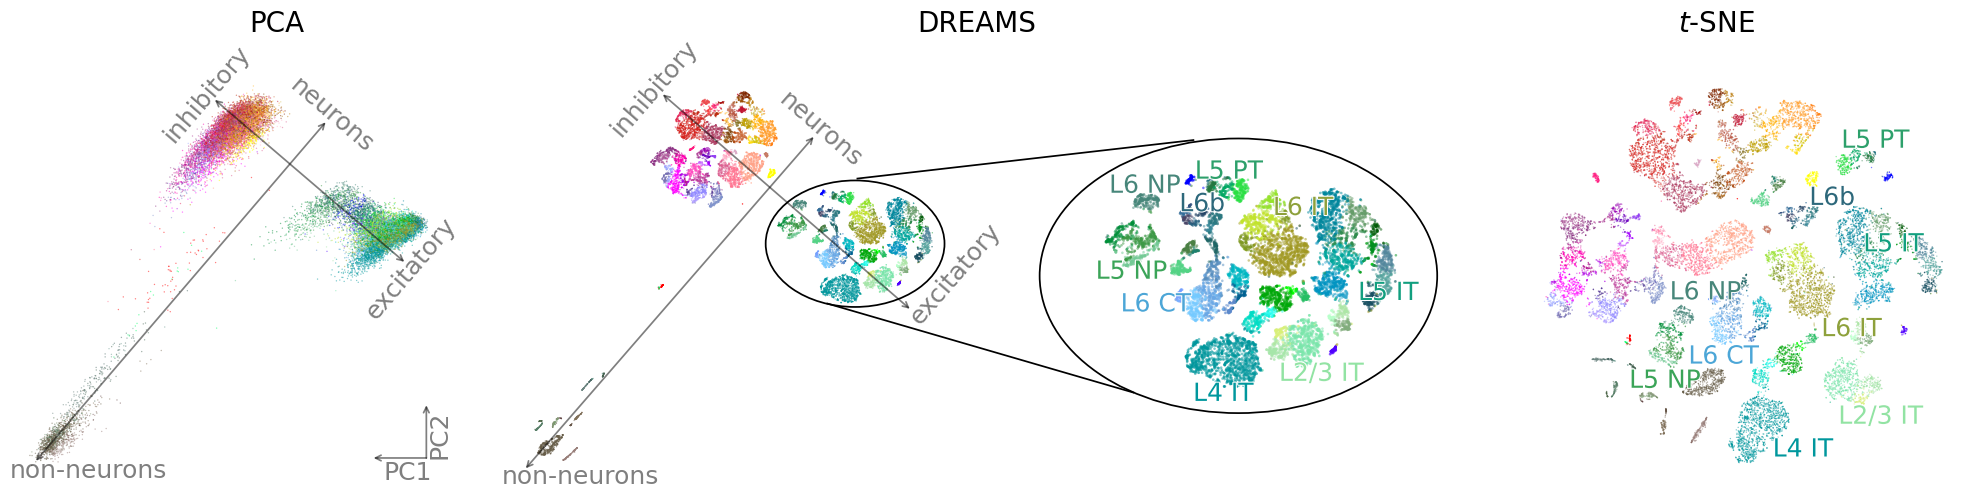

In [136]:
import math
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1,4, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 1, 1, 1]})

# axis
linewidth = 1.25
alpha = 0.5
textfont= 18

# # PCA
plot_embed(tasic_pca2_scaled, tasic_pca2_scaled_eval, tasic_colors, show_eval=False, ax=ax[0], rasterized=True)

# PC1-PC2 axis
ax[0].annotate('', xy=(1.35*0.0001, -2.15*0.0001), xytext=(1.35*0.0001, -2.7*0.0001), 
               arrowprops=dict(arrowstyle='->', color='black', alpha=alpha, linewidth=linewidth, shrinkA=0, shrinkB=0,  # disables shortening at both ends
        connectionstyle="arc3,rad=0"))
ax[0].annotate('', xy=(0.8*0.0001, -2.7*0.0001), xytext=(1.35*0.0001, -2.7*0.0001), 
               arrowprops=dict(arrowstyle='->', color='black', alpha=alpha, linewidth=linewidth, shrinkA=0, shrinkB=0,  # disables shortening at both ends
        connectionstyle="arc3,rad=0"  # straight arrow
))
ax[0].text(1.16*0.0001, -2.725*0.0001, "PC1", va='top', ha='center', fontsize=textfont, alpha=alpha)
ax[0].text(1.49*0.0001, -2.2*0.0001, "PC2", va='top', ha='center', rotation=90, fontsize=textfont, alpha=alpha)

# exc.-inh. & neurons-non neurons axis
start = (0.3*0.0001, 0.8*0.0001)
end = (-2.72*0.0001, -2.73*0.0001)
ax[0].annotate('', xy=end, xytext=start, 
               arrowprops=dict(arrowstyle='<->', color='black', alpha=alpha, linewidth=linewidth, 
               shrinkA=0, shrinkB=0, connectionstyle="arc3,rad=0"))
# Compute orthogonal vector
dx = end[0] - start[0]
dy = end[1] - start[1]
orth_dx, orth_dy = -dy, dx

length = 2.6 * 0.0001
norm = np.sqrt(orth_dx**2 + orth_dy**2)
orth_dx *= length / norm
orth_dy *= length / norm

# Midpoint of original arrow
mid_x = (start[0] + end[0]) / 2
mid_y = (start[1] + end[1]) / 2

# --- Apply shifts ---
# 1. Vertical shift (up/down)
vec = np.array([dx, dy]) / np.sqrt(dx**2 + dy**2)
vertical_shift = -1.75 * 0.0001
mid_x += vertical_shift * vec[0]
mid_y += vertical_shift * vec[1]

# 2. Horizontal shift (left/right)
orth_vec = np.array([orth_dx, orth_dy]) / np.sqrt(orth_dx**2 + orth_dy**2)
horizontal_shift = 0.27 * 0.0001
mid_x += horizontal_shift * orth_vec[0]
mid_y += horizontal_shift * orth_vec[1]

# Compute new orthogonal arrow endpoints
new_start = (mid_x - orth_dx/2, mid_y - orth_dy/2)
new_end = (mid_x + orth_dx/2, mid_y + orth_dy/2)

# Draw orthogonal arrow
ax[0].annotate('', xy=new_end, xytext=new_start,
            arrowprops=dict(arrowstyle='<->', color='black', alpha=alpha, linewidth=linewidth,
                            shrinkA=0, shrinkB=0, connectionstyle="arc3,rad=0"))

# add text
# inhibitory-excitatory axis
orth_dx = new_end[0] - new_start[0]
orth_dy = new_end[1] - new_start[1]
angle_ortho = math.degrees(math.atan2(orth_dy, orth_dx))

# Unit vector along orthogonal arrow
orth_vec = np.array([orth_dx, orth_dy]) / np.sqrt(orth_dx**2 + orth_dy**2)

offset = 0.1 * 0.0001

# Move label away from tail (start) backwards along orth_vec
inhib_x = new_start[0] - offset * orth_vec[0]
inhib_y = new_start[1] - offset * orth_vec[1]

# Move label away from tip (end) forward along orth_vec
excite_x = new_end[0] + offset * orth_vec[0]
excite_y = new_end[1] + offset * orth_vec[1]

ax[0].text(inhib_x, inhib_y, "inhibitory", fontsize=textfont, alpha=alpha,
           rotation=angle_ortho + 90, rotation_mode='anchor',
           ha='center', va='center')

ax[0].text(excite_x, excite_y, "excitatory", fontsize=textfont, alpha=alpha,
           rotation=angle_ortho + 90, rotation_mode='anchor',
           ha='center', va='center')

# neurons-non-neurons axis
dx = end[0] - start[0]
dy = end[1] - start[1]

angle = math.degrees(math.atan2(dy, dx))

# Unit vector along the original arrow
vec = np.array([dx, dy]) / np.sqrt(dx**2 + dy**2)
offset= 0.1 * 0.0001

neurons_x = (start[0]) - offset * vec[0]
neurons_y = (start[1]) - offset * vec[1]

ax[0].text(neurons_x, neurons_y, "neurons", fontsize=textfont, alpha=alpha,
           rotation=angle+90, rotation_mode='anchor',
           ha='center', va='center')

ax[0].text(end[0]+(0.55 * 0.0001), end[1]-(0.1 * 0.0001), "non-neurons", fontsize=textfont, alpha=alpha,
           # rotation=angle+90, rotation_mode='anchor',
           ha='center', va='center')

# DREAMS
plot_embed(dreams_emb, dreams_eval, tasic_colors, show_eval=False, ax=ax[1], rasterized=True)

# axis
# arrows
start = (15, 35)
end = (-117, -117)
ax[1].annotate('', xy=end, xytext=start, 
               arrowprops=dict(arrowstyle='<->', color='black', alpha=alpha, linewidth=linewidth, 
               shrinkA=0, shrinkB=0, connectionstyle="arc3,rad=0"))
# Compute orthogonal vector
dx = end[0] - start[0]
dy = end[1] - start[1]
orth_dx, orth_dy = -dy, dx

length = 150
norm = np.sqrt(orth_dx**2 + orth_dy**2)
orth_dx *= length / norm
orth_dy *= length / norm

# Midpoint of original arrow
mid_x = (start[0] + end[0]) / 2
mid_y = (start[1] + end[1]) / 2

# --- Apply shifts ---
# 1. Vertical shift (up/down)
vec = np.array([dx, dy]) / np.sqrt(dx**2 + dy**2)
vertical_shift = -70
mid_x += vertical_shift * vec[0]
mid_y += vertical_shift * vec[1]

# 2. Horizontal shift (left/right)
orth_vec = np.array([orth_dx, orth_dy]) / np.sqrt(orth_dx**2 + orth_dy**2)
horizontal_shift = 10
mid_x += horizontal_shift * orth_vec[0]
mid_y += horizontal_shift * orth_vec[1]

# Compute new orthogonal arrow endpoints
new_start = (mid_x - orth_dx/2, mid_y - orth_dy/2)
new_end = (mid_x + orth_dx/2, mid_y + orth_dy/2)

# Draw orthogonal arrow
ax[1].annotate('', xy=new_end, xytext=new_start,
            arrowprops=dict(arrowstyle='<->', color='black', alpha=alpha, linewidth=linewidth,
                            shrinkA=0, shrinkB=0, connectionstyle="arc3,rad=0"))

# add text
# inhibitory-excitatory axis
orth_dx = new_end[0] - new_start[0]
orth_dy = new_end[1] - new_start[1]
angle_ortho = math.degrees(math.atan2(orth_dy, orth_dx))

# Unit vector along orthogonal arrow
orth_vec = np.array([orth_dx, orth_dy]) / np.sqrt(orth_dx**2 + orth_dy**2)

offset = 5

# Move label away from tail (start) backwards along orth_vec
inhib_x = new_start[0] - offset * orth_vec[0]
inhib_y = new_start[1] - offset * orth_vec[1]

# Move label away from tip (end) forward along orth_vec
excite_x = new_end[0] + offset * orth_vec[0]
excite_y = new_end[1] + offset * orth_vec[1]

ax[1].text(inhib_x, inhib_y, "inhibitory", fontsize=textfont, alpha=alpha,
           rotation=angle_ortho + 90, rotation_mode='anchor',
           ha='center', va='center')

# neurons-non-neurons axis
dx = end[0] - start[0]
dy = end[1] - start[1]

ax[1].text(excite_x - 0.13 * dx, excite_y - 0.13 * dy, "excitatory", fontsize=textfont, alpha=alpha,
           rotation=angle_ortho + 90, rotation_mode='anchor',
           ha='center', va='center')


angle = math.degrees(math.atan2(dy, dx))

# Unit vector along the original arrow
vec = np.array([dx, dy]) / np.sqrt(dx**2 + dy**2)

neurons_x = (start[0]) - offset * vec[0]
neurons_y = (start[1]) - offset * vec[1]

ax[1].text(neurons_x, neurons_y, "neurons", fontsize=textfont, alpha=alpha,
           rotation=angle+90, rotation_mode='anchor',
           ha='center', va='center')

ax[1].text(end[0]+25, end[1]-3.5, "non-neurons", fontsize=textfont, alpha=alpha,
           # rotation=angle+90, rotation_mode='anchor',
           ha='center', va='center')

# ellipse excitatory
l_col = 'black'
l_width = 1.25
l_alpha = 1.0
center = (34, -14)

ellipse1 = Ellipse(center, 82, 58, angle=0,
                  edgecolor=l_col, facecolor='none', linewidth=l_width, alpha=l_alpha)

ax[1].add_patch(ellipse1)

# Dreams onyl excitatory
import matplotlib.patheffects as path_effects
path_effects = [
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ]

ax[2].scatter(dreams_o_excit[:, 0], dreams_o_excit[:, 1], c=cols_o_excit, alpha=0.5, s=3.5, cmap="tab10", edgecolor="none", rasterized=True)

center2 = (31, -14)
ellipse2 = Ellipse(center2, 97, 67, angle=0,
                  edgecolor=l_col, facecolor='none', linewidth=l_width, alpha=l_alpha)

ax[2].add_patch(ellipse2)

def data_to_fig_coords(ax, x, y):
    return fig.transFigure.inverted().transform(ax.transData.transform((x, y)))

# Convert both centers to figure coordinates
fig_xy1 = data_to_fig_coords(ax[1], *center)

# lower line
line = Line2D([fig_xy1[0]-0.033, fig_xy1[0]+0.12],
              [fig_xy1[1]-0.117, fig_xy1[1]-0.295],
              transform=fig.transFigure,
              color=l_col, linewidth=l_width, alpha=l_alpha)
fig.lines.append(line)

# upper line
line = Line2D([fig_xy1[0]-0.018, fig_xy1[0]+0.15],
              [fig_xy1[1]+0.133, fig_xy1[1]+0.21],
              transform=fig.transFigure,
              color=l_col, linewidth=l_width, alpha=l_alpha)
fig.lines.append(line)

# Plot centroids for each keyword
font = 18
c1 = centroids_o_ex['L2/3 IT']
ax[2].text(c1[0]-7, c1[1]-12, 'L2/3 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L2/3 IT'], path_effects=path_effects)
c2 = centroids_o_ex['L4 IT']
ax[2].text(c2[0]-8, c2[1]-11.5, 'L4 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L4 IT'], path_effects=path_effects)
c3 = centroids_o_ex['L5 IT']
ax[2].text(c3[0]+8, c3[1]-11, 'L5 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 IT'], path_effects=path_effects)
c4 = centroids_o_ex['L5 NP']
ax[2].text(c4[0] -9.5, c4[1] - 10, 'L5 NP', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 NP'], path_effects=path_effects)
c5 = centroids_o_ex['L5 PT']
ax[2].text(c5[0]-3, c5[1]+8, 'L5 PT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 PT'], path_effects=path_effects)
c6 = centroids_o_ex['L6 IT']
ax[2].text(c6[0] -5, c6[1] + 8, 'L6 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 IT'], path_effects=path_effects)
c7 = centroids_o_ex['L6 CT']
ax[2].text(c7[0] - 23, c7[1]-6, 'L6 CT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 CT'], path_effects=path_effects)
c8 = centroids_o_ex['L6 NP']
ax[2].text(c8[0] - 9, c8[1] + 1, 'L6 NP', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 NP'], path_effects=path_effects)
c9 = centroids_o_ex['L6b']
ax[2].text(c9[0]-6, c9[1] + 2, 'L6b', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6b'], path_effects=path_effects)

ax[2].set_aspect("equal")
ax[2].axis("off")

# t-SNE
import matplotlib.patheffects as path_effects
path_effects = [
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ]

ax[3].scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=tasic_colors, alpha=0.5, s=1.0, cmap="tab10", edgecolor="none", rasterized=True)

font = 18
# Plot centroids for each keyword
c1 = centroids['L2/3 IT']
ax[3].text(c1[0]-7, c1[1]-28, 'L2/3 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L2/3 IT'], path_effects=path_effects)
c2 = centroids['L4 IT']
ax[3].text(c2[0] + 7, c2[1]-17, 'L4 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L4 IT'], path_effects=path_effects)
c3 = centroids['L5 IT']
ax[3].text(c3[0]+6, c3[1]+12, 'L5 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 IT'], path_effects=path_effects)
c4 = centroids['L5 NP']
ax[3].text(c4[0] -19, c4[1] -23, 'L5 NP', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 NP'], path_effects=path_effects)
c5 = centroids['L5 PT']
ax[3].text(c5[0] + 9, c5[1]+11, 'L5 PT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L5 PT'], path_effects=path_effects)
c6 = centroids['L6 IT']
ax[3].text(c6[0] - 3, c6[1] - 29, 'L6 IT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 IT'], path_effects=path_effects)
c7 = centroids['L6 CT']
ax[3].text(c7[0] - 24, c7[1] -25, 'L6 CT', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 CT'], path_effects=path_effects)
c8 = centroids['L6 NP']
ax[3].text(c8[0] - 7, c8[1] + 5, 'L6 NP', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6 NP'], path_effects=path_effects)
c9 = centroids['L6b']
ax[3].text(c9[0]+9, c9[1]+8, 'L6b', fontsize=font, ha='left', va='bottom', c=mean_colors_hex['L6b'], path_effects=path_effects)

ax[3].set_aspect("equal")
ax[3].axis("off")

title_font = 20
fig.text(0.15, 1.0, "PCA", fontsize=title_font, ha='center', va='center')
fig.text(0.5, 1.0, "DREAMS", fontsize=title_font, ha='center', va='center')
fig.text(0.87, 1.0, "$t$-SNE", fontsize=title_font, ha='center', va='center')

plt.tight_layout()

## figure 2

In [112]:
# Load other methods
tasic_umap_results = tasic_om_results['umap']
tasic_umap_emb = tasic_umap_results['seed_0']['embedding']
tasic_umap_eval = tasic_umap_results['seed_0']['eval']

tasic_trimap_results = tasic_om_results['trimap']
tasic_trimap_emb = tasic_trimap_results['seed_0']['embedding']
tasic_trimap_eval = tasic_trimap_results['seed_0']['eval']

tasic_starmap_results = tasic_om_results['star_map']
tasic_starmap_emb = tasic_starmap_results['seed_0']['embedding']
tasic_starmap_eval = tasic_starmap_results['seed_0']['eval']

tasic_mds_hybrid_results = tasic_om_results['squad_mds_hybrid']
tasic_mds_hybrid_emb = tasic_mds_hybrid_results['seed_0']['embedding']
tasic_mds_hybrid_eval = tasic_mds_hybrid_results['seed_0']['eval']

In [113]:
# Load Dreams spectrum
tsne_emb = tasic_reg_results['seed_0']['lambda_0.0']['embedding']
tsne_eval = tasic_reg_results['seed_0']['lambda_0.0']['eval']

tasic_dreams_05 = tasic_reg_results['seed_0']['lambda_0.05']['embedding']
tasic_dreams_05_eval = tasic_reg_results['seed_0']['lambda_0.05']['eval']

tasic_dreams_01 = tasic_reg_results['seed_0']['lambda_0.15000000000000002']['embedding']
tasic_dreams_01_eval = tasic_reg_results['seed_0']['lambda_0.15000000000000002']['eval']

tasic_dreams_02 = tasic_reg_results['seed_0']['lambda_0.25']['embedding']
tasic_dreams_02_eval = tasic_reg_results['seed_0']['lambda_0.25']['eval']

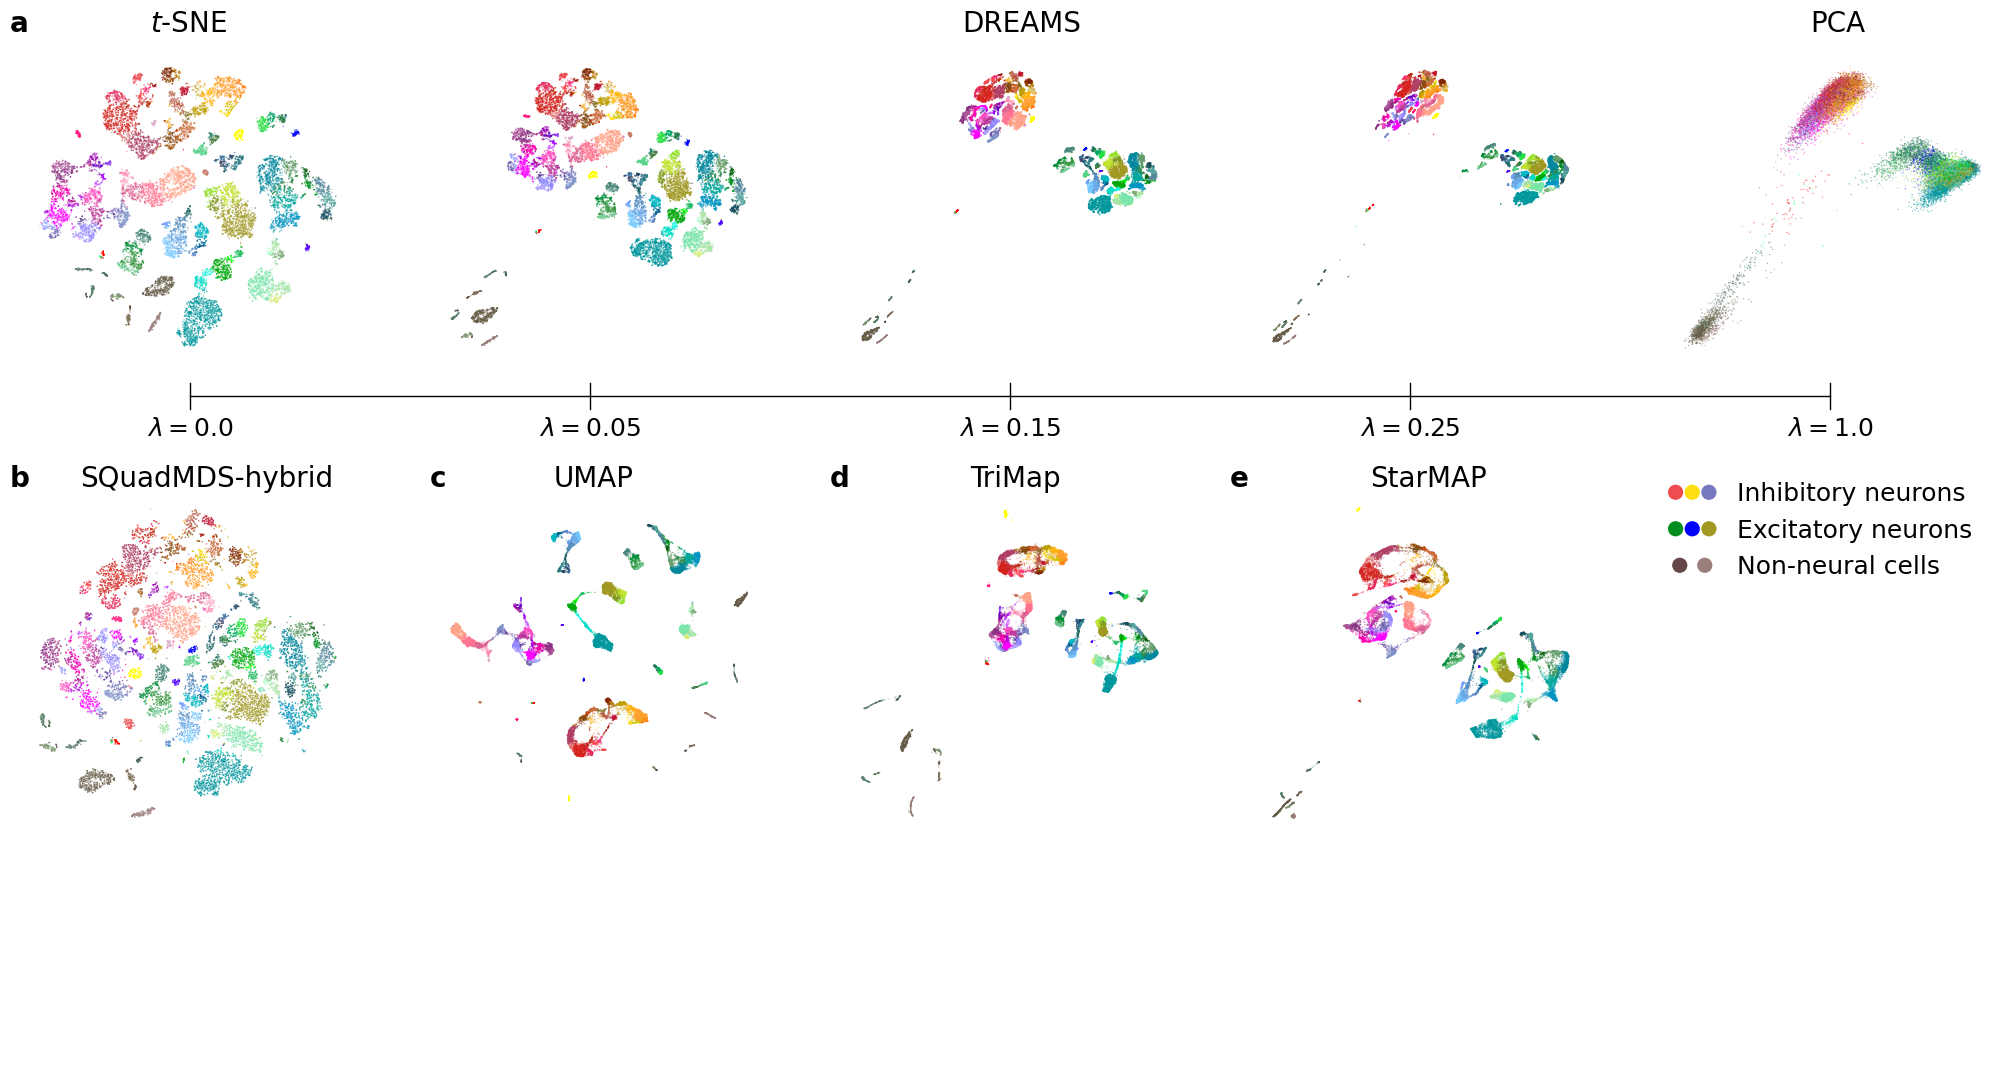

In [114]:
# Plot figure 2
from matplotlib.lines import Line2D
from scipy.linalg import orthogonal_procrustes

Xc = tasic_pca2_scaled - tasic_pca2_scaled.mean(axis=0)

fig, ax = plt.subplots(2, 5, figsize=(20, 13))

fig.text(0.0, 0.81, "a", fontsize=20, fontweight='bold')
fig.text(0.07, 0.81, r'$t$-SNE', fontsize=20)
fig.text(0.476, 0.81, 'DREAMS', fontsize=20)
fig.text(0.9, 0.81, 'PCA', fontsize=20)

eval_size = 14
title_size = 16
plot_embed(tsne_emb, tsne_eval, tasic_colors, ax=ax[0,0], eval_size=eval_size, title_size=title_size, show_eval=False, show_KNC=False, rasterized=True)
plot_embed(tasic_dreams_05, tasic_dreams_05_eval, tasic_colors, ax=ax[0,1], eval_size=eval_size, title_size=title_size, show_eval=False, show_KNC=False, rasterized=True)
plot_embed(tasic_dreams_01, tasic_dreams_01_eval, tasic_colors, ax=ax[0,2],  eval_size=eval_size, title_size=title_size, show_eval=False, show_KNC=False, rasterized=True)
plot_embed(tasic_dreams_02, tasic_dreams_02_eval, tasic_colors, ax=ax[0,3],  eval_size=eval_size, title_size=title_size, show_eval=False, show_KNC=False, rasterized=True)
plot_embed(tasic_pca2_scaled, tasic_pca2_scaled_eval, tasic_colors, ax=ax[0,4],  eval_size=eval_size, title_size=title_size, show_eval=False, show_KNC=False, rasterized=True)

# second row
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerBase

plot_embed(tasic_mds_hybrid_emb, tasic_mds_hybrid_eval, tasic_colors, ax=ax[1,0], show_eval=False, show_KNC=False, rasterized=True)
umap_c = tasic_umap_emb - tasic_umap_emb.mean(axis=0)
R,_ = orthogonal_procrustes(Xc, umap_c)
umap_alligned = tasic_umap_emb @ R
plot_embed(umap_alligned, tasic_umap_eval, tasic_colors, ax=ax[1,1], show_eval=False, show_KNC=False, rasterized=True)
trimap_c = tasic_trimap_emb - tasic_trimap_emb.mean(axis=0)
R,_ = orthogonal_procrustes(Xc, trimap_c)
trimap_alligned = tasic_trimap_emb @ R
plot_embed(trimap_alligned, tasic_trimap_eval, tasic_colors, ax=ax[1,2], show_eval=False, show_KNC=False, rasterized=True)
plot_embed(tasic_starmap_emb, tasic_starmap_eval, tasic_colors, ax=ax[1,3], show_eval=False, show_KNC=False, rasterized=True)

group_colors = [
    [col_inhib_0, col_inhib_1, col_inhib_2],
    [col_excit_0, col_excit_1, col_excit_2],
    [col_non_neural_0, col_non_neural_1]
]

ax[1,4].axis('off')


# Labels for each group
legend_labels = ['Inhibitory neurons', 'Excitatory neurons', 'Non-neural cells']

# Create dummy handles
dummy_handles = [plt.Line2D([], [], linestyle='None') for _ in group_colors]

# Custom handler that draws multiple colored circles in one legend entry
class MultiColorCircleHandler(HandlerBase):
    def __init__(self, colors, **kwargs):
        super().__init__(**kwargs)
        self.colors = colors

    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        n = len(self.colors)
        radius = height / 2.3
        spacing = width / max(n, 1)
        artists = []
        for i, c in enumerate(self.colors):
            center = (x0 + i * spacing + spacing/2, y0 + height / 2)
            circle = Circle(center, radius=radius, facecolor=c, edgecolor='none', transform=trans)
            artists.append(circle)
        return artists

# Build handler_map with actual color groups
handler_map = {
    dummy_handles[i]: MultiColorCircleHandler(group_colors[i])
    for i in range(len(group_colors))
}

# Add the custom legend
ax[1,4].legend(dummy_handles, legend_labels, handler_map=handler_map, loc='upper right', fontsize=18, frameon=False, bbox_to_anchor=(1, 0.75))

descr = ["b", "c", "d", "e"]
positions = [
    (0., 0.46),  # ax[1, 0]
    (0.21, 0.46),  # ax[1, 1]
    (0.41, 0.46),  # ax[1, 2]
    (0.61, 0.46),  # ax[1, 3]
]

for label, (x, y) in zip(descr, positions):
    fig.text(x, y, label, fontsize=20, fontweight="bold")

meth = ["SQuadMDS-hybrid", "UMAP", "TriMap", "StarMAP"]
positions = [
    (0.035, 0.46),  
    (0.272, 0.46),  
    (0.48, 0.46),  
    (0.68, 0.46),  
]

for label, (x, y) in zip(meth, positions):
    fig.text(x, y, label, fontsize=20)

fig.lines.append(plt.Line2D(
            [0.09, 0.91],
            [0.53, 0.53],
            transform=fig.transFigure,
            color="black",
            linewidth=1
        ))

x_ticks_pos = [0.09, 0.29, 0.5, 0.70, 0.91]
lam_vals = [0.0, 0.05, 0.15, 0.25, 1.0]

for i, pos in enumerate(x_ticks_pos):
    fig.lines.append(plt.Line2D(
            [pos, pos],
            [0.54, 0.52],
            transform=fig.transFigure,
            color="black",
            linewidth=1
        ))
    fig.text(pos, 0.495, f'$\lambda={lam_vals[i]}$', fontsize=18, ha='center', va='bottom')

plt.subplots_adjust(hspace=-1.0)
plt.tight_layout()


## figure 3

In [116]:
import matplotlib.cm as cm
import math

import matplotlib.patheffects as path_effects
path_effects = [
        path_effects.Stroke(linewidth=0.2, foreground='white'),
        path_effects.Normal()
    ]

In [138]:
symbol_dict = {
    'Tasic et al.': {method: 'o' for method in dict_all_data['Tasic et al.'].keys()},
    'Macosko et al.': {method: 'o' for method in dict_all_data['Macosko et al.'].keys()},
    'Kanton et al.': {method: 'o' for method in dict_all_data['Kanton et al.'].keys()},
    'Wagner et al.': {method: 'o' for method in dict_all_data['Wagner et al.'].keys()},
    'Packer et al.': {method: 'o' for method in dict_all_data['Packer et al.'].keys()},
    '1000 Genomes': {method: 'o' for method in dict_all_data['1000 Genomes'].keys()},
    'Mammoth': {method: 'o' for method in dict_all_data['Mammoth'].keys()},
    'Satellite': {method: 'o' for method in dict_all_data['Satellite'].keys()},
    'FMNIST': {method: 'o' for method in dict_all_data['FMNIST'].keys()},
    'MNIST': {method: 'o' for method in dict_all_data['MNIST'].keys()},
    'CIFAR10': {method: 'o' for method in dict_all_data['CIFAR10'].keys()},
}

In [139]:
symbol_dict['Tasic et al.']['star_map'] = 'v'
symbol_dict['Tasic et al.']['trimap'] = '^'

symbol_dict['Macosko et al.']['star_map'] = 'v'
symbol_dict['Macosko et al.']['trimap'] = '^'
symbol_dict['Macosko et al.']['trimap'] = '^'
symbol_dict['Macosko et al.']['umap'] = 'v'
symbol_dict['Macosko et al.']['phate'] = '^'

symbol_dict['Kanton et al.']['DREAMS-MDS'] = 'v'
symbol_dict['Kanton et al.']['DREAMS'] = '^'

symbol_dict['Wagner et al.']['star_map'] = 'v'
symbol_dict['Wagner et al.']['trimap'] = '^'

symbol_dict['1000 Genomes']['pacmap'] = '^'
symbol_dict['1000 Genomes']['trimap'] = 'v'
symbol_dict['1000 Genomes']['DREAMS'] = 'v'
symbol_dict['1000 Genomes']['squad_mds_hybrid'] = '^'

symbol_dict['Mammoth']['DREAMS'] = 'v'
symbol_dict['Mammoth']['DREAMS-MDS'] = '^'

symbol_dict['Satellite']['DREAMS'] = 'v'
symbol_dict['Satellite']['DREAMS-MDS'] = '^'

symbol_dict['FMNIST']['pacmap'] = '^'
symbol_dict['FMNIST']['phate'] = '^'
symbol_dict['FMNIST']['umap'] = 'v'
symbol_dict['FMNIST']['DREAMS'] = 'v'
symbol_dict['FMNIST']['DREAMS-MDS'] = 'v'
symbol_dict['FMNIST']['squad_mds_hybrid'] = '^'

symbol_dict['MNIST']['pacmap'] = 'v'
symbol_dict['MNIST']['phate'] = '^'

symbol_dict['CIFAR10']['DREAMS'] = 'v'
symbol_dict['CIFAR10']['DREAMS-MDS'] = 'v'
symbol_dict['CIFAR10']['squad_mds_hybrid'] = '^'
symbol_dict['CIFAR10']['pacmap'] = 'v'
symbol_dict['CIFAR10']['umap'] = '^'
symbol_dict['CIFAR10']['star_map'] = 'v'

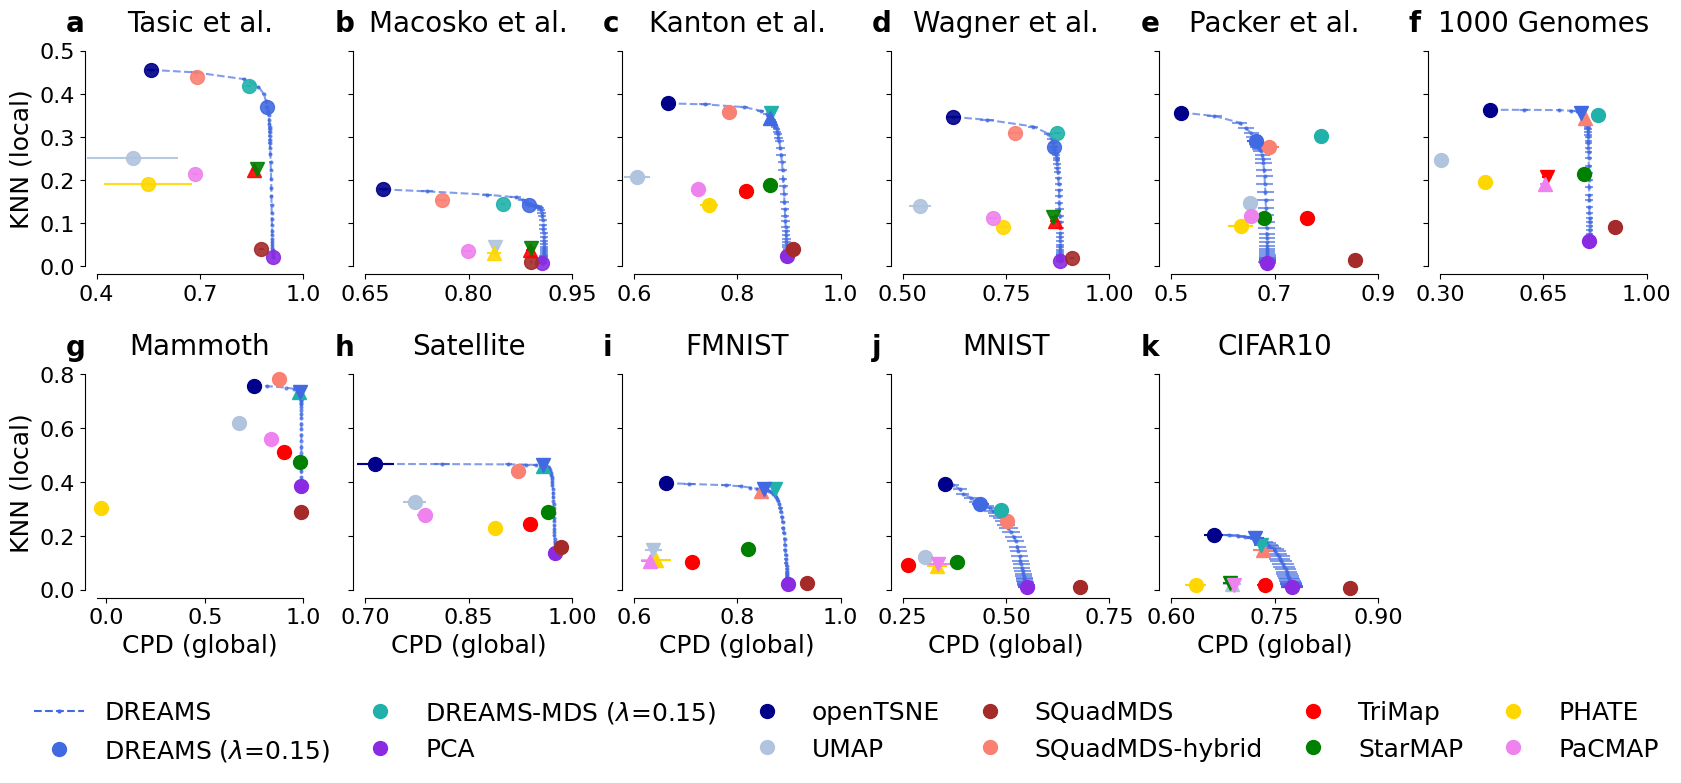

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import string

# --- Configuration ---
marker_size = 2
scatter_size = 10

# Colors
col_errorbar = 'royalblue'
dreams_knn_curves = [
    (tasic_reg_knn_means, tasic_reg_knn_stds),
    (retina_reg_knn_means, retina_reg_knn_stds),
    (kanton_reg_knn_means, kanton_reg_knn_stds),
    (zfish_reg_knn_means, zfish_reg_knn_stds),
    (c_el_reg_knn_means, c_el_reg_knn_stds),
    (genome_reg_knn_means, genome_reg_knn_stds),
    (mammoth_reg_knn_means, mammoth_reg_knn_stds),
    (satellite_reg_knn_means, satellite_reg_knn_stds),
    (f_mnist_reg_knn_means, f_mnist_reg_knn_stds),
    (mnist_reg_knn_means, mnist_reg_knn_stds),
    (cifar10_reg_knn_means, cifar10_reg_knn_stds),
]
dreams_cpd_curves = [
    (tasic_reg_cpd_means, tasic_reg_cpd_stds),
    (retina_reg_cpd_means, retina_reg_cpd_stds),
    (kanton_reg_cpd_means, kanton_reg_cpd_stds),
    (zfish_reg_cpd_means, zfish_reg_cpd_stds),
    (c_el_reg_cpd_means, c_el_reg_cpd_stds),
    (genome_reg_cpd_means, genome_reg_cpd_stds),
    (mammoth_reg_cpd_means, mammoth_reg_cpd_stds),
    (satellite_reg_cpd_means, satellite_reg_cpd_stds),
    (f_mnist_reg_cpd_means, f_mnist_reg_cpd_stds),
    (mnist_reg_cpd_means, mnist_reg_cpd_stds),
    (cifar10_reg_cpd_means, cifar10_reg_cpd_stds),

]

col_dreams = 'royalblue'
col_dreams_mds = 'lightseagreen'
col_pca = 'blueviolet'
col_tsne = 'darkblue'
colors = ['royalblue', 'lightseagreen', 'blueviolet', 'darkblue', 'lightsteelblue', 'brown', 'salmon', 'red', 'green', 'gold', 'violet']
methods_title = ['DREAMS', 'DREAMS-MDS', 'PCA', 'openTSNE', 'UMAP', 'SQuadMDS', 'SQuadMDS-hybrid', 'TriMap', 'StarMAP', 'PHATE', 'PaCMAP']
# change key order and remove some methods
methods_keys = ['DREAMS', 'DREAMS-MDS', 'PCA', 'openTSNE', 'umap', 'squad_mds', 'squad_mds_hybrid', 'trimap', 'star_map', 'phate', 'pacmap']
# --- Plot Loop ---

# --- Setup: 6 plots on top, 5 centered on bottom ---
ncols_top = 6
ncols_bottom = 5

fig = plt.figure(figsize=(20, 7), constrained_layout=True)
gs = gridspec.GridSpec(2, ncols_top, height_ratios=[1, 1], hspace=0.5, wspace=0.3)

# Top row: sharey within this row
axes_top = [fig.add_subplot(gs[0, i]) for i in range(ncols_top)]
for i in range(1, len(axes_top)):
    axes_top[i].sharey(axes_top[0])
    axes_top[i].tick_params(labelleft=False)

# Bottom row: sharey within this row
start_col = (ncols_top - ncols_bottom) // 2
axes_bottom = [fig.add_subplot(gs[1, start_col + i]) for i in range(ncols_bottom)]
for i in range(1, len(axes_bottom)):
    axes_bottom[i].sharey(axes_bottom[0])
    axes_bottom[i].tick_params(labelleft=False)

# Combine all axes for your existing loop
ax = axes_top + axes_bottom

# Now your plotting loop stays the same:
plotting_order = ['Tasic et al.', 'Macosko et al.', 'Kanton et al.', 'Wagner et al.', 'Packer et al.','1000 Genomes', 'Mammoth', 'Satellite', 'FMNIST', 'MNIST', 'CIFAR10']
for i, name in enumerate(plotting_order):
    d = dict_all_data[name]
    a = ax[i]
    a.set_title(name, fontsize=20, pad=14)

    # Tradeoff curve
    knn_curve, knn_std = dreams_knn_curves[i]
    cpd_curve, cpd_std = dreams_cpd_curves[i]
    a.errorbar(cpd_curve, knn_curve,
               xerr=cpd_std, yerr=knn_std,
               fmt='o--', c=col_errorbar, zorder=-1,
               markersize=marker_size, clip_on=False, alpha=0.65)

    alpha = 0.9 if name in ['Tasic et al.', 'Macosko et al.', 'Wagner et al.'] else 1.0
    for j, method in enumerate(methods_keys):
        if method not in ['DREAMS-CNE', 'DREAMS-CNE-Decoder', 'InfoNC-t-SNE']:
            knn_means = d[method]['KNN']
            knn_stds = d[method]['KNN_std']
            cpd_means = d[method]['CPD']
            cpd_stds = d[method]['CPD_std']
            color = colors[j]
            marker = symbol_dict[name][method]  # 'v' if method in ['star_map', 'pacmap', 'DREAMS'] else '^' if method in ['trimap', 'phate', 'umap', 'DREAMS-MDS', 'squad_mds_hybrid'] else 'o'
            # if method == 'umap':
            #     a.errorbar(cpd_means, knn_means, xerr=cpd_stds, yerr=knn_stds,
            #            fmt=marker, markersize=scatter_size, c=color, clip_on=False, alpha=alpha, zorder=5)
            #else:
            order = 3 if method == 'DREAMS' else 2 if method == 'DREAMS-MDS' else 1
            a.errorbar(cpd_means, knn_means, xerr=cpd_stds, yerr=knn_stds,
                       fmt=marker, markersize=scatter_size, c=color, clip_on=False, alpha=alpha, zorder=order)

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylim(0)
    a.spines['left'].set_position(('outward', 8.5))
    a.spines['bottom'].set_position(('outward', 6))

    label = f"{string.ascii_lowercase[i]}"
    a.text(-0.15, 1.19, label, transform=a.transAxes,
           fontsize=20, va='top', ha='left', fontweight='bold')

    # Set dataset-specific ticks/x-limits
    if name == 'Tasic et al.':
        a.set_xticks([0.4, 0.7, 1.0])
        a.set_xlim([0.4, 1.0])
    elif name == 'Kanton et al.':
        a.set_xticks([0.6, 0.8, 1.0])
        a.set_xlim([0.6, 1.0])
    elif name == '1000 Genomes':
        a.set_xticks([0.3, 0.65, 1.0])
        a.set_xlim([0.3, 1.0])
    elif name == 'Wagner et al.':
        a.set_xticks([0.5, 0.75, 1.0])
        a.set_xlim([0.5, 1.0])
    elif name == 'Packer et al.':
        a.set_xticks([0.5, 0.7, 0.9])
        a.set_xlim([0.5, 0.9])
    elif name == 'MNIST':
        a.set_xticks([0.25, 0.5, 0.75])
        a.set_xlim([0.25, 0.75])
    elif name == 'Macosko et al.':
        a.set_xticks([0.65, 0.8, 0.95])
        a.set_xlim([0.65, 0.95])
    elif name == 'Mammoth':
        a.set_xticks([0.0, 0.5, 1.0])
        a.set_xlim([-0.05, 1.0])
    elif name == 'Satellite':
        a.set_xticks([0.7, 0.85, 1.0])
        a.set_xlim([0.7, 1.0])
    elif name == 'FMNIST':
        a.set_xticks([0.6, 0.8, 1.0])
        a.set_xlim([0.6, 1.0])
    elif name == 'CIFAR10':
        a.set_xticks([0.6, 0.75, 0.9])
        a.set_xlim([0.6, 0.9])

    a.tick_params(axis='both', labelsize=16)

# Apply shared axis labels if desired
axes_top[0].set_ylabel('KNN (local)', fontsize=18)
axes_bottom[0].set_ylabel('KNN (local)', fontsize=18)
for a in axes_bottom:
    a.set_xlabel('CPD (global)', fontsize=18)
    a.set_ylim(0.0, 0.8)


ax[0].set_ylim(0.0, 0.5)
ax[0].set_yticks([0.0, 0.1, 0.2,0.3,0.4, 0.5])

ax[0].set_ylabel('KNN (local)', fontsize=18)

# --- Legend ---
handles = [
    plt.Line2D([0], [0], color=col_errorbar, marker='o', linestyle='--', markersize=marker_size, label='DREAMS'),
    plt.Line2D([0], [0], color=col_dreams, marker='o', linestyle='None', markersize=scatter_size, label='DREAMS ($\\lambda$=0.15)'),
    plt.Line2D([0], [0], color=col_dreams_mds, marker='o', linestyle='None', markersize=scatter_size, label='DREAMS-MDS ($\\lambda$=0.15)'),
    *[plt.Line2D([0], [0], color=colors[i], marker='o', linestyle='None', markersize=scatter_size, label=methods_title[i]) for i in range(2, len(methods_title))],
]

# Place the legend below the entire figure
fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.17),  
    ncol=(len(handles)+1) // 2,
    columnspacing=1.0,
    fontsize=18,
    frameon=False
)


## figure 4

In [143]:
# PCA means
tasic_pca_knn_mean = datasets_pca['Tasic et al.']['eval']['knn_mean']
tasic_pca_cpd_mean = datasets_pca['Tasic et al.']['eval']['cpd_mean']
c_el_pca_knn_mean = datasets_pca['Packer et al.']['eval']['knn_mean']
c_el_pca_cpd_mean = datasets_pca['Packer et al.']['eval']['cpd_mean']

# MDS means
tasic_mds_knn = []
tasic_mds_cpd = []
c_el_mds_knn = []
c_el_mds_cpd = []

for i in range(4):
    eval = tasic_om_results['squad_mds'][f'seed_{i}']['eval']
    tasic_mds_knn.append(eval[0])
    tasic_mds_cpd.append(eval[2])

    eval_c = c_el_om_results['squad_mds'][f'seed_{i}']['eval']
    c_el_mds_knn.append(eval_c[0])
    c_el_mds_cpd.append(eval_c[2])

tasic_mds_knn = np.array(tasic_mds_knn)
tasic_mds_cpd = np.array(tasic_mds_cpd)
c_el_mds_knn = np.array(c_el_mds_knn)
c_el_mds_cpd = np.array(c_el_mds_cpd)

tasic_mds_knn_mean = np.mean(tasic_mds_knn)
tasic_mds_cpd_mean = np.mean(tasic_mds_cpd)
c_el_mds_knn_mean = np.mean(c_el_mds_knn)
c_el_mds_cpd_mean = np.mean(c_el_mds_cpd)

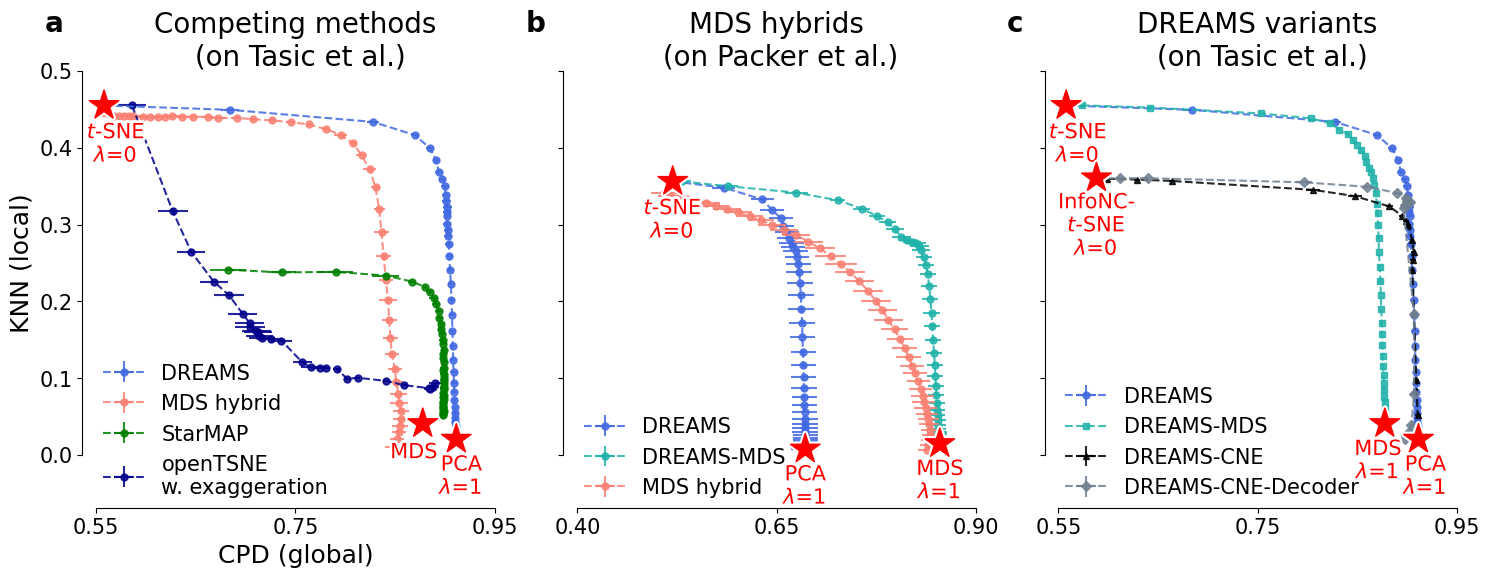

In [152]:
# figure 4
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import string

fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

# own methods
col_pca = 'blueviolet'
col_tsne = 'darkblue'
col_dreams = 'royalblue'
col_dreams_mds = 'lightseagreen'

star_size = 500
text_size = 15
marker_size = 5
alpha = 0.85

# panel a - other methods
# PCA
ax[0].scatter(tasic_pca_cpd_mean, tasic_pca_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[0].text(tasic_pca_cpd_mean + 0.005, tasic_pca_knn_mean - 0.071, "PCA\n$\\lambda$=1", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# MDS
ax[0].scatter(tasic_mds_cpd_mean, tasic_mds_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[0].text(tasic_mds_cpd_mean - 0.009, tasic_mds_knn_mean - 0.045, "MDS", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# oenTSNE
ax[0].scatter(tasic_reg_cpd_means.iloc[0], tasic_reg_knn_means.iloc[0], label='_nolegend_', c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[0].text(tasic_reg_cpd_means.iloc[0] + 0.012, tasic_reg_knn_means.iloc[0] - 0.073, "$t$-SNE\n$\\lambda$=0", ha='center', fontsize=text_size, c='r', zorder=11, path_effects=[pe.withStroke(linewidth=4, foreground='white')])

# curves
ax[0].errorbar(tasic_reg_cpd_means, tasic_reg_knn_means, xerr=tasic_reg_cpd_stds, yerr=tasic_reg_knn_stds, fmt='o--', c=col_dreams, label="DREAMS", zorder=6, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[0].errorbar(tasic_mds_hy_cpd_means, tasic_mds_hy_knn_means, xerr=tasic_mds_hy_cpd_stds, yerr=tasic_mds_hy_knn_stds, fmt='o--', c='salmon', label="MDS hybrid", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[0].errorbar(tasic_starmap_cpd_means, tasic_starmap_knn_means, xerr=tasic_starmap_cpd_stds, yerr=tasic_starmap_knn_stds, fmt='o--', c='green', label="StarMAP", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[0].errorbar(tasic_tsne_exag_cpd_means, tasic_tsne_exag_knn_means, xerr=tasic_tsne_exag_cpd_stds, yerr=tasic_tsne_exag_knn_stds, fmt='o--', c='darkblue', label="openTSNE\nw. exaggeration", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_xlabel('CPD (global)', fontsize=18)
ax[0].set_ylabel('KNN (local)', fontsize=18)

# panel b
ax[1].errorbar(c_el_reg_cpd_means, c_el_reg_knn_means, xerr=c_el_reg_cpd_stds, yerr=c_el_reg_knn_stds, fmt='o--', c=col_dreams, label="DREAMS", zorder=6, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[1].errorbar(c_el_mds_reg_cpd_means, c_el_mds_reg_knn_means, xerr=c_el_mds_reg_cpd_stds, yerr=c_el_mds_reg_knn_stds, fmt='o--', c=col_dreams_mds, label="DREAMS-MDS", zorder=6, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[1].errorbar(c_el_mds_hy_cpd_means, c_el_mds_hy_knn_means, xerr=c_el_mds_hy_cpd_stds, yerr=c_el_mds_hy_knn_stds, fmt='o--', c='salmon', label="MDS hybrid", zorder=7, markersize=marker_size, linewidth=1.5, alpha=alpha)

# PCA
ax[1].scatter(c_el_pca_cpd_mean, c_el_pca_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[1].text(c_el_pca_cpd_mean, c_el_pca_knn_mean - 0.071, "PCA\n$\\lambda$=1", ha='center', fontsize=text_size, c='r', zorder=10,  path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# MDS
ax[1].scatter(c_el_mds_cpd_mean, c_el_mds_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[1].text(c_el_mds_cpd_mean, c_el_mds_knn_mean - 0.071, "MDS\n$\\lambda$=1", ha='center', fontsize=text_size, c='r', zorder=10,  path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# openTSNE
ax[1].scatter(c_el_reg_cpd_means.iloc[0], c_el_reg_knn_means.iloc[0], label='_nolegend_', c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
ax[1].text(c_el_reg_cpd_means.iloc[0], c_el_reg_knn_means.iloc[0] - 0.073, "$t$-SNE\n$\\lambda$=0", ha='center', fontsize=text_size, c='r', zorder=10,  path_effects=[pe.withStroke(linewidth=4, foreground='white')])

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# panel c
# PCA
ax[2].scatter(tasic_pca_cpd_mean, tasic_pca_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[2].text(tasic_pca_cpd_mean + 0.007, tasic_pca_knn_mean - 0.071, "PCA\n$\\lambda$=1", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# MDS
ax[2].scatter(tasic_mds_cpd_mean, tasic_mds_knn_mean, label="_nolegend_", c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[2].text(tasic_mds_cpd_mean - 0.007, tasic_mds_knn_mean - 0.071, "MDS\n$\\lambda$=1", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# openTSNE
ax[2].scatter(tasic_reg_cpd_means.iloc[0], tasic_reg_knn_means.iloc[0], label='_nolegend_', c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False)
ax[2].text(tasic_reg_cpd_means.iloc[0] + 0.012, tasic_reg_knn_means.iloc[0] - 0.073, "$t$-SNE\n$\\lambda$=0", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
# InfoNC-t-SNE
ax[2].scatter(tasic_cne_reg_cpd_means.iloc[0], tasic_cne_reg_knn_means.iloc[0], label='_nolegend_', c='r', s=star_size, marker='*', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])
ax[2].text(tasic_cne_reg_cpd_means.iloc[0], tasic_cne_reg_knn_means.iloc[0] - 0.1, "InfoNC-\n$t$-SNE\n$\\lambda$=0", ha='center', fontsize=text_size, c='r', zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')])

# curves
ax[2].errorbar(tasic_reg_cpd_means, tasic_reg_knn_means, xerr=tasic_reg_cpd_stds, yerr=tasic_reg_knn_stds, fmt='o--', c=col_dreams, label="DREAMS", zorder=-1, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[2].errorbar(tasic_mds_reg_cpd_means, tasic_mds_reg_knn_means, fmt='s--', c=col_dreams_mds, label="DREAMS-MDS", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[2].errorbar(b_tasic_cne_reg_cpd_means, b_tasic_cne_reg_knn_means, xerr=b_tasic_cne_reg_cpd_stds, yerr=b_tasic_cne_reg_knn_stds, fmt='^--', c='black', label="DREAMS-CNE", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)
ax[2].errorbar(b_tasic_cne_dec_cpd_means, b_tasic_cne_dec_knn_means, xerr=b_tasic_cne_dec_cpd_stds, yerr=b_tasic_cne_dec_knn_stds, fmt='D--', c='slategray', label="DREAMS-CNE-Decoder", zorder=5, markersize=marker_size, linewidth=1.5, alpha=alpha)

ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

titles = ['Competing methods\n (on Tasic et al.)', 'MDS hybrids\n (on Packer et al.)', 'DREAMS variants\n (on Tasic et al.)']

for i in range(3):
    ax[i].tick_params(axis='both', labelsize=15)
    ax[i].tick_params(axis='both', labelsize=15)

    ax[i].set_ylim(0.0, 0.5)
    ax[i].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

    ax[i].set_xlim(0.55, 0.95)
    ax[i].set_xticks([0.55, 0.75, 0.95])

    if i == 1:
        ax[i].set_xlim(0.4, 0.9)
        ax[i].set_xticks([0.4, 0.65, 0.9])

    ax[i].spines['left'].set_position(('outward', 10))
    ax[i].spines['bottom'].set_position(('outward', 38))

    # add bold letter labels
    label = f"{string.ascii_lowercase[i]}"
    ax[i].text(-0.13, 1.16, label, transform=ax[i].transAxes,
               fontsize=20, va='top', ha='left', fontweight='bold')
    
    ax[i].set_title(titles[i], fontsize=20, pad=0)

    ax[i].legend(fontsize=15, frameon=False, loc='lower left', bbox_to_anchor=(-0.03, -0.16))

plt.tight_layout()
plt.show()

# Abstract

## Score visualization

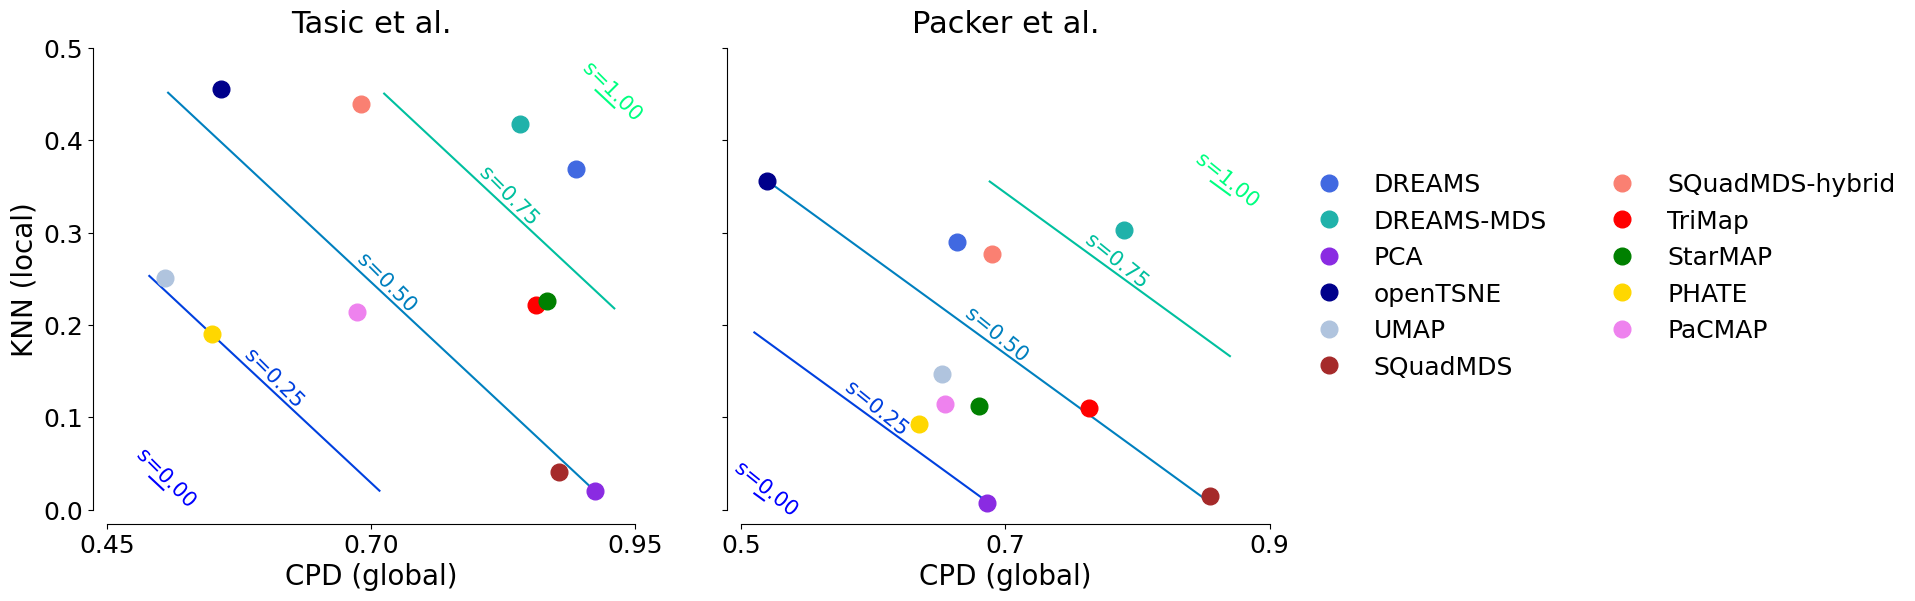

In [ ]:
datasets_score = ['Tasic et al.', 'Packer et al.']
scatter_size = 12

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i, name in enumerate(datasets_score):
    knns = []
    cpds = []
    d = dict_all_data[name]
    a = ax[i]
    a.set_title(name, fontsize=22, pad=11)

    if name in ['Tasic et al.', 'Macosko et al.', 'Wagner et al.']:
        alpha = 0.9
    else:
        alpha = 1.0
    for j, method in enumerate(methods_keys):
        knns.append(d[method]['KNN'])
        cpds.append(d[method]['CPD'])
        if method not in ['DREAMS-CNE', 'DREAMS-CNE-Decoder', 'InfoNC-t-SNE']:
            knn_means = d[method]['KNN']
            knn_stds = d[method]['KNN_std']
            cpd_means = d[method]['CPD']
            cpd_stds = d[method]['CPD_std']
            
            color = colors[j]
            a.errorbar(cpd_means, knn_means, fmt='o', markersize=scatter_size, c=color, clip_on=False)

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylim(0)  # Set y-limits for consistency
    # Move left spine a bit away from x=0
    a.spines['left'].set_position(('outward', 10))
    # Move bottom spine a bit upward from y=0
    a.spines['bottom'].set_position(('outward', 10))

    # x label ticks
    if name == 'Tasic et al.':
        tasic_x_min, tasic_x_max = 0.49, 0.93
        a.set_xticks([0.45, 0.70, 0.95])
        a.set_xlim([0.45, 0.95])
    elif name == 'Packer et al.':
        packer_x_min, packer_x_max = 0.51, 0.87
        a.set_xticks([0.5, 0.7, 0.9])
        a.set_xlim([0.5, 0.9])

    a.set_ylim(0.0, 0.5)
    a.set_yticks([0.0, 0.1, 0.2,0.3,0.4, 0.5])

    # scores
    knn_min, knn_max = min(knns), max(knns)
    cpd_min, cpd_max = min(cpds), max(cpds)

    s = np.linspace(0, 1, 5)
    if name == 'Tasic et al.':
        x_min, x_max = tasic_x_min, tasic_x_max
    elif name == 'Packer et al.':
        x_min, x_max = packer_x_min, packer_x_max
    cpd_range = np.linspace(x_min, x_max, 100)

    cmap = cm.winter  

    for i, s_val in enumerate(s):
        knns = knn_min + (knn_max - knn_min) * (2 * s_val - (cpd_range - cpd_min) / (cpd_max - cpd_min))

        knn_mask = (knns >= knn_min) & (knns <= knn_max)
        cpds_filtered = cpd_range[knn_mask]
        knns_filtered = knns[knn_mask]

        fontsize = 15
        if name == 'Tasic et al.':
            a.plot(cpds_filtered, knns_filtered, color=cmap(i / (len(s) - 1)), clip_on=False)
            a.text(cpds_filtered[len(cpds_filtered)//2]-0.024, knns_filtered[len(knns_filtered)//2]-0.024, f's={s_val:.2f}', color=cmap(i / (len(s) - 1)), rotation=-45, path_effects=path_effects, fontsize=fontsize)

        elif name == 'Packer et al.':
            a.plot(cpds_filtered, knns_filtered, color=cmap(i / (len(s) - 1)), clip_on=False)
            a.text(cpds_filtered[len(cpds_filtered)//2]-0.021, knns_filtered[len(knns_filtered)//2]-0.021, f's={s_val:.2f}', color=cmap(i / (len(s) - 1)), rotation=-39, path_effects=path_effects, fontsize=fontsize)

        a.tick_params(axis='both', labelsize=18)


ax[0].set_ylabel('KNN (local)', fontsize=20)
ax[0].set_xlabel('CPD (global)', fontsize=20)
ax[1].set_xlabel('CPD (global)', fontsize=20)

handles = [
    plt.Line2D([0], [0], color=col_dreams, marker='o', linestyle='None', markersize=scatter_size, label='DREAMS'),
    plt.Line2D([0], [0], color=col_dreams_mds, marker='o', linestyle='None', markersize=scatter_size, label='DREAMS-MDS'),
    *[plt.Line2D([0], [0], color=colors[i], marker='o', linestyle='None', markersize=scatter_size, label=methods_title[i]) for i in range(2, len(methods_title))],
]

# Place the legend below the entire figure
fig.legend(
    handles=handles,
    loc='center',
    bbox_to_anchor=(1.12, 0.5),  
    ncol=2,
    fontsize=18,
    frameon=False
)

## different k for KNN

In [ ]:
knn_for_diff_k = {}
cpd_for_diff_k = {}
k_values = [1, 5, 10, 20, 100, 200]

for method in tasic_om_results.keys():
    knn_for_diff_k[method] = {}
    cpd_for_diff_k[method] = {}

    for k in k_values:
        knn_list = []
        cpd_list = []

        for rs in range(4):
            seed_key = f'seed_{rs}'
            emb = tasic_om_results[method][seed_key]['embedding']
            knn, _, cpd = embedding_quality(emb, tasic_pca50, tasic_ttypes, knn=k)
            knn_list.append(knn)
            cpd_list.append(cpd)

        knn_list = np.array(knn_list)
        cpd_list = np.array(cpd_list)
        knn_mean = np.mean(knn_list)
        knn_std = np.std(knn_list)
        cpd_mean = np.mean(cpd_list)
        cpd_std = np.std(cpd_list)

        knn_for_diff_k[method][k] = {'KNN': knn_mean, 'KNN_std': knn_std}
        cpd_for_diff_k[method][k] = {'CPD': cpd_mean, 'CPD_std': cpd_std}


In [ ]:
df_knn = pd.DataFrame({
    method: {k: vals['KNN'] for k, vals in k_dict.items()}
    for method, k_dict in knn_for_diff_k.items()
}).T
df_knn_std = pd.DataFrame({
    method: {k: vals['KNN_std'] for k, vals in k_dict.items()}
    for method, k_dict in knn_for_diff_k.items()
}).T
df_cpd = pd.DataFrame({
    method: {k: vals['CPD'] for k, vals in k_dict.items()}
    for method, k_dict in cpd_for_diff_k.items()
}).T
display(df_knn)

,1,5,10,20,100,200
DREAMS,0.206658,0.344066,0.399337,0.452910,0.586971,0.639506
DREAMS-MDS,0.261691,0.391315,0.431839,0.468513,0.573785,0.619393
openTSNE,0.334491,0.436357,0.455204,0.476518,0.576980,0.633601
PCA,0.003106,0.012342,0.020468,0.033215,0.086892,0.124205
squad_mds,0.005919,0.023522,0.040802,0.068417,0.196940,0.282489
squad_mds_hybrid,0.576736,0.474158,0.439025,0.436083,0.517370,0.546317
pacmap,0.043951,0.144549,0.213767,0.288548,0.508706,0.609325
phate,0.052084,0.146631,0.189797,0.231119,0.354914,0.435107
trimap,0.043678,0.148298,0.221928,0.302005,0.521653,0.617875
star_map,0.057195,0.161596,0.225896,0.300927,0.509570,0.598816


In [ ]:
df_knn_norm = (df_knn - df_knn.min()) / (df_knn.max() - df_knn.min())
df_cpd_norm = (df_cpd - df_cpd.min()) / (df_cpd.max() - df_cpd.min())
df_score = 0.5 * (df_knn_norm + df_cpd_norm)

display(df_score)

,1,5,10,20,100,200
DREAMS,0.643732,0.825460,0.902053,0.939681,0.966308,0.966308
DREAMS-MDS,0.615102,0.800016,0.862837,0.880680,0.876526,0.870194
openTSNE,0.384346,0.554570,0.595497,0.595497,0.585508,0.589768
PCA,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
squad_mds,0.458123,0.467776,0.479057,0.495376,0.565702,0.609256
squad_mds_hybrid,0.721935,0.721935,0.703326,0.676328,0.652345,0.631513
pacmap,0.272118,0.379654,0.458833,0.524505,0.658263,0.707231
phate,0.112316,0.215018,0.264374,0.292840,0.337604,0.371295
trimap,0.465641,0.577474,0.661981,0.733444,0.864969,0.909288
star_map,0.492971,0.607420,0.682092,0.747776,0.868437,0.906343


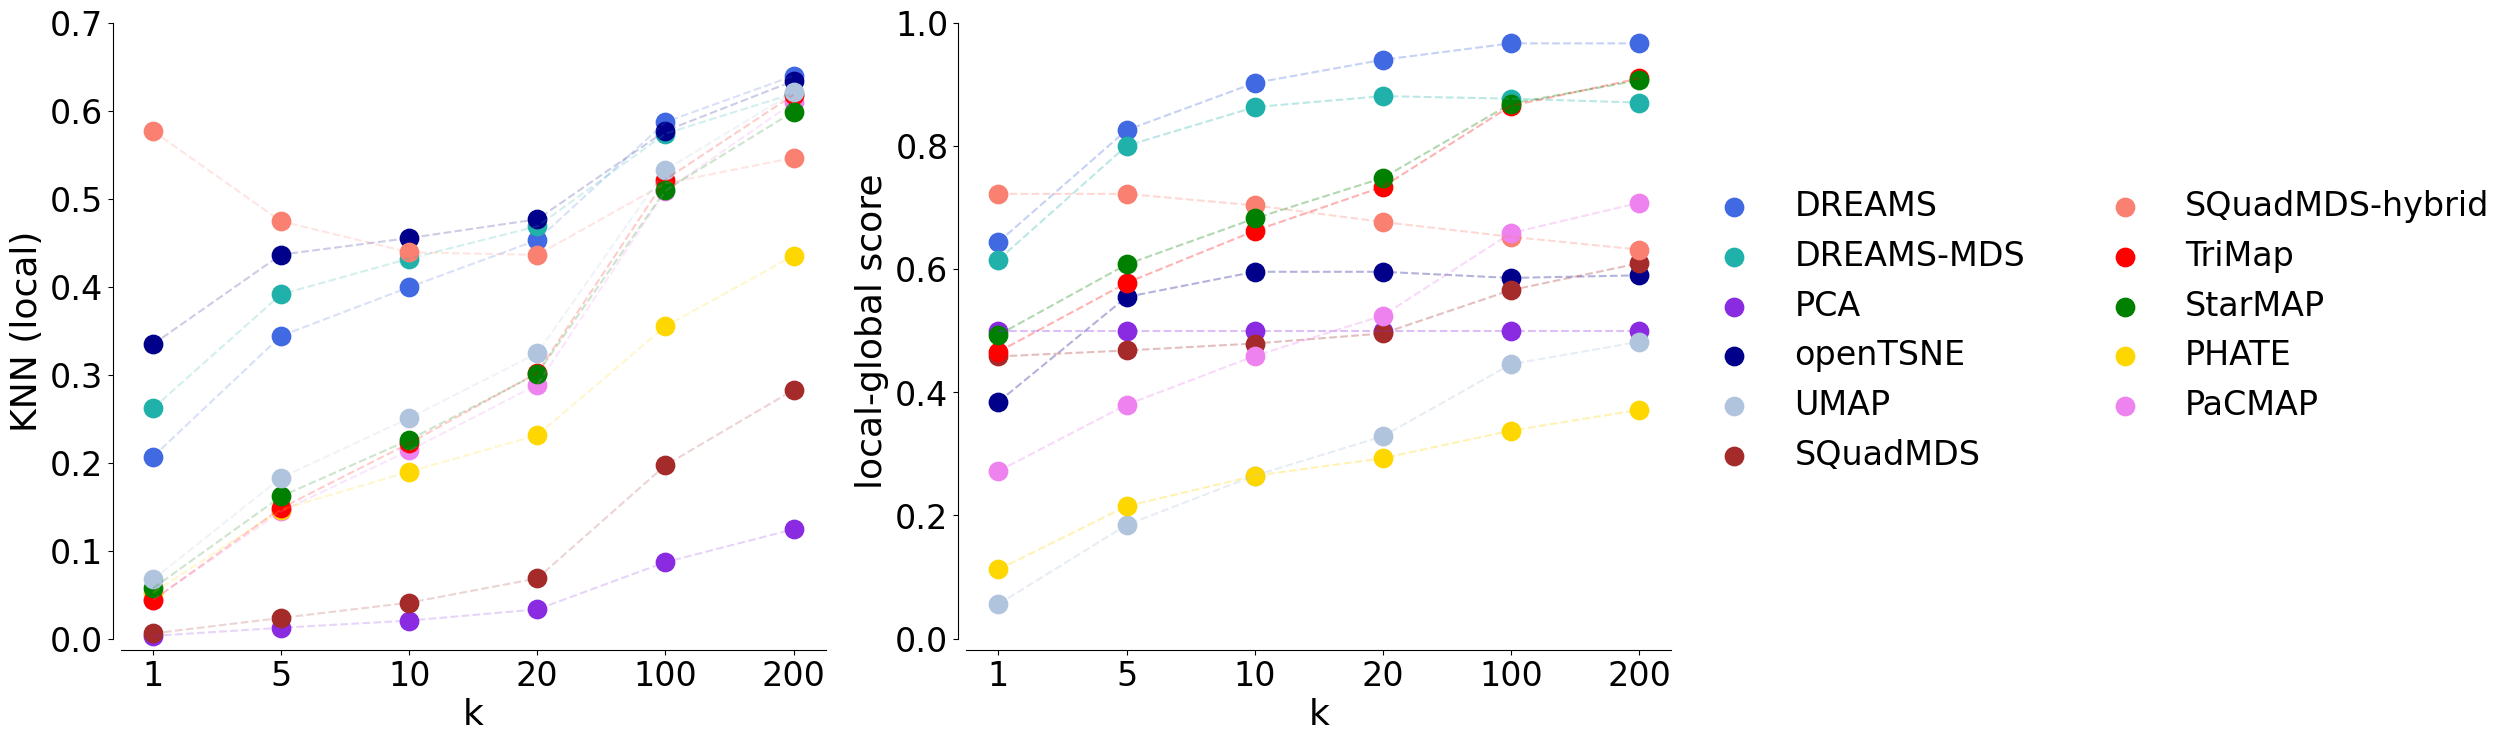

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

s = 175
fontsize = 24

for i, method in enumerate(knn_for_diff_k.keys()):
    col = dict_methods[method]['color']
    x_vals = []
    y_vals = []
    label = dict_methods[method]['title']

    for k in knn_for_diff_k[method].keys():
        knn = knn_for_diff_k[method][k]['KNN']
        knn_std = knn_for_diff_k[method][k]['KNN_std']

        # scatter points with error bars
        ax[0].scatter(
            str(k), knn, color=col, s=s,
            label=label if k == list(knn_for_diff_k[method].keys())[0] else "",
            clip_on=False
        )

        # store x/y for the dashed line
        x_vals.append(str(k))
        y_vals.append(knn)

    # plot dashed line connecting points
    ax[0].plot(x_vals, y_vals, linestyle='--', color=col, alpha=0.2)

# score plot
legend_order = ['DREAMS', 'DREAMS-MDS', 'PCA', 'openTSNE', 'umap', 'squad_mds', 'squad_mds_hybrid', 'trimap', 'star_map', 'phate', 'pacmap']
for i, method in enumerate(legend_order):
    col = dict_methods[method]['color']
    label = dict_methods[method]['title']
    x_vals = []
    y_vals = []

    for k in score_dict[method].keys():
        score = score_dict[method][k]

        # scatter points with error bars
        ax[1].scatter(
            str(k), score, color=col, s=s,
            label=label if k == list(score_dict[method].keys())[0] else "",
            clip_on=False
        )

        # store x/y for the dashed line
        x_vals.append(str(k))
        y_vals.append(score)

    # plot dashed line connecting points
    ax[1].plot(x_vals, y_vals, linestyle='--', color=col, alpha=0.3)

for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlabel('k', fontsize=fontsize+2)
    ax[i].tick_params(axis='both', labelsize=fontsize)
    ax[i].spines['left'].set_position(('outward', 6))
    ax[i].spines['bottom'].set_position(('outward', 8))


ax[0].set_ylabel('KNN (local)', fontsize=fontsize+2)
#ax[0].set_xticks([0.35, 0.65, 1.0])
ax[0].set_ylim([0.0, 0.7])

ax[1].set_ylabel('local-global score', fontsize=fontsize+2)
ax[1].set_ylim([0.0, 1.0])


ax[1].legend(fontsize=fontsize, frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)

## figure all data

In [ ]:
from scipy.linalg import orthogonal_procrustes

def procrustes(reference, emb):
    ref_centered = reference - reference.mean(axis=0)
    emb_centered = emb - emb.mean(axis=0)
    R, _ = orthogonal_procrustes(emb_centered, ref_centered)
    aligned_emb = emb @ R
    return aligned_emb

In [ ]:
eval_size = 18
title_height = 1.0
title_font = 20
marker_size = 12

dict_plot = {
    '1st_row': {
        'keys':['openTSNE', 'umap', 'InfoNC-t-SNE'], 
        'titles':['openTSNE', 'UMAP', 'InfoNC-$t$-SNE',]
    },
    '2nd_row': {
        'keys':['DREAMS', 'DREAMS-MDS', 'DREAMS-CNE', 'DREAMS-CNE-Decoder'], 
        'titles':['DREAMS', 'DREAMS-MDS', 'DREAMS-CNE', 'DREAMS-CNE-Decoder']
    },
    '3rd_row': {
        'keys': ['PCA', 'squad_mds', 'squad_mds_hybrid', 'star_map'],
        'titles': ['PCA', 'SQuadMDS', 'SQuadMDS-hybrid', 'StarMap']
    },
    '4th_row': {
        'keys': ['trimap', 'phate', 'pacmap'],
        'titles': ['TriMap', 'PHATE', 'PaCMAP']
    }
}

### Tasic

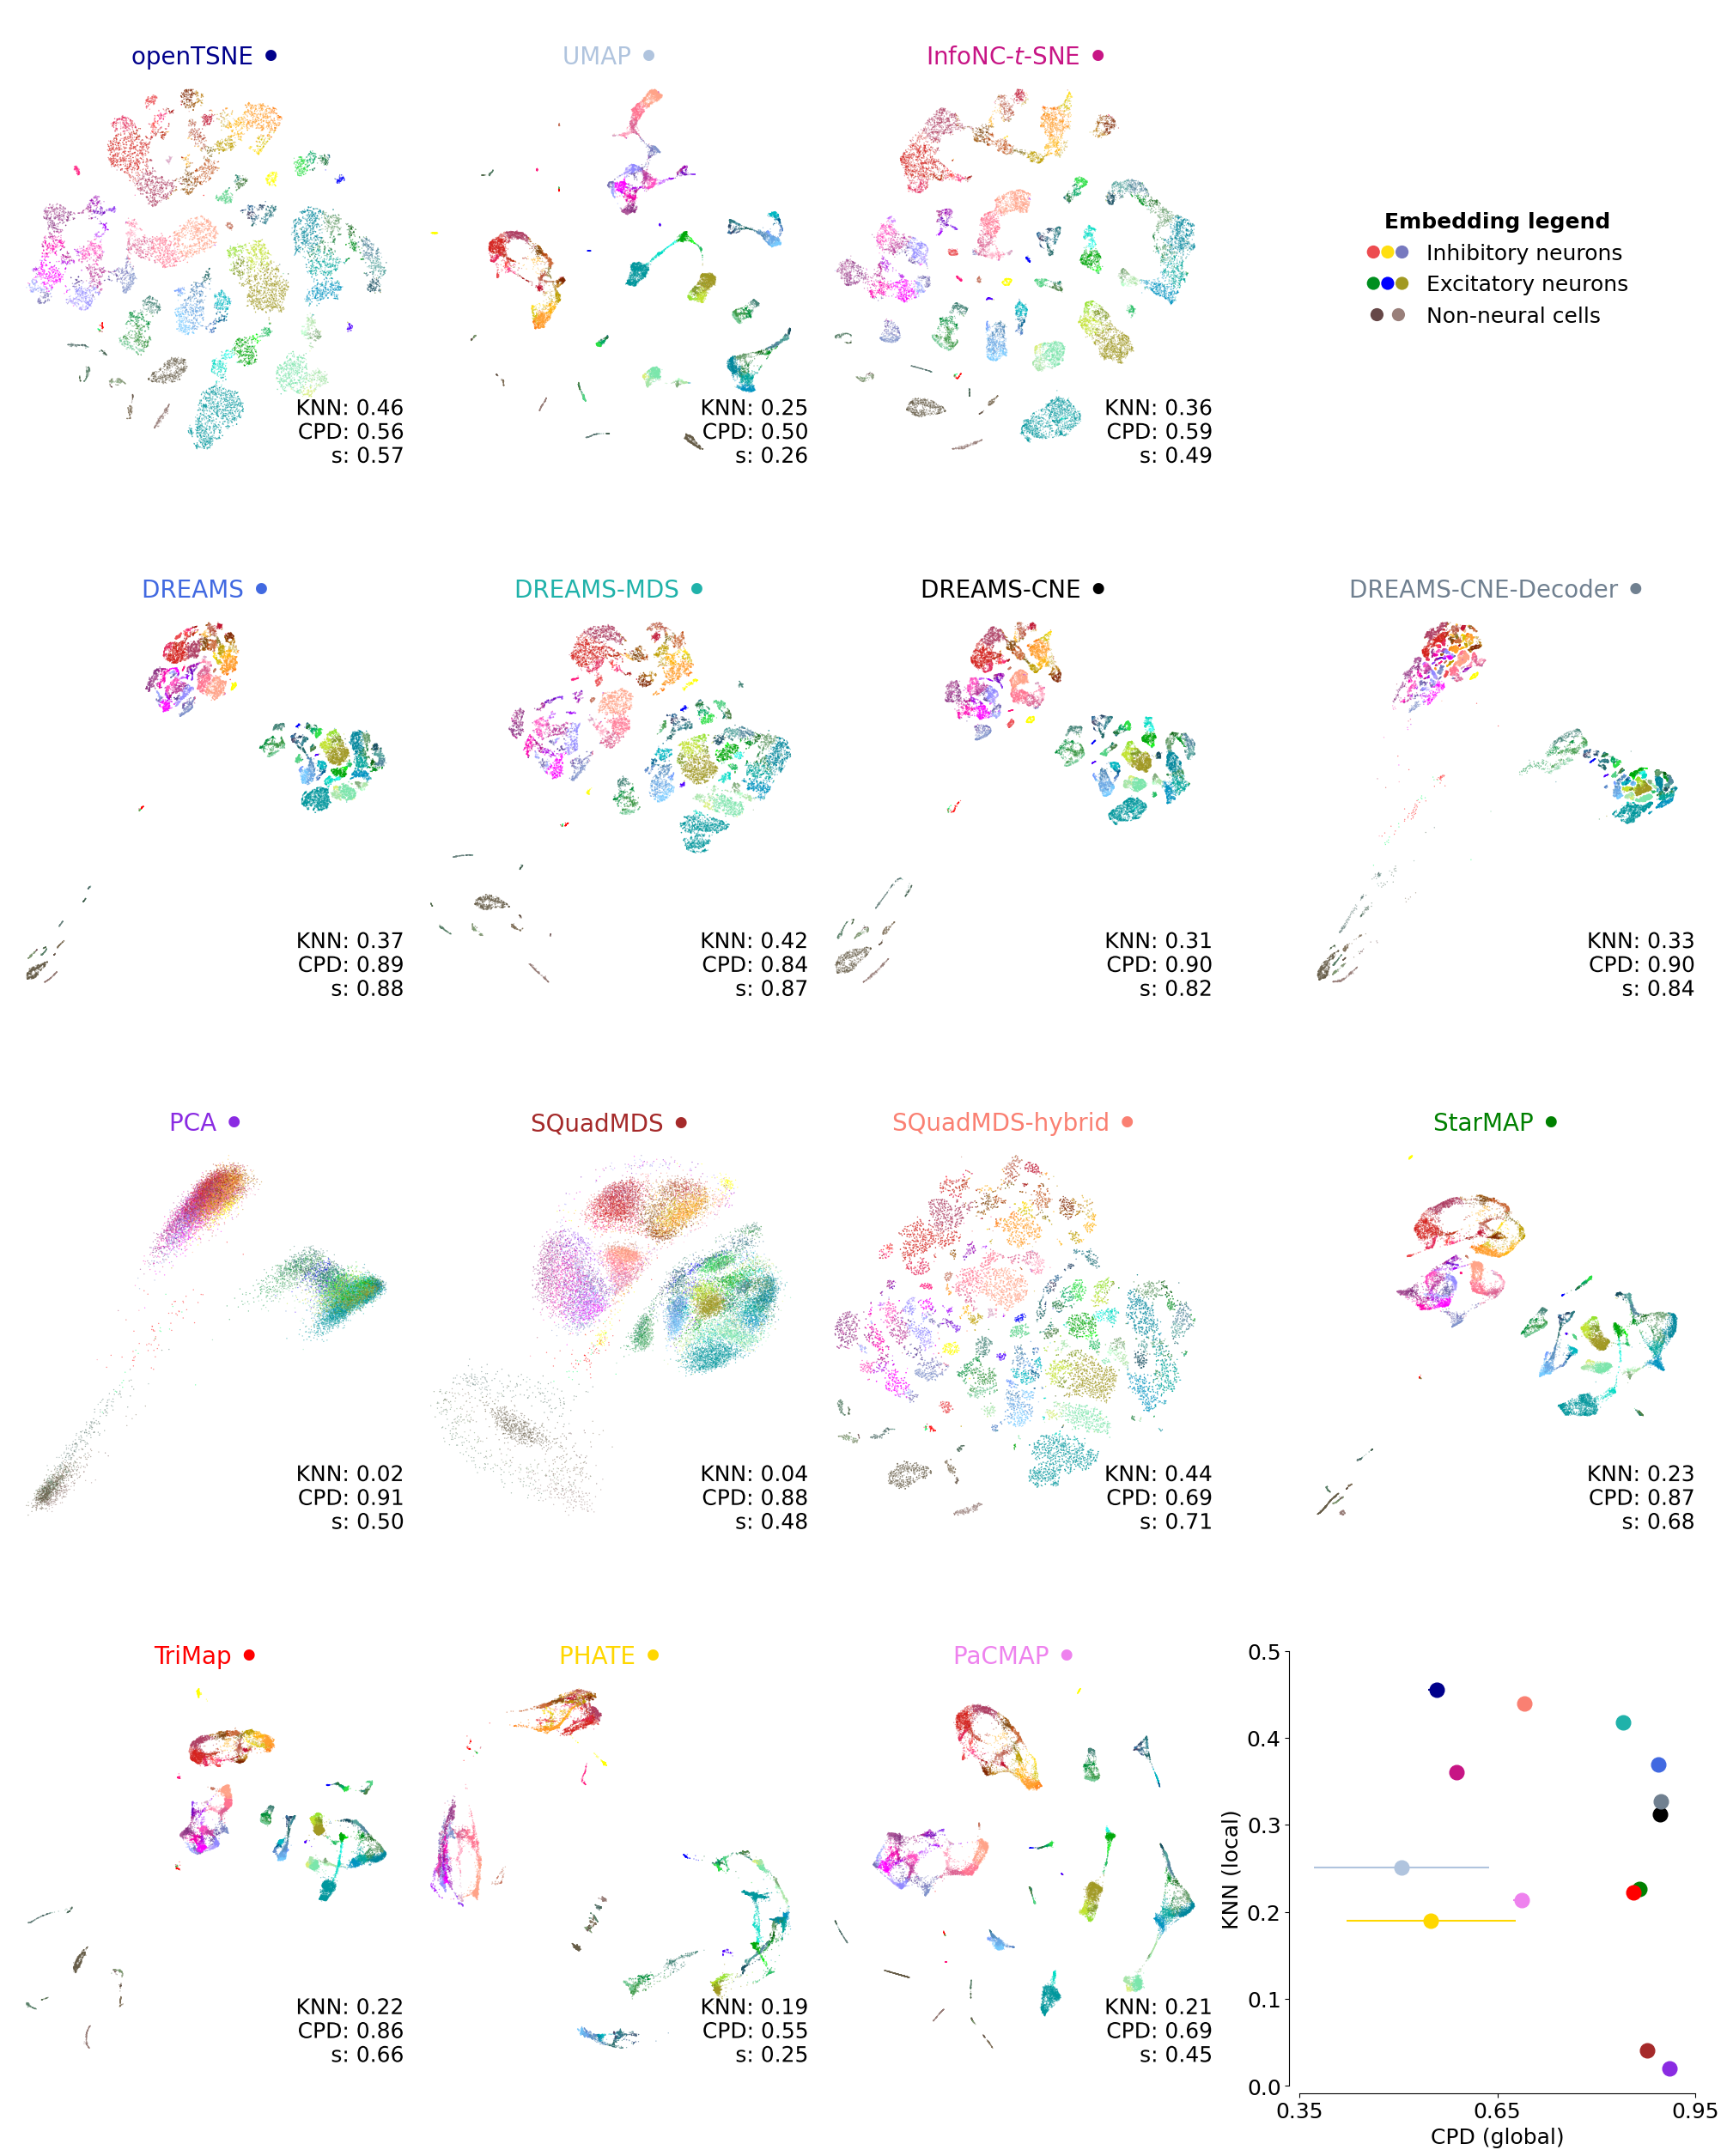

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4}) # , 'hspace': 0.1

dataset_name = 'Tasic et al.'
colors = tasic_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = tasic_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0,3].legend(dummy_handles, legend_labels, handler_map=handler_map, loc='center', fontsize=eval_size, frameon=False, title='Embedding legend', title_fontsize=eval_size)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.5)
ax[3,3].set_xticks([0.35, 0.65, 0.95])
ax[3,3].set_xlim([0.35, 0.95])
ax[3,3].tick_params(axis='both', labelsize=18)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Macosko

In [ ]:
import matplotlib.lines as mlines

retina_handles_dict = {
    'Rods and cones': '#538cba',
    'Bipolar cells': '#2000d7',
    'Amacrine cells': '#9ac222',
    'Horizontal cells': '#b33b19',
    'Ganglion cells': '#c38a1f',
    'Non-neural cells': '#8b006b'
                      }

retina_legend_handles = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=label)
    for label, color in retina_handles_dict.items()
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = 'Macosko et al.'
colors = retina_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = retina_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=retina_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.2)
ax[3,3].set_yticks([0.0, 0.05,0.1,0.15,0.2])
ax[3,3].set_xticks([0.65, 0.8, 0.95])
ax[3,3].set_xlim([0.65, 0.95])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Kanton

In [ ]:
kanton_handles_dict = {
    '0 days': 'navy',
    '4 days': 'royalblue',
    '10 days': 'skyblue',
    '15 days': 'lightgreen',
    '1 month': 'gold',
    '2 month': 'tomato',
    '3 months': 'maroon', 
}

kanton_legend_handles = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=label)
    for label, color in kanton_handles_dict.items()
]


In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = 'Kanton et al.'
colors = kanton_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = kanton_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True, s=3)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=kanton_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.4)
ax[3,3].set_yticks([0,0.1,0.2,0.3,0.4])
ax[3,3].set_xticks([0.55, 0.75, 0.95])
ax[3,3].set_xlim([0.55, 0.95])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Wagner

In [ ]:
# hpf = hours post fertilization
wagner_handles_dict = {
    '4 hpf': 'navy',
    '6 hpf': 'royalblue',
    '8 hpf': 'skyblue',
    '10 hpf': 'lightgreen', 
    '14 hpf': 'gold',
    '18 hpf': 'tomato',
    '24 hpf': 'firebrick',
}

wagner_legend_handles = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=label)
    for label, color in wagner_handles_dict.items()
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = 'Wagner et al.'
colors = zfish_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = zfish_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=wagner_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.35)
ax[3,3].set_xticks([0.5, 0.73, 0.95])
ax[3,3].set_xlim([0.5, 0.95])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Packer

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = 'Packer et al.'
colors = c_el_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = c_el_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'
        #title_plus_symbol = title +   r" $\large\bullet$"

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.4)
ax[3,3].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax[3,3].set_xticks([0.5, 0.7, 0.9])
ax[3,3].set_xlim([0.5, 0.9])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Genomes

In [ ]:
genomes_handles_dict = {
    'African': ['#e7ba52', '#7f3b08'],
    'European': ['#ad494a', '#e7969c'],
    'South Asian': ['#637939', '#cedb9c'],
    'East Asian': ['#5254a3', '#9c9ede'],
    'Admixed American': ['#7b4173', '#de9ed6']
}
# Labels and colors
genome_labels_leg = list(genomes_handles_dict.keys())
genome_colors_leg = list(genomes_handles_dict.values())

# Dummy handles
genome_dummy_handles = [plt.Line2D([], [], linestyle='None') for _ in genome_colors_leg]

genome_handler_map = {
    genome_dummy_handles[i]: MultiColorCircleHandler(genome_colors_leg[i])
    for i in range(len(genome_colors_leg))
}

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = '1000 Genomes'
colors = genome_colors.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = genome_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, s=3, alpha=0.7, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(genome_dummy_handles, genome_labels_leg, handler_map=genome_handler_map,
          title='Embedding legend', fontsize=eval_size, frameon=False, loc='center', title_fontsize=eval_size)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.4)
ax[3,3].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax[3,3].set_xticks([0.3, 0.6, 0.9])
ax[3,3].set_xlim([0.3, 0.9])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### MNIST

In [ ]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

cmap = cm.get_cmap('tab10')

# Create legend handles for digits 0–9
mnist_legend_handles = [
    mlines.Line2D([], [], color=cmap(i), marker='o', linestyle='None',
                  markersize=8, label=str(i))
    for i in range(10)
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4})

dataset_name = 'MNIST'
colors = mnist_labels
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = mnist_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=mnist_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size,
    ncol=2
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.4)
ax[3,3].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax[3,3].set_xticks([0.25, 0.48, 0.7])
ax[3,3].set_xlim([0.25, 0.7])
ax[3,3].tick_params(axis='both', labelsize=15)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

### Mammoth

In [ ]:
import matplotlib.cm as cm
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerBase

cmap = cm.get_cmap('tab10')

# Labels for each group
legend_labels = ['Cluster assignment of 3D data']

group_colors = [cmap(i/10) for i in [0, 1, 2]]  # three colors

# Create a single dummy handle for the multi-color legend entry
dummy_handles = plt.Line2D([], [], linestyle='None')

# Custom handler that draws multiple colored circles in one legend entry
class MultiColorCircleHandler(HandlerBase):
    def __init__(self, colors, **kwargs):
        super().__init__(**kwargs)
        self.colors = colors

    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        n = len(self.colors)
        radius = height / 2.3
        spacing = width / max(n, 1)
        artists = []
        for i, c in enumerate(self.colors):
            center = (x0 + i*spacing + spacing/2, y0 + height/2)
            circle = Circle(center, radius=radius, facecolor=c, edgecolor='none', transform=trans)
            artists.append(circle)
        return artists

# Build handler_map with all three colors for one handle
handler_map = {dummy_handles: MultiColorCircleHandler(group_colors)}

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4}) # , 'hspace': 0.1

dataset_name = 'Mammoth'
colors = mammoth_labels.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = mammoth_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# # legend
ax[0, 3].axis('off')
leg_emb = ax[0,3].legend([dummy_handles], legend_labels, handler_map=handler_map, loc='center', fontsize=eval_size, frameon=False, title='Embedding legend', title_fontsize=eval_size)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.25, 0.8)
ax[3,3].set_xticks([0.0, 0.5, 1.0])
ax[3,3].set_xlim([-0.05, 1.0])
ax[3,3].tick_params(axis='both', labelsize=18)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

ax[0, 2].axis('off')
ax[1, 2].axis('off')
ax[1, 3].axis('off')

### Satellite

In [ ]:
unique_labels = np.unique(satellite_labels)
label_to_color_index = {lab: i for i, lab in enumerate(unique_labels)}
legend = ['red soil', 'cotton crop', 'grey soil', 'damp grey soil', 'soil with vegetation stubble','mixture class (all types present)', 'very damp grey soil']

# Create legend handles using the same mapping
satellite_legend_handles = [
    mlines.Line2D([], [], color=cmap(label_to_color_index[lab]),
                  marker='o', linestyle='None', markersize=8,
                  label=legend[i])
    for i, lab in enumerate(unique_labels)
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4}) # , 'hspace': 0.1

dataset_name = 'Satellite'
colors = satellite_labels.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = satellite_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title, s=3) 

# # legend
ax[0, 3].axis('off')
leg_emb = ax[0,3].legend(
    handles=satellite_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.1, 0.5)
ax[3,3].set_yticks([0.1, 0.2, 0.3, 0.4, 0.5])
ax[3,3].set_xticks([0.7, 0.85, 1.0])
ax[3,3].set_xlim([0.7, 1.0])
ax[3,3].tick_params(axis='both', labelsize=18)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

ax[0, 2].axis('off')
ax[1, 2].axis('off')
ax[1, 3].axis('off')     


### Fashion MNIST

In [ ]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

cmap = cm.get_cmap('tab10')

# Create legend handles 
legend = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

f_mnist_legend_handles = [
    mlines.Line2D([], [], color=cmap(i), marker='o', linestyle='None',
                  markersize=8, label=legend[i])
    for i in range(10)
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4}) # , 'hspace': 0.1

dataset_name = 'Fashion MNIST'
colors = f_mnist_labels.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = f_mnist_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
    
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=f_mnist_legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size,
    ncol=2
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.4)
ax[3,3].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4])
ax[3,3].set_xticks([0.6, 0.8, 1.0])
ax[3,3].set_xlim([0.6, 1.0])
ax[3,3].tick_params(axis='both', labelsize=18)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

ax[0, 2].axis('off')
ax[1, 2].axis('off')
ax[1, 3].axis('off')

### CIFAR10

In [ ]:
cmap = cm.get_cmap('tab10')

# Create legend handles for digits 0–9
legend_handles = [
    mlines.Line2D([], [], color=cmap(i), marker='o', linestyle='None',
                  markersize=8, label=cifar_trainset.classes[i])
    for i in range(len(cifar_trainset.classes))
]

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 25), constrained_layout=True,gridspec_kw={'width_ratios': [4]*4}) # , 'hspace': 0.1

dataset_name = 'CIFAR10'
colors = cifar10_labels.copy()
eval_size = 18
title_height = 1.0
title_font = 20

reference_emb = cifar10_pca2_scaled.copy()

for i, row in enumerate(dict_plot.keys()):
    keys = dict_plot[row]['keys']
    titles = dict_plot[row]['titles']
        
    for j, method in enumerate(keys):
        knn = dict_all_data[dataset_name][method]['KNN']
        knn_std = dict_all_data[dataset_name][method]['KNN_std']
        cpd = dict_all_data[dataset_name][method]['CPD']
        cpd_std = dict_all_data[dataset_name][method]['CPD_std']
        score = dict_all_data[dataset_name][method]['score']
        eval = (knn, cpd, score)
        embedding = dict_all_data[dataset_name][method]['embedding']
        emb_aligned = procrustes(reference_emb, embedding)

        plot_embed_score(emb_aligned, eval, colors, s=3, alpha=0.7, ax=ax[i, j], eval_size=eval_size, rasterized=True)

        title = dict_methods[method]['title']
        color = dict_methods[method]['color']
        title_plus_symbol = title + ' \u26AB'

        ax[i, j].set_title(title_plus_symbol, color=color, fontsize=title_font, y=title_height)
        ax[i,j].set_aspect('auto')
        ax[i,j].set_box_aspect(1)

        # performance plot
        ax[3,3].errorbar(cpd, knn, xerr=cpd_std, yerr=knn_std, fmt='o', markersize=marker_size, c=color, clip_on=False, label=title)      

# # legend
ax[0, 3].axis('off')
leg_emb = ax[0, 3].legend(
    handles=legend_handles,
    loc='center',
    fontsize=eval_size,
    frameon=False,
    title='Embedding legend',
    title_fontsize=eval_size,
    ncol=2
)
leg_emb.get_title().set_fontweight('bold')

# performance plot
ax[3,3].set_ylabel('KNN (local)', fontsize=18)
ax[3,3].set_xlabel('CPD (global)', fontsize=18)

ax[3,3].set_ylim(0.0, 0.25)
ax[3,3].set_xticks([0.6, 0.75, 0.9])
ax[3,3].set_xlim([0.6, 0.9])
ax[3,3].tick_params(axis='both', labelsize=18)
ax[3,3].spines['top'].set_visible(False)
ax[3,3].spines['right'].set_visible(False)
ax[3,3].set_ylim(0)  # Set y-limits for consistency
# Move left spine a bit away from x=0
ax[3,3].spines['left'].set_position(('outward', 8.5))
# Move bottom spine a bit upward from y=0
ax[3,3].spines['bottom'].set_position(('outward', 6))
ax[3,3].set_aspect('auto')
ax[3,3].set_box_aspect(1.1)

## CNE precomputed vs decoder

In [ ]:
cne_reg_knn_list = [
    (tasic_cne_reg_knn_means, tasic_cne_reg_knn_stds),
    (retina_cne_reg_knn_means, retina_cne_reg_knn_stds),
    (kanton_cne_reg_knn_means, kanton_cne_reg_knn_stds),
    (zfish_cne_reg_knn_means, zfish_cne_reg_knn_stds),
    (c_el_cne_reg_knn_means, c_el_cne_reg_knn_stds),
    (genome_cne_reg_knn_means, genome_cne_reg_knn_stds),
    (mammoth_cne_reg_knn_means, mammoth_cne_reg_knn_stds),
    (satellite_cne_reg_knn_means, satellite_cne_reg_knn_stds),
    (f_mnist_cne_reg_knn_means, f_mnist_cne_reg_knn_stds),
    (mnist_cne_reg_knn_means, mnist_cne_reg_knn_stds),
    (cifar10_cne_reg_knn_means, cifar10_cne_reg_knn_stds),
]
cne_reg_cpd_list = [
    (tasic_cne_reg_cpd_means, tasic_cne_reg_cpd_stds),
    (retina_cne_reg_cpd_means, retina_cne_reg_cpd_stds),
    (kanton_cne_reg_cpd_means, kanton_cne_reg_cpd_stds),
    (zfish_cne_reg_cpd_means, zfish_cne_reg_cpd_stds),
    (c_el_cne_reg_cpd_means, c_el_cne_reg_cpd_stds),
    (genome_cne_reg_cpd_means, genome_cne_reg_cpd_stds),
    (mammoth_cne_reg_cpd_means, mammoth_cne_reg_cpd_stds),
    (satellite_cne_reg_cpd_means, satellite_cne_reg_cpd_stds),
    (f_mnist_cne_reg_cpd_means, f_mnist_cne_reg_cpd_stds),
    (mnist_cne_reg_cpd_means, mnist_cne_reg_cpd_stds),
    (cifar10_cne_reg_cpd_means, cifar10_cne_reg_cpd_stds)
]
cne_dec_knn_list = [
    (tasic_cne_dec_knn_means, tasic_cne_dec_knn_stds),
    (retina_cne_dec_knn_means, retina_cne_dec_knn_stds),
    (kanton_cne_dec_knn_means, kanton_cne_dec_knn_stds),
    (zfish_cne_dec_knn_means, zfish_cne_dec_knn_stds),
    (c_el_cne_dec_knn_means, c_el_cne_dec_knn_stds),
    (genome_cne_dec_knn_means, genome_cne_dec_knn_stds),
    (mammoth_cne_dec_knn_means, mammoth_cne_dec_knn_stds),
    (satellite_cne_dec_knn_means, satellite_cne_dec_knn_stds),
    (f_mnist_cne_dec_knn_means, f_mnist_cne_dec_knn_stds),
    (mnist_cne_dec_knn_means, mnist_cne_dec_knn_stds),
    (cifar10_cne_dec_knn_means, cifar10_cne_dec_knn_stds)
]
cne_dec_cpd_list = [
    (tasic_cne_dec_cpd_means, tasic_cne_dec_cpd_stds),
    (retina_cne_dec_cpd_means, retina_cne_dec_cpd_stds),
    (kanton_cne_dec_cpd_means, kanton_cne_dec_cpd_stds),
    (zfish_cne_dec_cpd_means, zfish_cne_dec_cpd_stds),
    (c_el_cne_dec_cpd_means, c_el_cne_dec_cpd_stds),
    (genome_cne_dec_cpd_means, genome_cne_dec_cpd_stds),
    (mammoth_cne_dec_cpd_means, mammoth_cne_dec_cpd_stds),
    (satellite_cne_dec_cpd_means, satellite_cne_dec_cpd_stds),
    (f_mnist_cne_dec_cpd_means, f_mnist_cne_dec_cpd_stds),
    (mnist_cne_dec_cpd_means, mnist_cne_dec_cpd_stds),
    (cifar10_cne_dec_cpd_means, cifar10_cne_dec_cpd_stds)
]

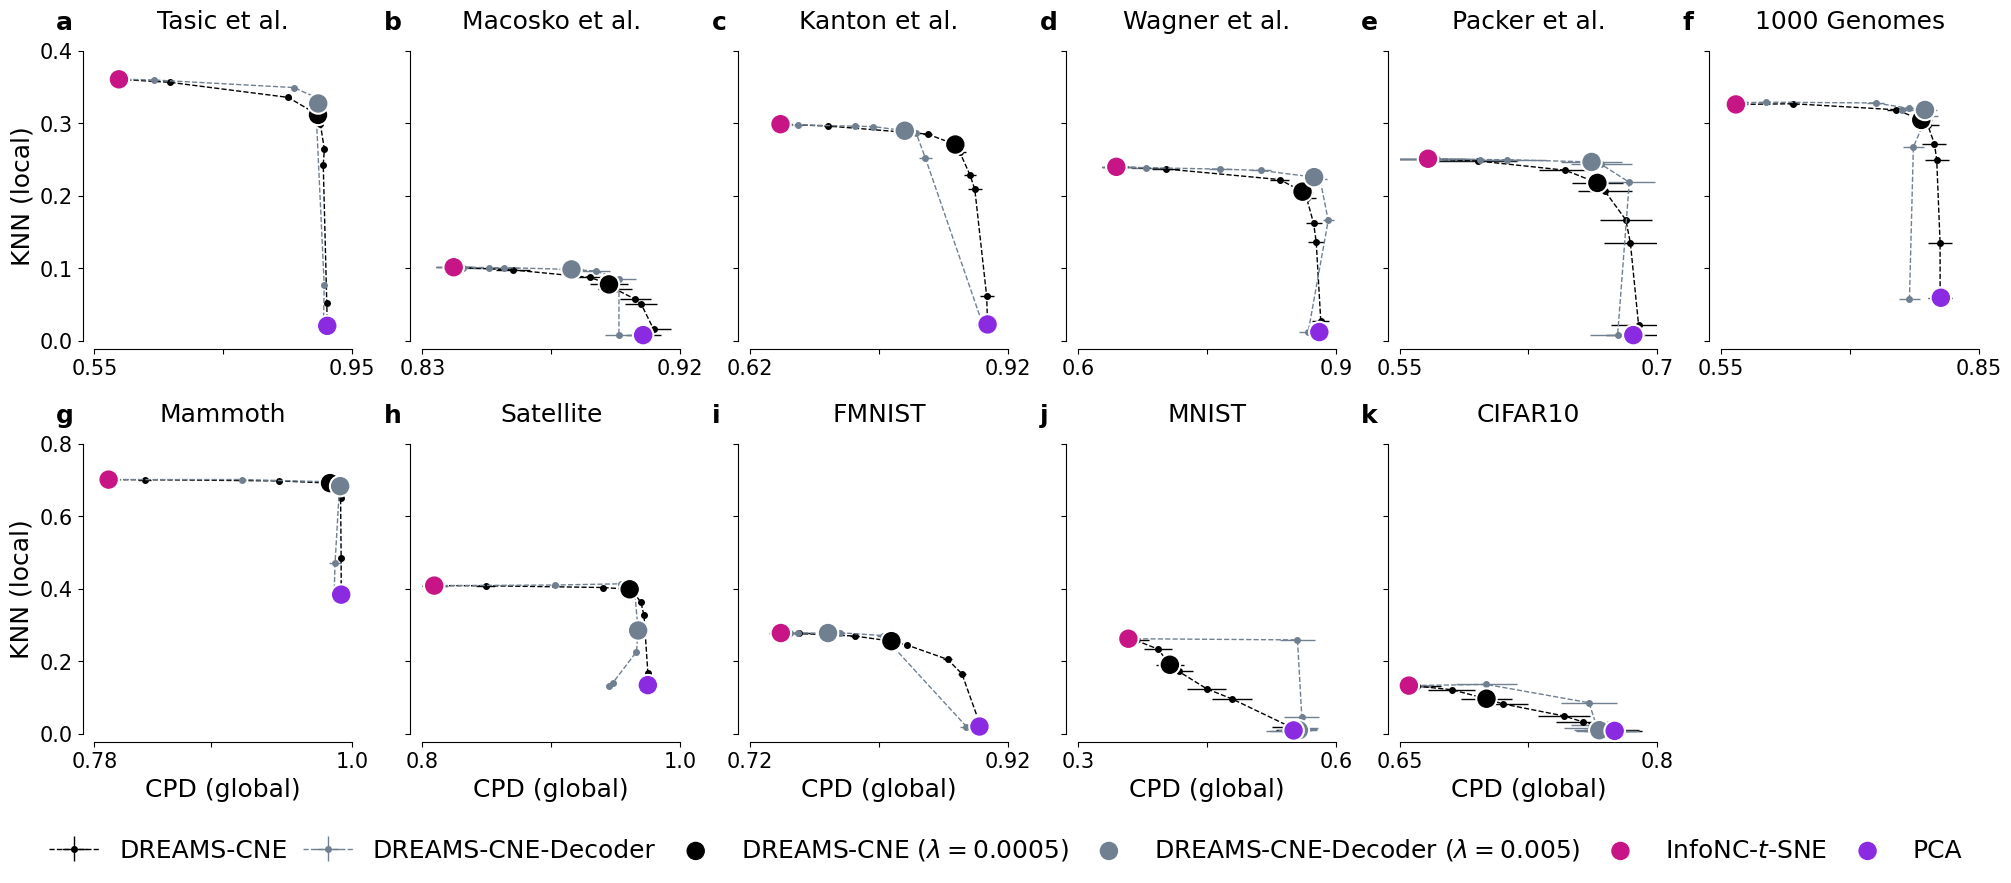

In [ ]:
import matplotlib.patheffects as pe
import string

fig, ax = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True, gridspec_kw={'width_ratios': [2]*6}, sharey='row')

ax = ax.flatten()
for i, dataset in enumerate(dict_all_data.keys()):
    ax[i].set_title(dataset, fontsize=18, pad=16)
    cne_reg_knn, cne_reg_knn_std = cne_reg_knn_list[i]
    cne_reg_cpd, cne_reg_cpd_std = cne_reg_cpd_list[i]
    cne_dec_knn, cne_dec_knn_std = cne_dec_knn_list[i]
    cne_dec_cpd, cne_dec_cpd_std = cne_dec_cpd_list[i]

    obj1 = ax[i].errorbar(cne_reg_cpd, cne_reg_knn, xerr=cne_reg_cpd_std, yerr=cne_reg_knn_std, fmt='o--', color=dict_methods['DREAMS-CNE']['color'], label='DREAMS-CNE', markersize=4, linewidth=1.0)
    obj2 = ax[i].errorbar(cne_dec_cpd, cne_dec_knn, xerr=cne_dec_cpd_std, yerr=cne_dec_knn_std, fmt='o--', color=dict_methods['DREAMS-CNE-Decoder']['color'], label='DREAMS-CNE-Decoder', markersize=4, linewidth=1.0)

    obj3 = ax[i].scatter(cne_reg_cpd.iloc[cne_idx], cne_reg_knn.iloc[cne_idx], c=dict_methods['DREAMS-CNE']['color'], s=150, zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False, label=r'DREAMS-CNE ($\lambda=0.0005$)')
    obj4 = ax[i].scatter(cne_dec_cpd.iloc[cne_idx_dec], cne_dec_knn.iloc[cne_idx_dec], c=dict_methods['DREAMS-CNE-Decoder']['color'], s=150, zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False, label=r'DREAMS-CNE-Decoder ($\lambda=0.005$)')
    # PCA 
    pca_knn = dict_all_data[dataset]['PCA']['KNN']
    pca_cpd = dict_all_data[dataset]['PCA']['CPD']
    obj5 = ax[i].scatter(pca_cpd, pca_knn, c=dict_methods['PCA']['color'], s=150, zorder=15, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False, label='PCA')

    # InfoNC-t-SNE
    infonc_knn = dict_all_data[dataset]['InfoNC-t-SNE']['KNN']
    infonc_cpd = dict_all_data[dataset]['InfoNC-t-SNE']['CPD']
    obj6 = ax[i].scatter(infonc_cpd, infonc_knn, c=dict_methods['InfoNC-t-SNE']['color'], s=150, zorder=10, path_effects=[pe.withStroke(linewidth=4, foreground='white')], clip_on=False, label=r'InfoNC-$t$-SNE')

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_ylim(0)  # Set y-limits for consistency
    # Move left spine a bit away from x=0
    ax[i].spines['left'].set_position(('outward', 8.5))
    # Move bottom spine a bit upward from y=0
    ax[i].spines['bottom'].set_position(('outward', 6))
    #ax[i].set_ylim(0.0, 0.4)

    # Subplot label
    label = f"{string.ascii_lowercase[i]}"
    ax[i].text(-0.15, 1.14, label, transform=ax[i].transAxes,
           fontsize=18, va='top', ha='left', fontweight='bold')
    ax[i].tick_params(axis='both', labelsize=15)

    if dataset == 'Tasic et al.':
        ax[i].set_xticks([0.55, 0.75, 0.95])
        ax[i].set_xticklabels([0.55,'', 0.95])
        ax[i].set_xlim([0.55, 0.95])
        ax[i].tick_params(axis='both', labelsize=15)

    if dataset == 'Macosko et al.':
        ax[i].set_xticks([0.83, 0.875, 0.92])
        ax[i].set_xticklabels([0.83, '', 0.92])
        ax[i].set_xlim([0.83, 0.92])

    if dataset == 'Kanton et al.':
        ax[i].set_xticks([0.62, 0.77, 0.92])
        ax[i].set_xticklabels([0.62, '', 0.92])
        ax[i].set_xlim([0.62, 0.92])

    if dataset == 'Wagner et al.':
        ax[i].set_xticks([0.6, 0.75, 0.9])
        ax[i].set_xticklabels([0.6, '', 0.9])
        ax[i].set_xlim([0.6, 0.9])

    if dataset == 'Packer et al.':
        ax[i].set_xticks([0.55, 0.625, 0.7])
        ax[i].set_xticklabels([0.55, '', 0.7])
        ax[i].set_xlim([0.55, 0.7])

    if dataset == '1000 Genomes':
        ax[i].set_xticks([0.55, 0.7, 0.85])
        ax[i].set_xticklabels([0.55, '', 0.85])
        ax[i].set_xlim([0.55, 0.85])

    # MNIST
    if dataset == 'MNIST':
        ax[i].set_xticks([0.3, 0.45, 0.6])
        ax[i].set_xticklabels([0.3, '', 0.6])
        ax[i].set_xlim([0.3, 0.6])

    if dataset == 'Mammoth':
        ax[i].set_xticks([0.78, 0.88, 1.0])
        ax[i].set_xticklabels([0.78, '', 1.0])
        ax[i].set_xlim([0.78, 1.0])

    if dataset == 'Satellite':
        ax[i].set_xticks([0.8, 0.9, 1.0])
        ax[i].set_xticklabels([0.8, '', 1.0])
        ax[i].set_xlim([0.8, 1.0])

    if dataset == 'FMNIST':
        ax[i].set_xticks([0.72, 0.82, 0.92])
        ax[i].set_xticklabels([0.72, '', 0.92])
        ax[i].set_xlim([0.72, 0.92])
    
    if dataset == 'CIFAR10':
        ax[i].set_xticks([0.65, 0.725, 0.8])
        ax[i].set_xticklabels([0.65, '', 0.8])
        ax[i].set_xlim([0.65, 0.8])

    if i > 5:
        ax[i].set_xlabel('CPD (global)', fontsize=18)

ax[0].set_ylabel('KNN (local)', fontsize=18)
ax[6].set_ylabel('KNN (local)', fontsize=18)

# ax[0].set_xlabel('CPD (global)', fontsize=18)
ax[-1].axis('off')

ax[0].set_ylim([0.0, 0.4])
ax[6].set_ylim([0.0, 0.8])
fig.set_constrained_layout_pads(hspace=0.06)

#ax[0].set_yticklabels([0.3, '', 0.6])

fig.legend(handles=[obj1, obj2, obj3, obj4, obj6, obj5], loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=18, columnspacing=0.6)